# MODEL 1 - ARMA-EGARCH TỪNG NHÂN TỐ

In [7]:
# Cài đặt toàn bộ thư viện cần thiết cho notebook
%pip install -q numpy pandas matplotlib scipy statsmodels arch



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## File

In [8]:
import pandas as pd

btc = pd.read_csv('3y-bitcoin-vnd-returns.csv', parse_dates=["Date"])
sjc = pd.read_csv('3y-gold-returns.csv', parse_dates=['Date'])
vnindex = pd.read_csv('3y-vnindex-returns.csv', parse_dates= ['Date'])


# 1. Vẽ biểu đồ dữ liệu

Matplotlib is building the font cache; this may take a moment.


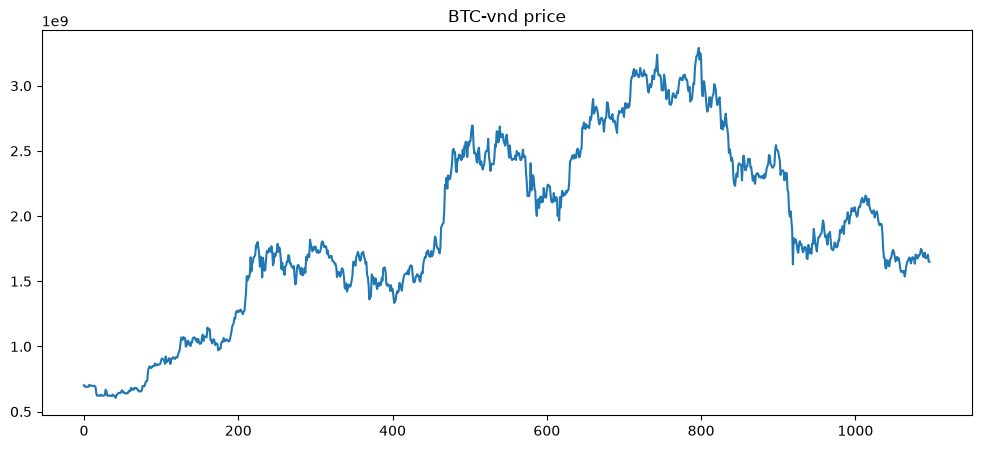

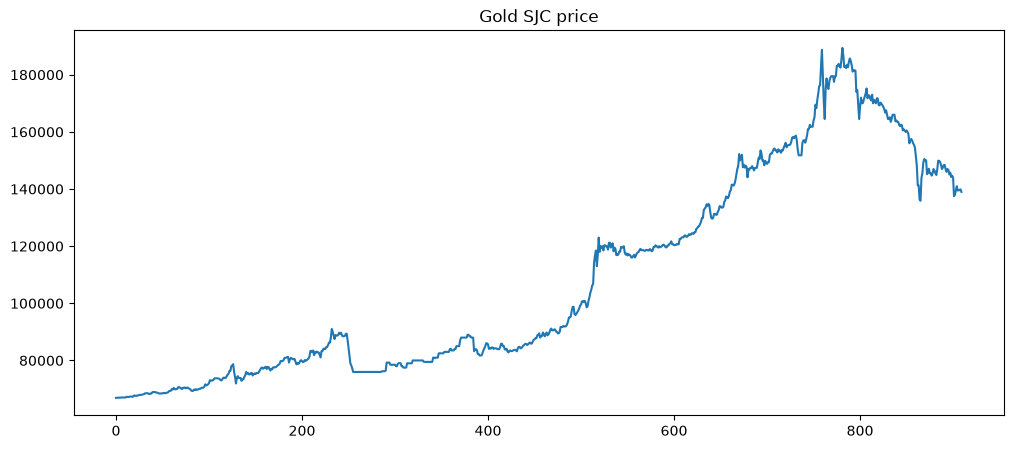

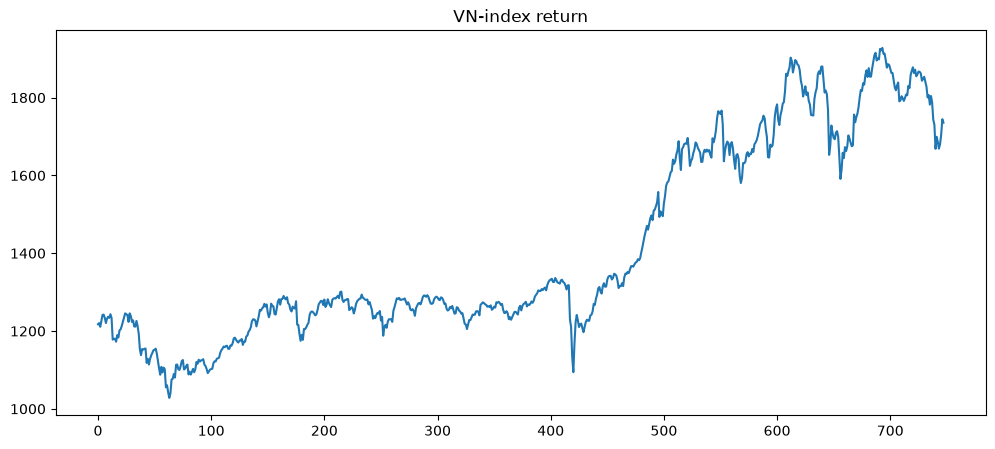

In [9]:
# Vẽ plot dữ liệu các prices

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(btc['btc_vnd_price'])
plt.title("BTC-vnd price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(sjc['gold_price'])
plt.title("Gold SJC price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(vnindex['vnindex_price'])
plt.title("VN-index return")
plt.show()

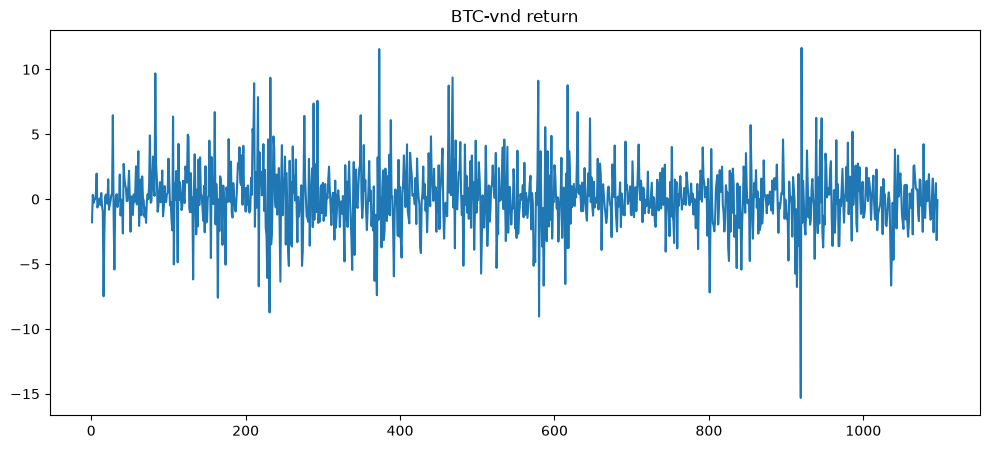

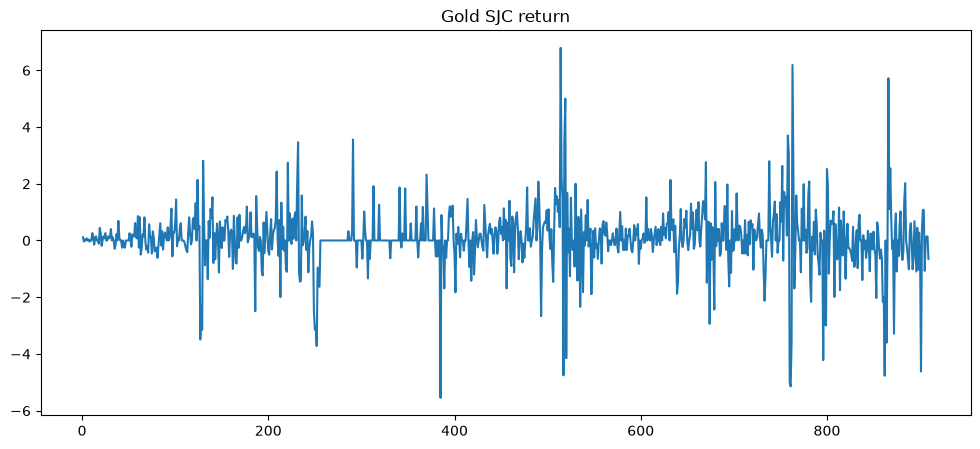

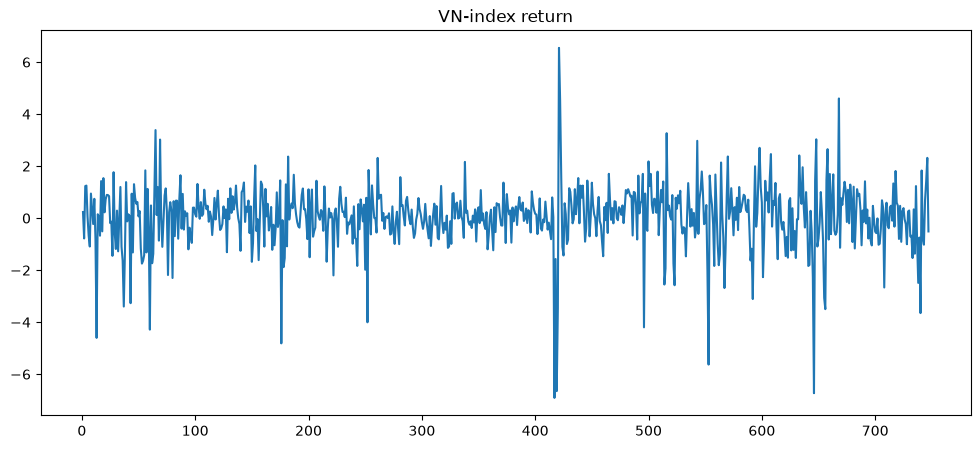

In [10]:
# Vẽ plot dữ liệu các returns

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(btc['btc_return'])
plt.title('BTC-vnd return')
plt.show()

plt.figure(figsize=(12,5))
plt.plot(sjc['gold_return'])
plt.title("Gold SJC return")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(vnindex['vnindex_return'])
plt.title("VN-index return")
plt.show()

# 2. Kiểm định tính dừng

## ADF test

In [11]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

In [12]:
# testing df
return_cols = [
    "btc_return",
    "gold_return",
    "vnindex_return"
]

In [13]:
# Create function 3 cases ADF test
def run_adf_test(series, variable_name):
    series = series.dropna()

    # Three deterministic specifications
    cases = {
        "None - No constant, no trend": "n",
        "Drift - Constant, no trend": "c",
        "Trend - Constant and linear trend": "ct"
    }

    print(f"ADF TEST: {variable_name}")
    print("=" * 25)

    for case_name, regression_type in cases.items():

        result = adfuller(
            series,
            regression=regression_type,
            autolag="AIC"
        )

        adf_stat = result[0]
        p_value = result[1]
        used_lag = result[2]
        n_obs = result[3]
        critical_values = result[4]

        print(f"\nCase: {case_name}")
        print("-" * 25)

        print(f"ADF Statistic       : {adf_stat:.6f}")
        print(f"p-value             : {p_value:.6f}")
        print(f"Selected lag (AIC)  : {used_lag}")
        print(f"Number of obs.      : {n_obs}")

        print("\nCritical Values:")
        print(f"  1%  : {critical_values['1%']:.6f}")
        print(f"  5%  : {critical_values['5%']:.6f}")
        print(f"  10% : {critical_values['10%']:.6f}")

        # Decision at 5% significance level
        if p_value < 0.05:
            print(
                f"\nConclusion: p-value = {p_value:.6f} < 0.05"
                "\n→ Reject H0."
                "\n→ The series is STATIONARY."
            )
        else:
            print(
                f"\nConclusion: p-value = {p_value:.6f} >= 0.05"
                "\n→ Fail to reject H0."
                "\n→ Insufficient evidence to conclude that the series is stationary."
            )

        print("-" * 25)


In [14]:
# ADF testing

# BTC return
run_adf_test(
    btc["btc_return"],
    "BTC Return"
)
# Gold return
run_adf_test(
    sjc["gold_return"],
    "Gold Return"
)
# VN-index return
run_adf_test(
    vnindex["vnindex_return"],
    "VN-Index Return"
)

ADF TEST: BTC Return

Case: None - No constant, no trend
-------------------------
ADF Statistic       : -34.913220
p-value             : 0.000000
Selected lag (AIC)  : 0
Number of obs.      : 1095

Critical Values:
  1%  : -2.567785
  5%  : -1.941248
  10% : -1.616580

Conclusion: p-value = 0.000000 < 0.05
→ Reject H0.
→ The series is STATIONARY.
-------------------------

Case: Drift - Constant, no trend
-------------------------
ADF Statistic       : -34.935805
p-value             : 0.000000
Selected lag (AIC)  : 0
Number of obs.      : 1095

Critical Values:
  1%  : -3.436336
  5%  : -2.864183
  10% : -2.568177

Conclusion: p-value = 0.000000 < 0.05
→ Reject H0.
→ The series is STATIONARY.
-------------------------

Case: Trend - Constant and linear trend
-------------------------
ADF Statistic       : -35.076412
p-value             : 0.000000
Selected lag (AIC)  : 0
Number of obs.      : 1095

Critical Values:
  1%  : -3.967061
  5%  : -3.414507
  10% : -3.129415

Conclusion: p-va

## PP test

In [15]:
# Creating function PP test

def run_pp_test(series, variable_name):
    series = series.dropna()

    # Three deterministic specifications
    cases = {
        "None - No constant, no trend": "n",
        "Drift - Constant, no trend": "c",
        "Trend - Constant and linear trend": "ct"
    }

    print(f"PP TEST: {variable_name}")
    print("=" * 25)

    for case_name, trend_type in cases.items():

        test = PhillipsPerron(
            series,
            trend=trend_type,
            test_type="tau"
        )

        pp_stat = test.stat
        p_value = test.pvalue
        lags = test.lags
        critical_values = test.critical_values

        print(f"\nCase: {case_name}")
        print("-" * 25)

        print(f"PP Statistic        : {pp_stat:.6f}")
        print(f"p-value             : {p_value:.6f}")
        print(f"Bandwidth (lags)    : {lags}")

        print("\nCritical Values:")
        print(f"  1%  : {critical_values['1%']:.6f}")
        print(f"  5%  : {critical_values['5%']:.6f}")
        print(f"  10% : {critical_values['10%']:.6f}")

        # Decision at 5% significance level
        if p_value < 0.05:
            print(
                f"\nConclusion: p-value = {p_value:.6f} < 0.05"
                "\n→ Reject H0."
                "\n→ The series is STATIONARY."
            )
        else:
            print(
                f"\nConclusion: p-value = {p_value:.6f} >= 0.05"
                "\n→ Fail to reject H0."
                "\n→ Insufficient evidence to conclude that the series is stationary."
            )

        print("-" * 25)

In [16]:
# Run PP test BTC return
run_pp_test(
    btc["btc_return"],
    "BTC Return"
)

# Run PP test Gold return
run_pp_test(
    sjc["gold_return"],
    "Gold SJC Return"
)

# Run PP test VN-Index return
run_pp_test(
    vnindex["vnindex_return"],
    "VN-Index Return"
)

PP TEST: BTC Return

Case: None - No constant, no trend
-------------------------
PP Statistic        : -34.868486
p-value             : 0.000000
Bandwidth (lags)    : 22

Critical Values:
  1%  : -2.567785
  5%  : -1.941248
  10% : -1.616580

Conclusion: p-value = 0.000000 < 0.05
→ Reject H0.
→ The series is STATIONARY.
-------------------------

Case: Drift - Constant, no trend
-------------------------
PP Statistic        : -34.884745
p-value             : 0.000000
Bandwidth (lags)    : 22

Critical Values:
  1%  : -3.436336
  5%  : -2.864183
  10% : -2.568177

Conclusion: p-value = 0.000000 < 0.05
→ Reject H0.
→ The series is STATIONARY.
-------------------------

Case: Trend - Constant and linear trend
-------------------------
PP Statistic        : -35.046040
p-value             : 0.000000
Bandwidth (lags)    : 22

Critical Values:
  1%  : -3.967061
  5%  : -3.414507
  10% : -3.129415

Conclusion: p-value = 0.000000 < 0.05
→ Reject H0.
→ The series is STATIONARY.
----------------

## KPSS test

In [17]:
# Kiểm định KPSS
from statsmodels.tsa.stattools import kpss

# Creating function KPSS, only 'c' and 'ct'
def run_kpss_test(series, variable_name):

    # Remove missing values if any
    series = series.dropna()

    # KPSS supports two deterministic specifications
    cases = {
        "Level - Constant, no trend": "c",
        "Trend - Constant and linear trend": "ct"
    }

    print(f"KPSS TEST: {variable_name}")
    print("=" * 25)

    for case_name, regression_type in cases.items():

        statistic, p_value, lags, critical_values = kpss(
            series,
            regression=regression_type,
            nlags="auto"
        )

        print(f"\nCase: {case_name}")
        print("-" * 25)

        print(f"KPSS Statistic      : {statistic:.6f}")
        print(f"p-value             : {p_value:.6f}")
        print(f"Bandwidth (lags)    : {lags}")

        print("\nCritical Values:")
        print(f"  1%  : {critical_values['1%']:.6f}")
        print(f"  5%  : {critical_values['5%']:.6f}")
        print(f"  10% : {critical_values['10%']:.6f}")

        # Decision at 5% significance level
        if p_value < 0.05:
            print(
                f"\nConclusion: p-value = {p_value:.6f} < 0.05"
                "\n→ Reject H0."
                "\n→ The series is NON-STATIONARY."
            )
        else:
            print(
                f"\nConclusion: p-value = {p_value:.6f} >= 0.05"
                "\n→ Fail to reject H0."
                "\n→ The series is STATIONARY."
            )

        print("-" * 25)

In [18]:
# Run KPSS BTC return
run_kpss_test(
    btc["btc_return"],
    "BTC Return"
)

# Run KPSS Gold return
run_kpss_test(sjc['gold_return'], 'Gold SJC Return')

# Run KPSS VN-Index return
run_kpss_test(vnindex['vnindex_return'], 'VN-Index Return')

KPSS TEST: BTC Return

Case: Level - Constant, no trend
-------------------------
KPSS Statistic      : 0.547507
p-value             : 0.030967
Bandwidth (lags)    : 2

Critical Values:
  1%  : 0.739000
  5%  : 0.463000
  10% : 0.347000

Conclusion: p-value = 0.030967 < 0.05
→ Reject H0.
→ The series is NON-STATIONARY.
-------------------------

Case: Trend - Constant and linear trend
-------------------------
KPSS Statistic      : 0.039376
p-value             : 0.100000
Bandwidth (lags)    : 3

Critical Values:
  1%  : 0.216000
  5%  : 0.146000
  10% : 0.119000

Conclusion: p-value = 0.100000 >= 0.05
→ Fail to reject H0.
→ The series is STATIONARY.
-------------------------
KPSS TEST: Gold SJC Return

Case: Level - Constant, no trend
-------------------------
KPSS Statistic      : 0.204028
p-value             : 0.100000
Bandwidth (lags)    : 3

Critical Values:
  1%  : 0.739000
  5%  : 0.463000
  10% : 0.347000

Conclusion: p-value = 0.100000 >= 0.05
→ Fail to reject H0.
→ The series 

/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_50573/3226831399.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_50573/3226831399.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_50573/3226831399.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_50573/3226831399.py:21: Interpolati

## Zivot - Andrews test

In [19]:
# Kết quả KPSS conflicting
# Dùng Zivot - Andrews test

from statsmodels.tsa.stattools import zivot_andrews

# Creating function
def run_za_test(series, dates, variable_name):

    # Keep series and dates aligned
    data = series.dropna()
    aligned_dates = dates.loc[data.index]

    # Three structural-break specifications
    cases = {
        "Break in intercept": "c",
        "Break in trend": "t",
        "Break in intercept and trend": "ct"
    }

    print(f"ZIVOT-ANDREWS TEST: {variable_name}")
    print("=" * 25)

    for case_name, regression_type in cases.items():

        result = zivot_andrews(
            data,
            regression=regression_type,
            autolag="AIC"
        )

        za_stat = result[0]
        p_value = result[1]
        critical_values = result[2]
        used_lag = result[3]
        break_index = result[4]

        # Convert break index into actual date
        break_date = aligned_dates.iloc[break_index]

        print(f"\nCase: {case_name}")
        print("-" * 25)

        print(f"ZA Statistic        : {za_stat:.6f}")
        print(f"p-value             : {p_value:.6f}")
        print(f"Selected lag (AIC)  : {used_lag}")
        print(f"Break index         : {break_index}")
        print(f"Estimated break date: {break_date.date()}")

        print("\nCritical Values:")
        print(f"  1%  : {critical_values['1%']:.6f}")
        print(f"  5%  : {critical_values['5%']:.6f}")
        print(f"  10% : {critical_values['10%']:.6f}")

        # Decision at 5%
        if p_value < 0.05:
            print(
                f"\nConclusion: p-value = {p_value:.6f} < 0.05"
                "\n→ Reject H0 of a unit root."
                "\n→ Evidence supports stationarity allowing for "
                "one structural break."
            )
        else:
            print(
                f"\nConclusion: p-value = {p_value:.6f} >= 0.05"
                "\n→ Fail to reject H0 of a unit root."
                "\n→ Insufficient evidence of stationarity "
                "allowing for one structural break."
            )

        print("-" * 25)

In [20]:
# Run ZA test!!!!
run_za_test(
    btc["btc_return"],
    btc["Date"],
    "BTC Return"
)

run_za_test(
    sjc["gold_return"],
    sjc["Date"],
    "Gold SJC Return"
)
run_za_test(
    vnindex["vnindex_return"],
    vnindex["Date"],
    "VN-Index Return"
)

ZIVOT-ANDREWS TEST: BTC Return

Case: Break in intercept
-------------------------
ZA Statistic        : -35.156430
p-value             : 0.000010
Selected lag (AIC)  : 0
Break index         : 402
Estimated break date: 2024-09-07

Critical Values:
  1%  : -5.276440
  5%  : -4.810670
  10% : -4.566180

Conclusion: p-value = 0.000010 < 0.05
→ Reject H0 of a unit root.
→ Evidence supports stationarity allowing for one structural break.
-------------------------

Case: Break in trend
-------------------------
ZA Statistic        : -35.087344
p-value             : 0.000700
Selected lag (AIC)  : 0
Break index         : 164
Estimated break date: 2024-01-13

Critical Values:
  1%  : -5.034210
  5%  : -4.405800
  10% : -4.136780

Conclusion: p-value = 0.000700 < 0.05
→ Reject H0 of a unit root.
→ Evidence supports stationarity allowing for one structural break.
-------------------------

Case: Break in intercept and trend
-------------------------
ZA Statistic        : -35.258861
p-value       

## Kết luận về tính dừng

Trước khi tiến hành ước lượng mô hình ARMA-EGARCH, tính dừng của ba chuỗi lợi suất gồm **Bitcoin (BTC), vàng SJC và VN-Index** được kiểm định bằng bốn phương pháp: Augmented Dickey-Fuller (ADF), Phillips-Perron (PP), Kwiatkowski-Phillips-Schmidt-Shin (KPSS) và Zivot-Andrews (ZA).

Việc sử dụng đồng thời nhiều kiểm định giúp đánh giá tính dừng một cách toàn diện hơn. Trong đó, ADF và PP kiểm định giả thuyết gốc về sự tồn tại của nghiệm đơn vị; KPSS sử dụng giả thuyết gốc ngược lại, tức chuỗi có tính dừng; trong khi ZA cho phép xem xét nghiệm đơn vị trong trường hợp có một điểm gãy cấu trúc nội sinh.

---

### 1. Kiểm định Augmented Dickey-Fuller (ADF)

#### Giả thuyết kiểm định

- **H0:** Chuỗi có nghiệm đơn vị, tức **không dừng**.
- **H1:** Chuỗi **dừng**.

Tại mức ý nghĩa 5%:

- p-value < 0,05 → Bác bỏ H0 → Có bằng chứng chuỗi dừng.
- p-value ≥ 0,05 → Không bác bỏ H0 → Chưa đủ bằng chứng kết luận chuỗi dừng.

#### Kết quả kiểm định ADF

| Tài sản | Case | Thống kê ADF | p-value | Độ trễ (AIC) | Số quan sát | Quyết định (5%) | Kết luận |
|---|---|---:|---:|---:|---:|---|---|
| **BTC** | Không hằng số, không xu hướng | -34.913220 | < 0,001 | 0 | 1095 | Bác bỏ H0 | Dừng |
| | Hằng số | -34.935805 | < 0,001 | 0 | 1095 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -35.076412 | < 0,001 | 0 | 1095 | Bác bỏ H0 | Dừng |
| **Vàng SJC** | Không hằng số, không xu hướng | -27.111084 | < 0,001 | 0 | 908 | Bác bỏ H0 | Dừng |
| | Hằng số | -27.238442 | < 0,001 | 0 | 908 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -27.237967 | < 0,001 | 0 | 908 | Bác bỏ H0 | Dừng |
| **VN-Index** | Không hằng số, không xu hướng | -9.751879 | < 0,001 | 7 | 739 | Bác bỏ H0 | Dừng |
| | Hằng số | -9.807189 | < 0,001 | 7 | 739 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -9.814080 | < 0,001 | 7 | 739 | Bác bỏ H0 | Dừng |

#### Nhận xét

Kết quả ADF cho thấy đủ cơ sở bác bỏ H0: sự tồn tại của nghiệm đơn vị, đối với cả ba chuỗi lợi suất trong tất cả các cases. Các p-value đều nhỏ hơn 0,001.

Do đó, kiểm định ADF cung cấp bằng chứng mạnh cho thấy **lợi suất BTC, vàng SJC và VN-Index đều có tính dừng**.

---

### 2. Kiểm định Phillips-Perron (PP)

#### Giả thuyết kiểm định

Tương tự ADF:

- **H0:** Chuỗi có nghiệm đơn vị, tức **không dừng**.
- **H1:** Chuỗi **dừng**.

Tại mức ý nghĩa 5%:

- p-value < 0,05 → Bác bỏ H0 → Có bằng chứng chuỗi dừng.
- p-value ≥ 0,05 → Không bác bỏ H0.

#### Kết quả kiểm định PP

| Tài sản | Case | Thống kê PP | p-value | Bandwidth | Quyết định (5%) | Kết luận |
|---|---|---:|---:|---:|---|---|
| **BTC** | Không hằng số, không xu hướng | -34.868486 | < 0,001 | 22 | Bác bỏ H0 | Dừng |
| | Hằng số | -34.884745 | < 0,001 | 22 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -35.046040 | < 0,001 | 22 | Bác bỏ H0 | Dừng |
| **Vàng SJC** | Không hằng số, không xu hướng | -27.361041 | < 0,001 | 21 | Bác bỏ H0 | Dừng |
| | Hằng số | -27.317833 | < 0,001 | 21 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -27.305137 | < 0,001 | 21 | Bác bỏ H0 | Dừng |
| **VN-Index** | Không hằng số, không xu hướng | -24.660652 | < 0,001 | 20 | Bác bỏ H0 | Dừng |
| | Hằng số | -24.679678 | < 0,001 | 20 | Bác bỏ H0 | Dừng |
| | Hằng số + xu hướng | -24.668944 | < 0,001 | 20 | Bác bỏ H0 | Dừng |

#### Nhận xét

Kiểm định PP cho kết quả nhất quán với ADF. H0 về nghiệm đơn vị bị bác bỏ ở mức ý nghĩa 5% đối với cả ba chuỗi và dưới cả ba trường hợp.

Như vậy, kiểm định PP tiếp tục cung cấp bằng chứng rằng **BTC, vàng SJC và VN-Index đều có tính dừng**.

---

### 3. Kiểm định Kwiatkowski-Phillips-Schmidt-Shin (KPSS)

#### Giả thuyết kiểm định

Khác với ADF và PP, KPSS có giả thuyết gốc ngược lại:

- **H0:** Chuỗi **dừng**.
- **H1:** Chuỗi **không dừng**.

Tại mức ý nghĩa 5%:

- p-value < 0,05 → Bác bỏ H0 → Có bằng chứng chống lại tính dừng theo đặc tả tương ứng.
- p-value ≥ 0,05 → Không bác bỏ H0 → Kết quả phù hợp với tính dừng.

#### Kết quả kiểm định KPSS

| Tài sản | Case | Thống kê KPSS | p-value | Bandwidth | Quyết định (5%) | Kết luận theo case |
|---|---|---:|---:|---:|---|---|
| **BTC** | Hằng số | 0.547507 | 0.030967 | 2 | Bác bỏ H0 | Không dừng quanh mức |
| | Hằng số + xu hướng | 0.039376 | > 0,10 | 3 | Không bác bỏ H0 | Dừng quanh xu hướng |
| **Vàng SJC** | Hằng số | 0.204028 | > 0,10 | 3 | Không bác bỏ H0 | Dừng quanh mức |
| | Hằng số + xu hướng | 0.190747 | 0.019470 | 3 | Bác bỏ H0 | Không dừng quanh xu hướng |
| **VN-Index** | Hằng số | 0.090996 | > 0,10 | 8 | Không bác bỏ H0 | Dừng quanh mức |
| | Hằng số + xu hướng | 0.062968 | > 0,10 | 8 | Không bác bỏ H0 | Dừng quanh xu hướng |

**Lưu ý:** Các trường hợp phần mềm trả về `p-value = 0.100000` kèm `InterpolationWarning` được trình bày là **p-value > 0,10**, vì p-value thực tế lớn hơn giới hạn trên của bảng tra được sử dụng trong kiểm định.

#### Nhận xét

Kết quả KPSS có sự khác biệt nhất định so với ADF và PP.

Đối với **BTC**, H0 về tính dừng quanh một mức cố định bị bác bỏ với p-value = 0,030967. Tuy nhiên, khi cho phép thành phần trend, H0 không bị bác bỏ. Như vậy, kết quả KPSS của BTC nhạy cảm với trường hợp thành phần xác định.

Đối với **vàng SJC**, H0 về tính dừng quanh một mức cố định không bị bác bỏ (c). Ngược lại, khi đưa trend vào kiểm định, H0 bị bác bỏ. Do chuỗi đang được phân tích là lợi suất tài chính, trường hợp với hằng số có ý nghĩa trực tiếp hơn trong trường hợp không có cơ sở lý thuyết để giả định lợi suất có xu hướng tuyến tính xác định theo thời gian.

Đối với **VN-Index**, H0 không bị bác bỏ trong cả hai trường hợp. Do đó, KPSS cung cấp bằng chứng nhất quán về tính dừng của lợi suất VN-Index.

Nhìn chung, KPSS cho kết quả hỗn hợp đối với BTC và vàng SJC nhưng cung cấp bằng chứng rõ ràng về tính dừng đối với VN-Index.

---

### 4. Kiểm định Zivot-Andrews (ZA)

ADF, PP và KPSS truyền thống có thể nhạy cảm với những điểm gãy cấu trúc trong chuỗi thời gian. Vì vậy, kiểm định Zivot-Andrews được sử dụng bổ sung để kiểm tra nghiệm đơn vị khi cho phép **một điểm gãy cấu trúc được xác định nội sinh từ dữ liệu**.

#### Giả thuyết kiểm định

- **H0:** Chuỗi có nghiệm đơn vị.
- **H1:** Chuỗi dừng khi cho phép một điểm gãy cấu trúc.

Tại mức ý nghĩa 5%:

- p-value < 0,05 → Bác bỏ H0 → Có bằng chứng chống lại nghiệm đơn vị khi cho phép một điểm gãy cấu trúc.
- p-value ≥ 0,05 → Không bác bỏ H0.

#### Kết quả kiểm định Zivot-Andrews

| Tài sản | Dạng điểm gãy | Thống kê ZA | p-value | Độ trễ (AIC) | Ngày gãy ước lượng | Quyết định (5%) | Kết luận |
|---|---|---:|---:|---:|---|---|---|
| **BTC** | Hệ số chặn | -35.156430 | 0.000010 | 0 | 07/09/2024 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Xu hướng | -35.087344 | 0.000700 | 0 | 13/01/2024 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Hệ số chặn + xu hướng | -35.258861 | 0.000101 | 0 | 13/03/2024 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| **Vàng SJC** | Hệ số chặn | -27.699754 | 0.000010 | 0 | 29/01/2026 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Xu hướng | -27.527835 | 0.000807 | 0 | 20/01/2026 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Hệ số chặn + xu hướng | -27.682899 | 0.000337 | 0 | 29/01/2026 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| **VN-Index** | Hệ số chặn | -10.128432 | 0.000010 | 7 | 09/04/2025 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Xu hướng | -9.996096 | 0.001818 | 7 | 11/08/2025 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |
| | Hệ số chặn + xu hướng | -10.325987 | 0.000879 | 7 | 09/04/2025 | Bác bỏ H0 | Dừng khi cho phép điểm gãy |

#### Nhận xét

Kết quả ZA cho thấy H0 về nghiệm đơn vị bị bác bỏ ở mức ý nghĩa 5% đối với **cả ba chuỗi lợi suất và trong cả ba dạng điểm gãy**.

Đối với **BTC**, các điểm gãy ước lượng thay đổi tùy theo từng trường hợp, lần lượt nằm vào tháng 1, tháng 3 và tháng 9 năm 2024. Tuy nhiên, tất cả các thống kê ZA đều có giá trị âm rất lớn so với giá trị tới hạn tương ứng, cho thấy bằng chứng mạnh chống lại giả thuyết tồn tại nghiệm đơn vị.

Đối với **vàng SJC**, các điểm gãy ước lượng tập trung trong tháng 1/2026. Hai trường hợp điểm gãy ở hệ số chặn, và hệ số chặn kết hợp xu hướng (drift + trend) cùng xác định ngày 29/01/2026, trong khi case điểm gãy xu hướng xác định ngày 20/01/2026.

Đối với **VN-Index**, hai case điểm gãy ở hệ số chặn và hệ số chặn kết hợp xu hướng cùng xác định ngày 09/04/2025. Case điểm gãy xu hướng xác định ngày 11/08/2025.

Các ngày gãy trên cần được hiểu là **điểm gãy được ZA lựa chọn nội sinh dưới từng đặc tả cụ thể**, không nên được diễn giải ngay là bằng chứng khẳng định một sự kiện cấu trúc duy nhất xảy ra chính xác vào ngày đó.

---

### 5. Tổng hợp kết quả kiểm định tính dừng

| Chuỗi lợi suất | ADF | PP | KPSS | ZA | Đánh giá tổng thể |
|---|---|---|---|---|---|
| **BTC** | Dừng | Dừng | Kết quả hỗn hợp | Bác bỏ nghiệm đơn vị khi cho phép điểm gãy | **Dừng, I(0)** |
| **Vàng SJC** | Dừng | Dừng | Kết quả hỗn hợp | Bác bỏ nghiệm đơn vị khi cho phép điểm gãy | **Dừng, I(0)** |
| **VN-Index** | Dừng | Dừng | Dừng | Bác bỏ nghiệm đơn vị khi cho phép điểm gãy | **Dừng, I(0)** |

### Kết luận cuối cùng

Tổng hợp kết quả từ bốn kiểm định cho phép kết luận rằng:

**Cả ba chuỗi lợi suất BTC, vàng SJC và VN-Index đều có thể được xem là chuỗi dừng ở mức, I(0).**

Do đó, **không cần thực hiện sai phân bổ sung đối với các chuỗi lợi suất** trước khi tiến hành mô hình hóa.

Ba chuỗi lợi suất hiện tại có thể được tiếp tục sử dụng để xác định phương trình trung bình có điều kiện bằng **ARMA(p,q)** và sau đó ước lượng phương sai có điều kiện bằng **EGARCH** trong giai đoạn tiếp theo của nghiên cứu.

# Plot ACF PACF

In [21]:
btc_return = btc['btc_return'].dropna()

print(btc.shape)
print(btc['btc_return'].isna().sum())
print(btc['btc_return'].notna().sum())

(1097, 15)
1
1096


In [22]:
import numpy as np
import statsmodels
from statsmodels.tsa.stattools import acf, pacf

print("statsmodels version:", statsmodels.__version__)

# Tạo biến từ btc_return
btc_ret = btc['btc_return'].dropna().astype(float).to_numpy()

print("Number of observations:", len(btc_ret))
print("First 5 values:", btc_ret[:5])

# Tính ACF/PACF
acf_values = acf(btc_ret, nlags=12)
pacf_values = pacf(btc_ret, nlags=12, method="ywm")

print("\nACF:")
print(acf_values)

print("\nPACF:")
print(pacf_values)

statsmodels version: 0.14.6
Number of observations: 1096
First 5 values: [-1.78075075e+00  3.23612277e-01 -2.95905507e-01 -1.10003189e-01
 -9.34799453e-04]

ACF:
[ 1.         -0.05485604  0.015721   -0.02289943  0.01407618  0.02077811
 -0.02330181  0.06064976 -0.0463578   0.00679895  0.01242481  0.01979545
 -0.03036088]

PACF:
[ 1.00000000e+00 -5.48560367e-02  1.27501795e-02 -2.14165271e-02
  1.15270617e-02  2.28406186e-02 -2.18731808e-02  5.84904197e-02
 -3.90150745e-02 -6.75553543e-04  1.67598979e-02  1.86332819e-02
 -3.05633576e-02]


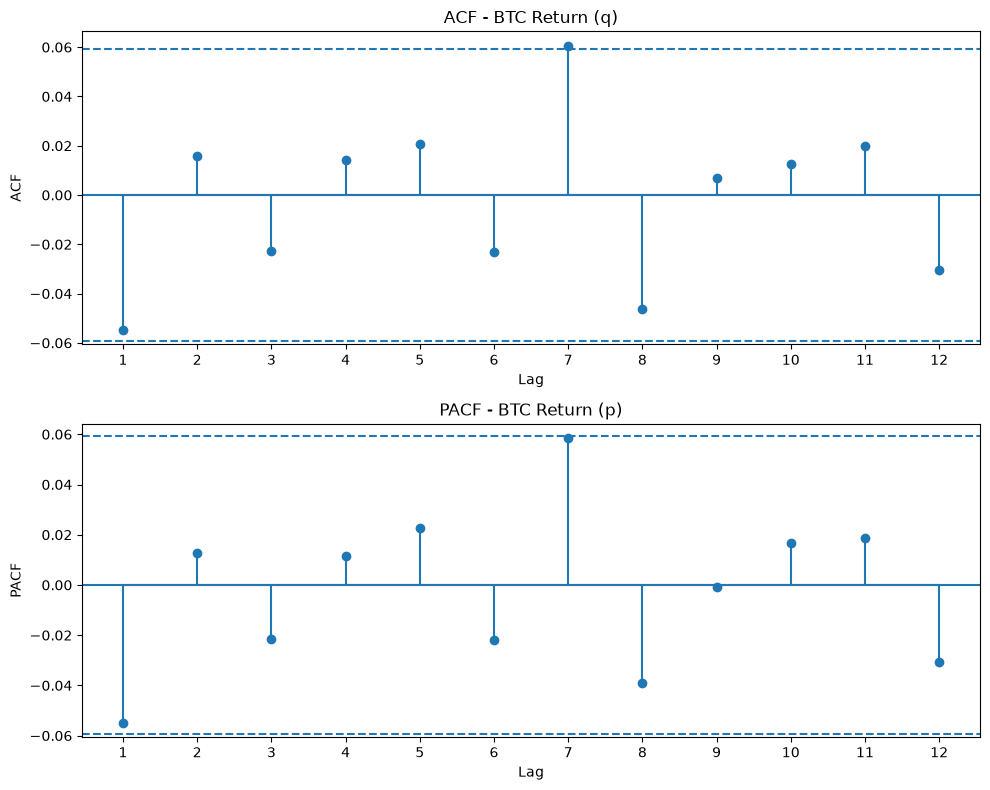

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

btc_ret = btc['btc_return'].dropna().astype(float).to_numpy()

# Tính ACF/PACF
acf_values = acf(btc_ret, nlags=12)
pacf_values = pacf(btc_ret, nlags=12, method='ywm')

lags = np.arange(1, 13)

# Confidence interval xấp xỉ 95%
ci = 1.96 / np.sqrt(len(btc_ret))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ACF
axes[0].stem(lags, acf_values[1:])
axes[0].axhline(0)
axes[0].axhline(ci, linestyle='--')
axes[0].axhline(-ci, linestyle='--')
axes[0].set_title("ACF - BTC Return (q)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")
axes[0].set_xticks(lags)

# PACF
axes[1].stem(lags, pacf_values[1:])
axes[1].axhline(0)
axes[1].axhline(ci, linestyle='--')
axes[1].axhline(-ci, linestyle='--')
axes[1].set_title("PACF - BTC Return (p)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("PACF")
axes[1].set_xticks(lags)

plt.tight_layout()
plt.show()

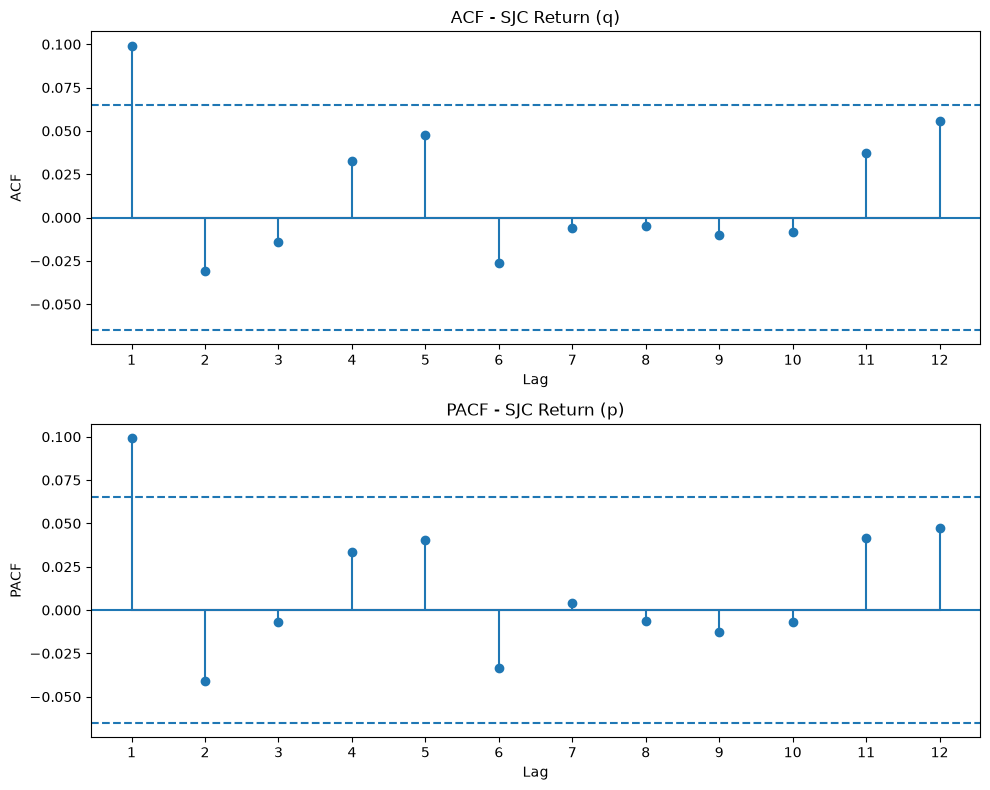

In [24]:
# Vẽ ACF PACF Gold return
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

sjc_ret = sjc['gold_return'].dropna().astype(float).to_numpy()

# Tính ACF/PACF
acf_values = acf(sjc_ret, nlags=12)
pacf_values = pacf(sjc_ret, nlags=12, method='ywm')

lags = np.arange(1, 13)

# Confidence interval xấp xỉ 95%
ci = 1.96 / np.sqrt(len(sjc_ret))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ACF
axes[0].stem(lags, acf_values[1:])
axes[0].axhline(0)
axes[0].axhline(ci, linestyle='--')
axes[0].axhline(-ci, linestyle='--')
axes[0].set_title("ACF - SJC Return (q)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")
axes[0].set_xticks(lags)

# PACF
axes[1].stem(lags, pacf_values[1:])
axes[1].axhline(0)
axes[1].axhline(ci, linestyle='--')
axes[1].axhline(-ci, linestyle='--')
axes[1].set_title("PACF - SJC Return (p)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("PACF")
axes[1].set_xticks(lags)

plt.tight_layout()
plt.show()

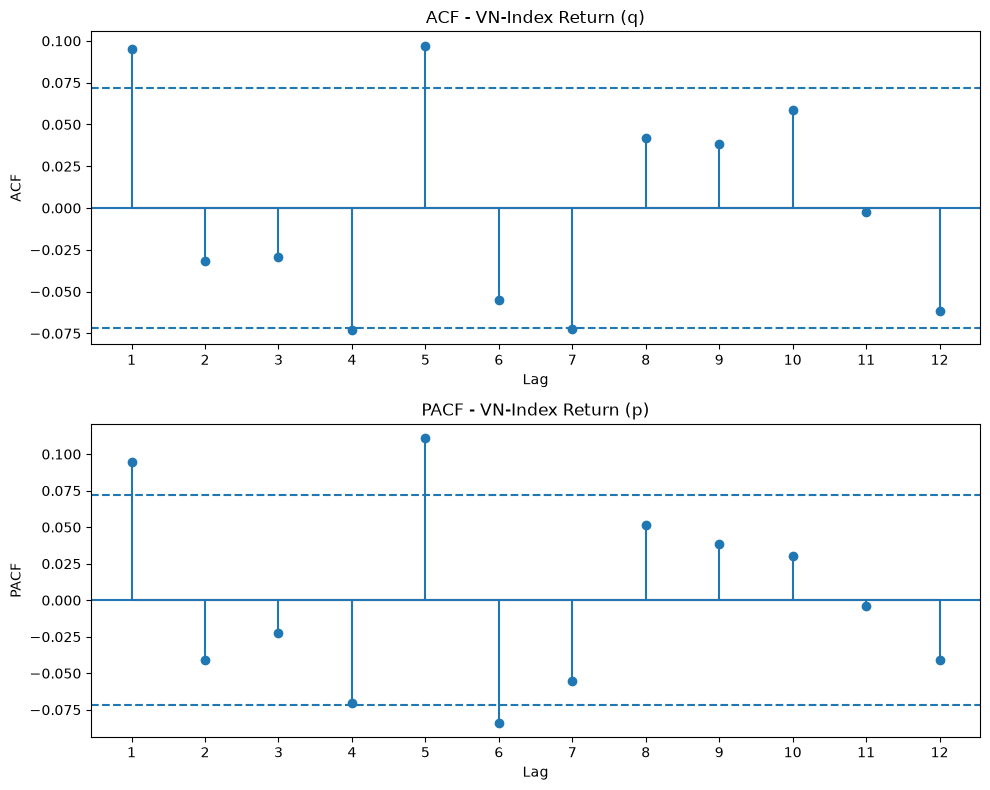

In [25]:
# Vẽ ACF PACF VN-index return
# Vẽ ACF PACF Gold return
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

vnindex_ret = vnindex['vnindex_return'].dropna().astype(float).to_numpy()

# Tính ACF/PACF
acf_values = acf(vnindex_ret, nlags=12)
pacf_values = pacf(vnindex_ret, nlags=12, method='ywm')

lags = np.arange(1, 13)

# Confidence interval xấp xỉ 95%
ci = 1.96 / np.sqrt(len(vnindex_ret))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ACF
axes[0].stem(lags, acf_values[1:])
axes[0].axhline(0)
axes[0].axhline(ci, linestyle='--')
axes[0].axhline(-ci, linestyle='--')
axes[0].set_title("ACF - VN-Index Return (q)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")
axes[0].set_xticks(lags)

# PACF
axes[1].stem(lags, pacf_values[1:])
axes[1].axhline(0)
axes[1].axhline(ci, linestyle='--')
axes[1].axhline(-ci, linestyle='--')
axes[1].set_title("PACF - VN-Index Return (p)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("PACF")
axes[1].set_xticks(lags)

plt.tight_layout()
plt.show()

# Xếp hạng AIC, BIC các ARMA candidate theo gợi ý p,q

## ARMA BCT

In [26]:
# ============================================================
# ARMA CANDIDATE SELECTION - BTC RETURN
# Search space: p, q = 0, 1, 2
# ============================================================

import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# 1. Prepare BTC return
btc_ret = btc['btc_return'].dropna().astype(float)

# 2. Search range
btc_max_p = 2
btc_max_q = 2

btc_arma_results_list = []

# 3. Fit all ARMA(p,q) candidates
for p in range(btc_max_p + 1):
    for q in range(btc_max_q + 1):
        try:
            btc_model = ARIMA(
                btc_ret,
                order=(p, 0, q),
                trend='c'
            )

            btc_fitted = btc_model.fit()

            btc_arma_results_list.append({
                "Model": f"ARMA({p},{q})",
                "p": p,
                "q": q,
                "AIC": btc_fitted.aic,
                "BIC": btc_fitted.bic,
                "LogLik": btc_fitted.llf,
                "Converged": btc_fitted.mle_retvals.get(
                    "converged", True
                )
            })

        except Exception as e:
            print(f"ARMA({p},{q}) failed: {e}")


# 4. Create BTC results DataFrame
btc_arma_results = pd.DataFrame(btc_arma_results_list)


# 5. Rank by AIC
btc_top_aic = (
    btc_arma_results
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 70)
print("BTC RETURN - ARMA RANKING BY AIC")
print("=" * 70)

print(
    btc_top_aic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 6. Rank by BIC
btc_top_bic = (
    btc_arma_results
    .sort_values("BIC")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("BTC RETURN - ARMA RANKING BY BIC")
print("=" * 70)

print(
    btc_top_bic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 7. Print Top 5
print("\n" + "=" * 70)
print("BTC - TOP 5 BY AIC")
print("=" * 70)

print(
    btc_top_aic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)


print("\n" + "=" * 70)
print("BTC - TOP 5 BY BIC")
print("=" * 70)

print(
    btc_top_bic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)

BTC RETURN - ARMA RANKING BY AIC
       Model        AIC        BIC     LogLik  Converged
0  ARMA(1,0)  5084.1228  5099.1211 -2539.0614       True
1  ARMA(0,1)  5084.2070  5099.2053 -2539.1035       True
2  ARMA(0,0)  5085.4246  5095.4234 -2540.7123       True
3  ARMA(1,1)  5085.7418  5105.7395 -2538.8709       True
4  ARMA(2,0)  5085.9446  5105.9423 -2538.9723       True
5  ARMA(0,2)  5086.0157  5106.0134 -2539.0079       True
6  ARMA(1,2)  5087.7366  5112.7337 -2538.8683       True
7  ARMA(2,1)  5087.7373  5112.7344 -2538.8686       True
8  ARMA(2,2)  5089.7074  5119.7039 -2538.8537       True

BTC RETURN - ARMA RANKING BY BIC
       Model        AIC        BIC     LogLik  Converged
0  ARMA(0,0)  5085.4246  5095.4234 -2540.7123       True
1  ARMA(1,0)  5084.1228  5099.1211 -2539.0614       True
2  ARMA(0,1)  5084.2070  5099.2053 -2539.1035       True
3  ARMA(1,1)  5085.7418  5105.7395 -2538.8709       True
4  ARMA(2,0)  5085.9446  5105.9423 -2538.9723       True
5  ARMA(0,2)  5086.01

## ARMA SJC

In [27]:
# ============================================================
# ARMA CANDIDATE SELECTION - GOLD RETURN
# Search space: p, q = 0, 1
# ============================================================

import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# 1. Prepare GOLD return
sjc_ret = sjc['gold_return'].dropna().astype(float)

# 2. Search range
sjc_max_p = 1
sjc_max_q = 1

sjc_arma_results_list = []

# 3. Fit all ARMA(p,q) candidates
for p in range(sjc_max_p + 1):
    for q in range(sjc_max_q + 1):
        try:
            sjc_model = ARIMA(
                sjc_ret,
                order=(p, 0, q),
                trend='c'
            )

            sjc_fitted = sjc_model.fit()

            sjc_arma_results_list.append({
                "Model": f"ARMA({p},{q})",
                "p": p,
                "q": q,
                "AIC": sjc_fitted.aic,
                "BIC": sjc_fitted.bic,
                "LogLik": sjc_fitted.llf,
                "Converged": sjc_fitted.mle_retvals.get(
                    "converged", True
                )
            })

        except Exception as e:
            print(f"ARMA({p},{q}) failed: {e}")


# 4. Create SJC results DataFrame
sjc_arma_results = pd.DataFrame(sjc_arma_results_list)


# 5. Rank by AIC
sjc_top_aic = (
    sjc_arma_results
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 70)
print("GOLD SJC RETURN - ARMA RANKING BY AIC")
print("=" * 70)

print(
    sjc_top_aic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 6. Rank by BIC
sjc_top_bic = (
    sjc_arma_results
    .sort_values("BIC")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("GOLD SJC RETURN - ARMA RANKING BY BIC")
print("=" * 70)

print(
    sjc_top_bic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 7. Print Top 5
print("\n" + "=" * 70)
print("SJC - TOP 5 BY AIC")
print("=" * 70)

print(
    sjc_top_aic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)


print("\n" + "=" * 70)
print("SJC - TOP 5 BY BIC")
print("=" * 70)

print(
    sjc_top_bic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)

GOLD SJC RETURN - ARMA RANKING BY AIC
       Model        AIC        BIC     LogLik  Converged
0  ARMA(0,1)  2673.5927  2688.0298 -1333.7964       True
1  ARMA(1,0)  2674.2579  2688.6949 -1334.1289       True
2  ARMA(1,1)  2675.1185  2694.3678 -1333.5592       True
3  ARMA(0,0)  2681.2508  2690.8755 -1338.6254       True

GOLD SJC RETURN - ARMA RANKING BY BIC
       Model        AIC        BIC     LogLik  Converged
0  ARMA(0,1)  2673.5927  2688.0298 -1333.7964       True
1  ARMA(1,0)  2674.2579  2688.6949 -1334.1289       True
2  ARMA(0,0)  2681.2508  2690.8755 -1338.6254       True
3  ARMA(1,1)  2675.1185  2694.3678 -1333.5592       True

SJC - TOP 5 BY AIC
       Model        AIC        BIC
0  ARMA(0,1)  2673.5927  2688.0298
1  ARMA(1,0)  2674.2579  2688.6949
2  ARMA(1,1)  2675.1185  2694.3678
3  ARMA(0,0)  2681.2508  2690.8755

SJC - TOP 5 BY BIC
       Model        AIC        BIC
0  ARMA(0,1)  2673.5927  2688.0298
1  ARMA(1,0)  2674.2579  2688.6949
2  ARMA(0,0)  2681.2508  2690.875

## ARMA VN-INDEX



In [28]:
# ============================================================
# ARMA CANDIDATE SELECTION - VN-INDEX RETURN
# Search space: p, q = 0, 1, 2, 3, 4, 5, 6
# ============================================================

import pandas as pd
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# 1. Prepare VNINDEX return
vnindex_ret = vnindex['vnindex_return'].dropna().astype(float)

# 2. Search range
vnindex_max_p = 6
vnindex_max_q = 6

vnindex_arma_results_list = []

# 3. Fit all ARMA(p,q) candidates
for p in range(vnindex_max_p + 1):
    for q in range(vnindex_max_q + 1):
        try:
            vnindex_model = ARIMA(
                vnindex_ret,
                order=(p, 0, q),
                trend='c'
            )

            vnindex_fitted = vnindex_model.fit()

            vnindex_arma_results_list.append({
                "Model": f"ARMA({p},{q})",
                "p": p,
                "q": q,
                "AIC": vnindex_fitted.aic,
                "BIC": vnindex_fitted.bic,
                "LogLik": vnindex_fitted.llf,
                "Converged": vnindex_fitted.mle_retvals.get(
                    "converged", True
                )
            })

        except Exception as e:
            print(f"ARMA({p},{q}) failed: {e}")


# 4. Create VNindex results DataFrame
vnindex_arma_results = pd.DataFrame(vnindex_arma_results_list)


# 5. Rank by AIC
vnindex_top_aic = (
    vnindex_arma_results
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 70)
print("VNINDEX RETURN - ARMA RANKING BY AIC")
print("=" * 70)

print(
    vnindex_top_aic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 6. Rank by BIC
vnindex_top_bic = (
    vnindex_arma_results
    .sort_values("BIC")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("VN-INDEX RETURN - ARMA RANKING BY BIC")
print("=" * 70)

print(
    vnindex_top_bic[
        ["Model", "AIC", "BIC", "LogLik", "Converged"]
    ].round(4)
)


# 7. Print Top 5
print("\n" + "=" * 70)
print("VN-INDEX - TOP 5 BY AIC")
print("=" * 70)

print(
    vnindex_top_aic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)


print("\n" + "=" * 70)
print("VN-INDEX - TOP 5 BY BIC")
print("=" * 70)

print(
    vnindex_top_bic[
        ["Model", "AIC", "BIC"]
    ].head(5).round(4)
)

VNINDEX RETURN - ARMA RANKING BY AIC
        Model        AIC        BIC     LogLik  Converged
0   ARMA(2,4)  2368.5757  2405.5042 -1176.2879       True
1   ARMA(6,4)  2368.8638  2424.2566 -1172.4319       True
2   ARMA(6,2)  2368.9990  2415.1596 -1174.4995       True
3   ARMA(5,5)  2369.2065  2424.5993 -1172.6032      False
4   ARMA(6,0)  2369.4553  2406.3839 -1176.7277       True
5   ARMA(4,2)  2369.5315  2406.4600 -1176.7658       True
6   ARMA(2,6)  2369.5602  2415.7209 -1174.7801       True
7   ARMA(5,2)  2369.9184  2411.4630 -1175.9592       True
8   ARMA(6,3)  2369.9768  2420.7535 -1173.9884       True
9   ARMA(4,5)  2369.9890  2420.7658 -1173.9945      False
10  ARMA(4,6)  2370.1697  2425.5625 -1173.0849      False
11  ARMA(6,1)  2370.5318  2412.0764 -1176.2659       True
12  ARMA(2,5)  2370.5728  2412.1174 -1176.2864       True
13  ARMA(3,4)  2370.5739  2412.1185 -1176.2870       True
14  ARMA(0,5)  2370.6633  2402.9757 -1178.3316       True
15  ARMA(5,6)  2371.2598  2431.2686

| Asset | Candidate đưa sang Ljung–Box |
|---|---|
| **BTC** | ARMA(0,0), ARMA(1,0), ARMA(0,1) |
| **SJC** | ARMA(0,1), ARMA(1,0), ARMA(1,1) |
| **VN-Index** | ARMA(1,1), ARMA(0,1), ARMA(1,0), ARMA(1,2) |

# Test Ljung-Box theo top candidate

In [29]:
# ============================================================
# LJUNG-BOX TEST FOR SELECTED ARMA CANDIDATES
# BTC, SJC, VN-INDEX
# ============================================================

import pandas as pd
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")


# ============================================================
# 1. Prepare return series
# ============================================================

btc_ret = btc['btc_return'].dropna().astype(float)

sjc_ret = sjc['gold_return'].dropna().astype(float)

vnindex_ret = vnindex['vnindex_return'].dropna().astype(float)


# ============================================================
# 2. Candidate sets
# ============================================================

btc_candidates = [
    (0, 0),
    (1, 0),
    (0, 1)
]

sjc_candidates = [
    (0, 1),
    (1, 0),
    (1, 1)
]

vnindex_candidates = [
    (1, 1),
    (0, 1),
    (1, 0),
    (1, 2)
]


In [30]:
# Function: fit ARMA + Ljung-Box residual test
def run_ljungbox_candidates(series, candidates, asset_name):

    results = []

    print("\n" + "=" * 80)
    print(f"LJUNG-BOX TEST - {asset_name}")
    print("=" * 80)

    for p, q in candidates:

        try:
            # Fit ARMA(p,q)
            model = ARIMA(
                series,
                order=(p, 0, q),
                trend='c'
            )

            fitted = model.fit()

            # Residuals
            residuals = fitted.resid.dropna()

            # Ljung-Box test
            lb = acorr_ljungbox(
                residuals,
                lags=[10, 20],
                model_df=p + q,
                return_df=True
            )

            # Store each tested lag
            for lag in [10, 20]:

                pvalue = lb.loc[lag, "lb_pvalue"]
                statistic = lb.loc[lag, "lb_stat"]

                results.append({
                    "Asset": asset_name,
                    "Model": f"ARMA({p},{q})",
                    "Lag": lag,
                    "LB_stat": statistic,
                    "LB_pvalue": pvalue,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                    "Pass_5pct": pvalue > 0.05
                })

        except Exception as e:
            print(f"{asset_name} ARMA({p},{q}) failed: {e}")

    results_df = pd.DataFrame(results)

    print(
        results_df[
            [
                "Model",
                "Lag",
                "LB_stat",
                "LB_pvalue",
                "AIC",
                "BIC",
                "Pass_5pct"
            ]
        ].round(4)
    )

    return results_df


## Ljung-Box BTC

In [31]:
# RUN Ljung-Box for BTC !!!
btc_ljungbox_results = run_ljungbox_candidates(
    btc_ret,
    btc_candidates,
    "BTC"
)


LJUNG-BOX TEST - BTC
       Model  Lag  LB_stat  LB_pvalue        AIC        BIC  Pass_5pct
0  ARMA(0,0)   10  12.1144     0.2775  5085.4246  5095.4234       True
1  ARMA(0,0)   20  24.3867     0.2259  5085.4246  5095.4234       True
2  ARMA(1,0)   10   7.6198     0.5729  5084.1228  5099.1211       True
3  ARMA(1,0)   20  19.3282     0.4360  5084.1228  5099.1211       True
4  ARMA(0,1)   10   7.7417     0.5604  5084.2070  5099.2053       True
5  ARMA(0,1)   20  19.4807     0.4264  5084.2070  5099.2053       True


## Ljung-Box SJC

In [32]:
# RUN Ljung-Box for SJC
sjc_ljungbox_results = run_ljungbox_candidates(
    sjc_ret,
    sjc_candidates,
    "SJC"
)



LJUNG-BOX TEST - SJC
       Model  Lag  LB_stat  LB_pvalue        AIC        BIC  Pass_5pct
0  ARMA(0,1)   10   4.8870     0.8440  2673.5927  2688.0298       True
1  ARMA(0,1)   20  15.0748     0.7178  2673.5927  2688.0298       True
2  ARMA(1,0)   10   5.6627     0.7731  2674.2579  2688.6949       True
3  ARMA(1,0)   20  15.8094     0.6700  2674.2579  2688.6949       True
4  ARMA(1,1)   10   4.2624     0.8327  2675.1185  2694.3678       True
5  ARMA(1,1)   20  14.3806     0.7040  2675.1185  2694.3678       True


## Ljung-Box VN-Index

In [33]:
# RUN Ljung-Box text for VN-index
vnindex_ljungbox_results = run_ljungbox_candidates(
    vnindex_ret,
    vnindex_candidates,
    "VN-INDEX"
)


LJUNG-BOX TEST - VN-INDEX
       Model  Lag  LB_stat  LB_pvalue        AIC        BIC  Pass_5pct
0  ARMA(1,1)   10  20.7831     0.0077  2377.3545  2395.8187      False
1  ARMA(1,1)   20  26.8859     0.0812  2377.3545  2395.8187       True
2  ARMA(0,1)   10  26.5280     0.0017  2378.8563  2392.7045      False
3  ARMA(0,1)   20  32.2683     0.0291  2378.8563  2392.7045      False
4  ARMA(1,0)   10  26.9537     0.0014  2379.3565  2393.2047      False
5  ARMA(1,0)   20  32.7337     0.0258  2379.3565  2393.2047      False
6  ARMA(1,2)   10  21.0590     0.0037  2379.0417  2402.1220      False
7  ARMA(1,2)   20  27.0592     0.0572  2379.0417  2402.1220       True


VN-Index: chưa có model nào đạt yêu cầu. Dù ARMA(1,1) có AIC tốt nhất, nhưng ở lag 10 đã fail LB test.
ARMA(1,2) cũng fail LB test ở lag 10.
ARMA(1,0) và ARMA(0,1) fail cả 2 lag.

## Tiếp tục tăng lag cho VN-Index
Kiểm định LJung Box cho cả 49 mô hình candidate

In [34]:
# ============================================================
# VN-INDEX ARMA MODEL SELECTION
# Ljung-Box lags: 15 and 20
# Search space: p, q = 0,...,6
# ============================================================

import pandas as pd
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")


# ============================================================
# 1. Prepare VN-Index return
# ============================================================

vnindex_ret = vnindex['vnindex_return'].dropna().astype(float)

vnindex_max_p = 6
vnindex_max_q = 6

vnindex_selection_results = []


# ============================================================
# 2. Fit all ARMA(p,q) models
# ============================================================

for p in range(vnindex_max_p + 1):
    for q in range(vnindex_max_q + 1):

        try:
            vnindex_model = ARIMA(
                vnindex_ret,
                order=(p, 0, q),
                trend='c'
            )

            vnindex_fitted = vnindex_model.fit()

            converged = vnindex_fitted.mle_retvals.get(
                "converged", True
            )

            # Skip non-converged models
            if not converged:
                continue

            # Residuals
            vnindex_resid = vnindex_fitted.resid.dropna()

            # Ljung-Box test
            vnindex_lb = acorr_ljungbox(
                vnindex_resid,
                lags=[15, 20],
                model_df=p + q,
                return_df=True
            )

            lb_p15 = vnindex_lb.loc[15, "lb_pvalue"]
            lb_p20 = vnindex_lb.loc[20, "lb_pvalue"]

            # Pass only if both p-values > 0.05
            pass_lb = (
                (lb_p15 > 0.05) and
                (lb_p20 > 0.05)
            )

            vnindex_selection_results.append({
                "Model": f"ARMA({p},{q})",
                "p": p,
                "q": q,
                "AIC": vnindex_fitted.aic,
                "BIC": vnindex_fitted.bic,
                "LogLik": vnindex_fitted.llf,
                "LB_pvalue_15": lb_p15,
                "LB_pvalue_20": lb_p20,
                "Pass_LB": pass_lb,
                "Converged": converged
            })

        except Exception as e:
            print(f"ARMA({p},{q}) failed: {e}")


# ============================================================
# 3. Create results DataFrame
# ============================================================

vnindex_selection_results = pd.DataFrame(
    vnindex_selection_results
)


# ============================================================
# 4. All converged models ranked by AIC
# ============================================================

vnindex_all_by_aic = (
    vnindex_selection_results
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 90)
print("VN-INDEX - ALL CONVERGED MODELS RANKED BY AIC")
print("=" * 90)

print(
    vnindex_all_by_aic[
        [
            "Model",
            "AIC",
            "BIC",
            "LB_pvalue_15",
            "LB_pvalue_20",
            "Pass_LB"
        ]
    ].round(4)
)


# ============================================================
# 5. Keep only models passing Ljung-Box
# ============================================================

vnindex_pass_models = (
    vnindex_selection_results[
        vnindex_selection_results["Pass_LB"] == True
    ]
    .copy()
)


# ============================================================
# 6. Rank valid models by BIC, then AIC
# ============================================================

vnindex_pass_by_bic = (
    vnindex_pass_models
    .sort_values(["BIC", "AIC"])
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("VN-INDEX - MODELS PASSING LJUNG-BOX")
print("RANKED BY BIC")
print("=" * 90)

if len(vnindex_pass_by_bic) > 0:

    print(
        vnindex_pass_by_bic[
            [
                "Model",
                "AIC",
                "BIC",
                "LB_pvalue_15",
                "LB_pvalue_20"
            ]
        ].round(4)
    )

else:
    print("No ARMA(p,q) model with p,q <= 6 passes Ljung-Box at both lags.")


# ============================================================
# 7. Top 5 valid candidates
# ============================================================

print("\n" + "=" * 90)
print("VN-INDEX - TOP 5 VALID CANDIDATES")
print("=" * 90)

if len(vnindex_pass_by_bic) > 0:

    print(
        vnindex_pass_by_bic[
            [
                "Model",
                "AIC",
                "BIC",
                "LB_pvalue_15",
                "LB_pvalue_20"
            ]
        ].head(5).round(4)
    )


# ============================================================
# 8. Suggested model
# ============================================================

if len(vnindex_pass_by_bic) > 0:

    best = vnindex_pass_by_bic.iloc[0]

    print("\n" + "=" * 90)
    print("SUGGESTED VN-INDEX MEAN MODEL")
    print("=" * 90)

    print("Model        :", best["Model"])
    print("AIC          :", round(best["AIC"], 4))
    print("BIC          :", round(best["BIC"], 4))
    print("LB p-value 15:", round(best["LB_pvalue_15"], 4))
    print("LB p-value 20:", round(best["LB_pvalue_20"], 4))

VN-INDEX - ALL CONVERGED MODELS RANKED BY AIC
        Model        AIC        BIC  LB_pvalue_15  LB_pvalue_20  Pass_LB
0   ARMA(2,4)  2368.5757  2405.5042        0.3669        0.6895     True
1   ARMA(6,4)  2368.8638  2424.2566        0.6915        0.9595     True
2   ARMA(6,2)  2368.9990  2415.1596        0.4825        0.7839     True
3   ARMA(6,0)  2369.4553  2406.3839        0.2473        0.5680     True
4   ARMA(4,2)  2369.5315  2406.4600        0.3275        0.6585     True
5   ARMA(2,6)  2369.5602  2415.7209        0.4191        0.7791     True
6   ARMA(5,2)  2369.9184  2411.4630        0.3077        0.6536     True
7   ARMA(6,3)  2369.9768  2420.7535        0.4308        0.7453     True
8   ARMA(6,1)  2370.5318  2412.0764        0.2274        0.5557     True
9   ARMA(2,5)  2370.5728  2412.1174        0.2816        0.6174     True
10  ARMA(3,4)  2370.5739  2412.1185        0.2808        0.6164     True
11  ARMA(0,5)  2370.6633  2402.9757        0.2186        0.5179     True
12  A

## Chốt mô hình cho mean
| Asset | Mean model |
|---|---|
| BTC | **ARMA(0,0)** |
| SJC | **ARMA(0,1)** |
| VN-Index | **ARMA(0,5)** |

# Kiểm định độ phù hợp của mean

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# =========================================================
# 1. RETURN SERIES
# =========================================================

btc_return = btc["btc_return"].dropna()
sjc_return = sjc["gold_return"].dropna()
vnindex_return = vnindex["vnindex_return"].dropna()

btc_arma_final = ARIMA(
    btc_return,
    order=(0, 0, 0),
    trend="c"
).fit()


# SJC: ARMA(0,1)
sjc_arma_final = ARIMA(
    sjc_return,
    order=(0, 0, 1),
    trend="c"
).fit()


# VN-Index: ARMA(0,5)
vnindex_arma_final = ARIMA(
    vnindex_return,
    order=(0, 0, 5),
    trend="c"
).fit()

# MODEL SUMMARIES
# =========================================================

print("=" * 80)
print("BTC - FINAL ARMA(0,0)")
print("=" * 80)
print(btc_arma_final.summary())


print("\n" + "=" * 80)
print("SJC - FINAL ARMA(0,1)")
print("=" * 80)
print(sjc_arma_final.summary())


print("\n" + "=" * 80)
print("VN-INDEX - FINAL ARMA(0,5)")
print("=" * 80)
print(vnindex_arma_final.summary())

BTC - FINAL ARMA(0,0)
                               SARIMAX Results                                
Dep. Variable:             btc_return   No. Observations:                 1096
Model:                          ARIMA   Log Likelihood               -2540.712
Date:                Wed, 12 Aug 2026   AIC                           5085.425
Time:                        17:18:03   BIC                           5095.423
Sample:                             0   HQIC                          5089.208
                               - 1096                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0778      0.074      1.047      0.295      -0.068       0.224
sigma2         6.0404      0.155     39.032      0.000       5.737       6.344
Ljung-Box (L1) (Q):           

In [36]:
# SAVE RESIDUALS
# =========================================================

btc_resid = btc_arma_final.resid.dropna()
sjc_resid = sjc_arma_final.resid.dropna()
vnindex_resid = vnindex_arma_final.resid.dropna()

# LJUNG-BOX TEST ON RESIDUALS
# H0: no serial correlation
# Desired: p-value > 0.05
# =========================================================
lags = [5, 10, 15, 20]


# BTC: ARMA(0,0)
btc_lb = acorr_ljungbox(
    btc_resid,
    lags=lags,
    model_df=0,
    return_df=True
)


# SJC: ARMA(0,1)
sjc_lb = acorr_ljungbox(
    sjc_resid,
    lags=lags,
    model_df=1,
    return_df=True
)


# VN-Index: ARMA(0,5)
vnindex_lb = acorr_ljungbox(
    vnindex_resid,
    lags=lags,
    model_df=5,
    return_df=True
)


print("\n" + "=" * 80)
print("LJUNG-BOX - BTC FINAL ARMA(0,0)")
print("=" * 80)
print(btc_lb)


print("\n" + "=" * 80)
print("LJUNG-BOX - SJC FINAL ARMA(0,1)")
print("=" * 80)
print(sjc_lb)


print("\n" + "=" * 80)
print("LJUNG-BOX - VN-INDEX FINAL ARMA(0,5)")
print("=" * 80)
print(vnindex_lb)

# COMPACT DIAGNOSTIC TABLE
# =========================================================

arma_final_diagnostics = pd.DataFrame({

    "Asset": [
        "BTC",
        "SJC",
        "VN-Index"
    ],

    "Mean_model": [
        "ARMA(0,0)",
        "ARMA(0,1)",
        "ARMA(0,5)"
    ],

    "AIC": [
        btc_arma_final.aic,
        sjc_arma_final.aic,
        vnindex_arma_final.aic
    ],

    "BIC": [
        btc_arma_final.bic,
        sjc_arma_final.bic,
        vnindex_arma_final.bic
    ],

    "LB(5)_p": [
        btc_lb.loc[5, "lb_pvalue"],
        sjc_lb.loc[5, "lb_pvalue"],
        vnindex_lb.loc[5, "lb_pvalue"]
    ],

    "LB(10)_p": [
        btc_lb.loc[10, "lb_pvalue"],
        sjc_lb.loc[10, "lb_pvalue"],
        vnindex_lb.loc[10, "lb_pvalue"]
    ],

    "LB(15)_p": [
        btc_lb.loc[15, "lb_pvalue"],
        sjc_lb.loc[15, "lb_pvalue"],
        vnindex_lb.loc[15, "lb_pvalue"]
    ],

    "LB(20)_p": [
        btc_lb.loc[20, "lb_pvalue"],
        sjc_lb.loc[20, "lb_pvalue"],
        vnindex_lb.loc[20, "lb_pvalue"]
    ]

})


print("\n" + "=" * 100)
print("FINAL ARMA MODEL DIAGNOSTICS")
print("=" * 100)

print(
    arma_final_diagnostics
    .round(4)
    .to_string(index=False)
)



LJUNG-BOX - BTC FINAL ARMA(0,0)
      lb_stat  lb_pvalue
5    4.850888   0.434348
10  12.114437   0.277471
15  18.870715   0.219652
20  24.386696   0.225908

LJUNG-BOX - SJC FINAL ARMA(0,1)
      lb_stat  lb_pvalue
5    3.834100   0.428923
10   4.886973   0.844048
15   9.208755   0.817450
20  15.074793   0.717832

LJUNG-BOX - VN-INDEX FINAL ARMA(0,5)
      lb_stat  lb_pvalue
5    0.132704        NaN
10   8.744879   0.119683
15  13.092376   0.218553
20  14.100609   0.517913

FINAL ARMA MODEL DIAGNOSTICS
   Asset Mean_model       AIC       BIC  LB(5)_p  LB(10)_p  LB(15)_p  LB(20)_p
     BTC  ARMA(0,0) 5085.4246 5095.4234   0.4343    0.2775    0.2197    0.2259
     SJC  ARMA(0,1) 2673.5927 2688.0298   0.4289    0.8440    0.8174    0.7178
VN-Index  ARMA(0,5) 2370.6633 2402.9757      NaN    0.1197    0.2186    0.5179


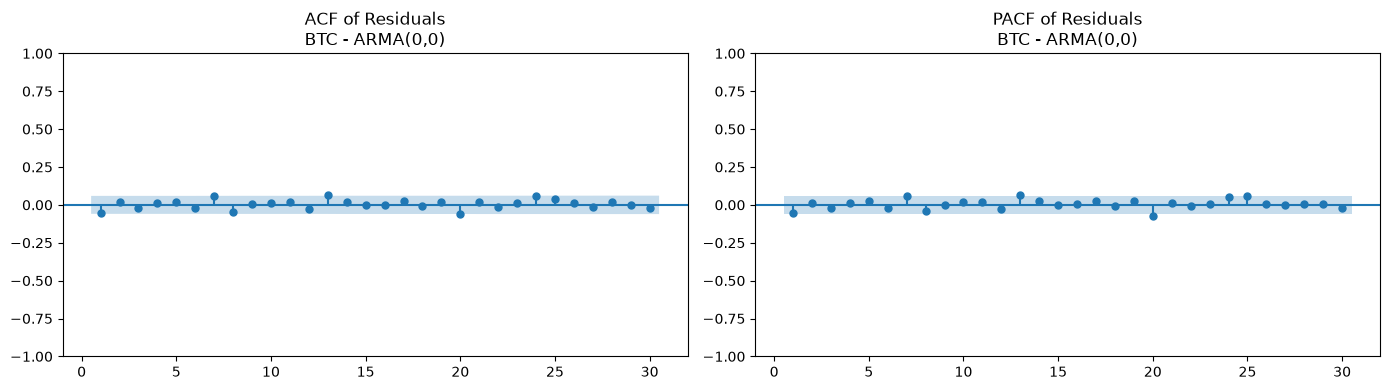

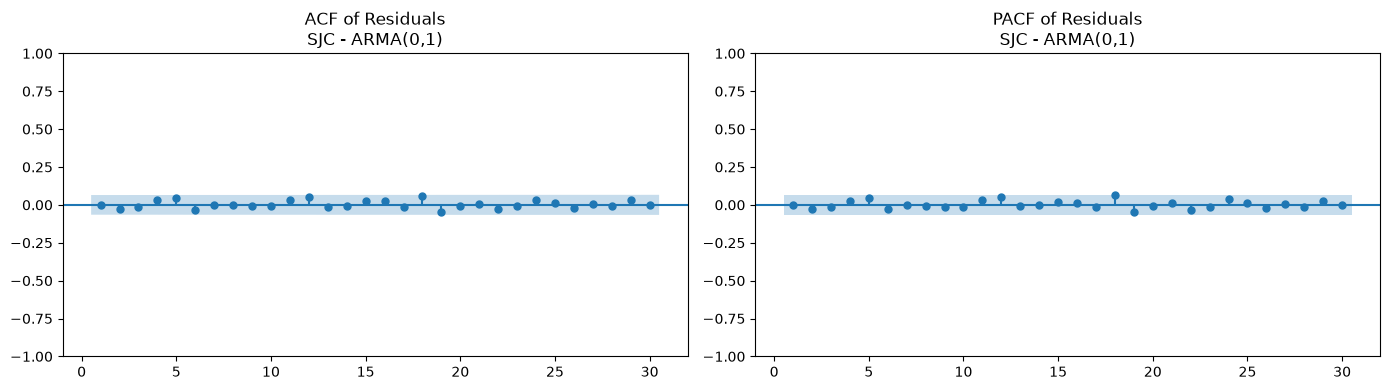

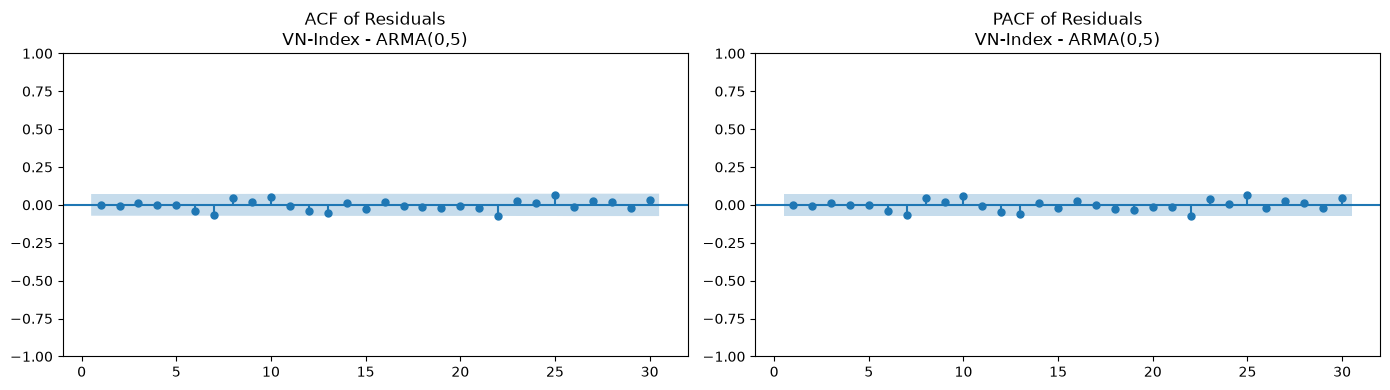

In [37]:
# ACF / PACF OF FINAL ARMA RESIDUALS
# =========================================================

final_residuals = {

    "BTC - ARMA(0,0)": btc_resid,

    "SJC - ARMA(0,1)": sjc_resid,

    "VN-Index - ARMA(0,5)": vnindex_resid

}


for name, residuals in final_residuals.items():

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4)
    )

    # ACF
    plot_acf(
        residuals,
        lags=30,
        zero=False,
        ax=axes[0]
    )

    axes[0].set_title(
        f"ACF of Residuals\n{name}"
    )


    # PACF
    plot_pacf(
        residuals,
        lags=30,
        zero=False,
        method="ywm",
        ax=axes[1]
    )

    axes[1].set_title(
        f"PACF of Residuals\n{name}"
    )


    plt.tight_layout()
    plt.show()

## Kết quả kiểm định
| Asset | Model | Ljung–Box conclusion | Quyết định |
|---|---|---|---|
| BTC | ARMA(0,0) | Không còn serial correlation | **Giữ** |
| SJC | ARMA(0,1) | Không còn serial correlation | **Giữ** |
| VN-Index | ARMA(0,5) | Không còn serial correlation tại các lag hợp lệ | **Giữ** |

# Kiểm định hiệu ứng ARCH bằng LM

In [38]:
import pandas as pd
from statsmodels.stats.diagnostic import het_arch

In [39]:
def arch_lm_test(residuals, asset_name, lags=[5, 10, 15, 20]):

    results = []

    for lag in lags:

        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
            residuals,
            nlags=lag
        )

        results.append({
            "Asset": asset_name,
            "Lag": lag,
            "LM_stat": lm_stat,
            "LM_pvalue": lm_pvalue,
            "F_stat": f_stat,
            "F_pvalue": f_pvalue
        })

    return pd.DataFrame(results)


In [40]:
# 2. RUN ARCH-LM TEST
# =========================================================

btc_arch = arch_lm_test(
    btc_resid,
    "BTC"
)

sjc_arch = arch_lm_test(
    sjc_resid,
    "SJC"
)

vnindex_arch = arch_lm_test(
    vnindex_resid,
    "VN-Index"
)


# =========================================================
# 3. PRINT INDIVIDUAL RESULTS
# =========================================================

print("=" * 80)
print("ARCH-LM TEST - BTC ARMA(0,0) RESIDUALS")
print("=" * 80)
print(
    btc_arch
    .round(6)
    .to_string(index=False)
)


print("\n" + "=" * 80)
print("ARCH-LM TEST - SJC ARMA(0,1) RESIDUALS")
print("=" * 80)
print(
    sjc_arch
    .round(6)
    .to_string(index=False)
)


print("\n" + "=" * 80)
print("ARCH-LM TEST - VN-INDEX ARMA(0,5) RESIDUALS")
print("=" * 80)
print(
    vnindex_arch
    .round(6)
    .to_string(index=False)
)


# =========================================================
# 4. COMBINE ALL RESULTS
# =========================================================

arch_lm_results = pd.concat(
    [
        btc_arch,
        sjc_arch,
        vnindex_arch
    ],
    ignore_index=True
)
arch_lm_results["ARCH_effect_5pct"] = (
    arch_lm_results["LM_pvalue"] < 0.05
)


print("\n" + "=" * 100)
print("ARCH-LM DIAGNOSTIC SUMMARY")
print("=" * 100)

print(
    arch_lm_results
    .round(6)
    .to_string(index=False)
)


ARCH-LM TEST - BTC ARMA(0,0) RESIDUALS
Asset  Lag   LM_stat  LM_pvalue    F_stat  F_pvalue
  BTC    5 62.962545        0.0 13.290247       0.0
  BTC   10 67.262630        0.0  7.097740       0.0
  BTC   15 67.556841        0.0  4.732910       0.0
  BTC   20 71.244090        0.0  3.740337       0.0

ARCH-LM TEST - SJC ARMA(0,1) RESIDUALS
Asset  Lag    LM_stat  LM_pvalue    F_stat  F_pvalue
  SJC    5 151.420036        0.0 36.135746       0.0
  SJC   10 158.950023        0.0 19.072715       0.0
  SJC   15 160.615049        0.0 12.819099       0.0
  SJC   20 160.476996        0.0  9.560030       0.0

ARCH-LM TEST - VN-INDEX ARMA(0,5) RESIDUALS
   Asset  Lag    LM_stat  LM_pvalue    F_stat  F_pvalue
VN-Index    5  89.571227        0.0 20.208926       0.0
VN-Index   10  96.822757        0.0 10.980291       0.0
VN-Index   15 105.578964        0.0  8.045126       0.0
VN-Index   20 107.215557        0.0  6.106493       0.0

ARCH-LM DIAGNOSTIC SUMMARY
   Asset  Lag    LM_stat  LM_pvalue    F_st

## Kết quả kiểm định
| Asset | Final mean model | ARCH-LM | Kết luận |
|---|---|---|---|
| BTC | ARMA(0,0) | p < 0.001 ở mọi lag | **Có ARCH effect** |
| SJC | ARMA(0,1) | p < 0.001 ở mọi lag | **Có ARCH effect** |
| VN-Index | ARMA(0,5) | p < 0.001 ở mọi lag | **Có ARCH effect** |

# Fit ARMA-EGARCH

In [41]:
# TWO-STEP EGARCH CANDIDATE SEARCH
#
# Input:
#   btc_resid
#   sjc_resid
#   vnindex_resid

import warnings
import numpy as np
import pandas as pd

from arch import arch_model
from statsmodels.stats.diagnostic import (acorr_ljungbox, het_arch)
warnings.filterwarnings("ignore")

# 1. CANDIDATE SPECIFICATIONS
egarch_candidates = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2),
    ]

# 2. ASSET RESIDUALS
residual_series = {
    "BTC": btc_resid,
    "SJC": sjc_resid,
    "VN-Index": vnindex_resid
}

# 3. STORAGE
egarch_results = []
egarch_fitted_models = {}


# 4. FIT ALL CANDIDATE MODELS
for asset, residuals in residual_series.items():

    residuals = residuals.dropna()

    print(f"FITTING EGARCH CANDIDATES - {asset}")
    print("=" * 90)

    for p, o, q in egarch_candidates:

        model_name = f"EGARCH({p},{o},{q})-t"

        try:

            model = arch_model(
                residuals,
                mean="Zero",
                vol="EGARCH",
                p=p,
                o=o,
                q=q,
                dist="t",
                rescale=False
            )

            result = model.fit(
                disp="off",
                show_warning=False
            )

            # Save fitted model
            egarch_fitted_models[
                (asset, p, o, q)
            ] = result


            # -------------------------------------------------
            # Convergence
            # convergence_flag = 0 means successful convergence
            # -------------------------------------------------

            converged = (result.convergence_flag == 0)

            # -------------------------------------------------
            # Standardized residuals
            #
            # z_t = epsilon_t / sigma_t
            # -------------------------------------------------

            std_resid = (result.resid/ result.conditional_volatility).dropna()


            # -------------------------------------------------
            # Ljung-Box on standardized residuals
            #
            # H0: no residual autocorrelation
            # Desired: p > 0.05
            # -------------------------------------------------

            lb = acorr_ljungbox(
                std_resid,
                lags=[10, 15, 20],
                return_df=True
            )

            # -------------------------------------------------
            # ARCH-LM on standardized residuals
            #
            # H0: no remaining ARCH effect
            # Desired: p > 0.05
            # -------------------------------------------------

            arch_10 = het_arch(
                std_resid,
                nlags=10
            )

            arch_15 = het_arch(
                std_resid,
                nlags=15
            )

            arch_20 = het_arch(
                std_resid,
                nlags=20
            )


            # -------------------------------------------------
            # Extract parameters
            # -------------------------------------------------

            params = result.params
            pvalues = result.pvalues


            # Student-t degrees of freedom
            nu = params.get(
                "nu",
                np.nan
            )

            nu_pvalue = pvalues.get(
                "nu",
                np.nan
            )


            # -------------------------------------------------
            # Save result
            # -------------------------------------------------

            egarch_results.append({

                "Asset": asset,

                "Model": model_name,

                "p": p,
                "o": o,
                "q": q,

                "LogLik": result.loglikelihood,

                "AIC": result.aic,

                "BIC": result.bic,

                "Converged": converged,

                # Ljung-Box standardized residual
                "LB_p10": lb.loc[10, "lb_pvalue"],
                "LB_p15": lb.loc[15, "lb_pvalue"],
                "LB_p20": lb.loc[20, "lb_pvalue"],

                # ARCH-LM standardized residual
                "ARCH_p10": arch_10[1],
                "ARCH_p15": arch_15[1],
                "ARCH_p20": arch_20[1],

                # Student-t degrees of freedom
                "nu": nu,
                "nu_pvalue": nu_pvalue
            })


            print(
                f"{model_name:<20} "
                f"AIC={result.aic:10.4f}  "
                f"BIC={result.bic:10.4f}  "
                f"Converged={converged}"
            )


        except Exception as e:

            print(
                f"{model_name:<20} FAILED: {e}"
            )

# 5. CREATE RESULTS TABLE
egarch_table = pd.DataFrame(egarch_results)
# 6. DIAGNOSTIC PASS INDICATORS
egarch_table["Pass_LB"] = (
    (egarch_table["LB_p10"] > 0.05)
    & (egarch_table["LB_p15"] > 0.05)
    & (egarch_table["LB_p20"] > 0.05)
)

egarch_table["Pass_ARCH"] = (
    (egarch_table["ARCH_p10"] > 0.05)
    & (egarch_table["ARCH_p15"] > 0.05)
    & (egarch_table["ARCH_p20"] > 0.05)
)

egarch_table["Pass_All"] = (
    egarch_table["Converged"]
    & egarch_table["Pass_LB"]
    & egarch_table["Pass_ARCH"]
)
# 7. PRINT ALL MODELS
# =========================================================

print("\n" + "=" * 140)
print("ALL EGARCH CANDIDATE RESULTS")
print("=" * 140)

print(
    egarch_table[
        [
            "Asset",
            "Model",
            "AIC",
            "BIC",
            "Converged",
            "LB_p10",
            "LB_p15",
            "LB_p20",
            "ARCH_p10",
            "ARCH_p15",
            "ARCH_p20",
            "Pass_LB",
            "Pass_ARCH",
            "Pass_All"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

FITTING EGARCH CANDIDATES - BTC
EGARCH(1,1,1)-t      AIC= 4893.8366  BIC= 4918.8337  Converged=True
EGARCH(1,1,2)-t      AIC= 4893.2411  BIC= 4923.2376  Converged=True
EGARCH(2,1,1)-t      AIC= 4892.3675  BIC= 4922.3640  Converged=True
EGARCH(2,1,2)-t      AIC= 4894.3667  BIC= 4929.3627  Converged=True
FITTING EGARCH CANDIDATES - SJC
EGARCH(1,1,1)-t      AIC= 1974.4628  BIC= 1998.5246  Converged=True
EGARCH(1,1,2)-t      AIC= 1976.3541  BIC= 2005.2282  Converged=True
EGARCH(2,1,1)-t      AIC= 1975.7686  BIC= 2004.6427  Converged=True
EGARCH(2,1,2)-t      AIC= 1966.6687  BIC= 2000.3551  Converged=True
FITTING EGARCH CANDIDATES - VN-Index
EGARCH(1,1,1)-t      AIC= 2107.1966  BIC= 2130.2769  Converged=True
EGARCH(1,1,2)-t      AIC= 2108.9213  BIC= 2136.6177  Converged=True
EGARCH(2,1,1)-t      AIC= 2109.1262  BIC= 2136.8226  Converged=True
EGARCH(2,1,2)-t      AIC= 2109.8013  BIC= 2142.1137  Converged=True

ALL EGARCH CANDIDATE RESULTS
   Asset           Model       AIC       BIC  Converg

In [42]:
# 8. RANK MODELS BY AIC WITHIN EACH ASSET
# =========================================================

egarch_ranked = (
    egarch_table
    .sort_values(
        ["Asset", "AIC"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 140)
print("EGARCH CANDIDATES RANKED BY AIC")
print("=" * 140)

print(
    egarch_ranked[
        [
            "Asset",
            "Model",
            "AIC",
            "BIC",
            "Converged",
            "Pass_LB",
            "Pass_ARCH",
            "Pass_All"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# =========================================================
# 9. BEST DIAGNOSTIC-PASSING MODEL BY AIC
#
# Selection rule:
# 1. Converged
# 2. Pass Ljung-Box
# 3. Pass ARCH-LM
# 4. Lowest AIC
# =========================================================

best_models = []

for asset in residual_series.keys():

    asset_models = egarch_table[
        egarch_table["Asset"] == asset
    ].copy()

    passing_models = asset_models[
        asset_models["Pass_All"]
    ].copy()

    if len(passing_models) > 0:

        best = (
            passing_models
            .sort_values("AIC")
            .iloc[0]
        )

        selection_note = (
            "Lowest AIC among models passing all diagnostics"
        )

    else:

        # If no model passes all diagnostics,
        # report lowest-AIC converged model for review.
        converged_models = asset_models[
            asset_models["Converged"]
        ].copy()

        if len(converged_models) > 0:

            best = (
                converged_models
                .sort_values("AIC")
                .iloc[0]
            )

            selection_note = (
                "No model passed all diagnostics; "
                "lowest-AIC converged model shown for review"
            )

        else:

            continue


    best_models.append({

        "Asset": asset,

        "Selected_model": best["Model"],

        "AIC": best["AIC"],

        "BIC": best["BIC"],

        "LB_p10": best["LB_p10"],

        "LB_p15": best["LB_p15"],

        "LB_p20": best["LB_p20"],

        "ARCH_p10": best["ARCH_p10"],

        "ARCH_p15": best["ARCH_p15"],

        "ARCH_p20": best["ARCH_p20"],

        "Selection_note": selection_note
    })


best_egarch_table = pd.DataFrame(
    best_models
)


print("\n" + "=" * 140)
print("PRELIMINARY BEST EGARCH MODELS")
print("=" * 140)

print(
    best_egarch_table
    .round(4)
    .to_string(index=False)
)


EGARCH CANDIDATES RANKED BY AIC
   Asset           Model       AIC       BIC  Converged  Pass_LB  Pass_ARCH  Pass_All
     BTC EGARCH(2,1,1)-t 4892.3675 4922.3640       True     True       True      True
     BTC EGARCH(1,1,2)-t 4893.2411 4923.2376       True     True       True      True
     BTC EGARCH(1,1,1)-t 4893.8366 4918.8337       True     True      False     False
     BTC EGARCH(2,1,2)-t 4894.3667 4929.3627       True     True       True      True
     SJC EGARCH(2,1,2)-t 1966.6687 2000.3551       True     True       True      True
     SJC EGARCH(1,1,1)-t 1974.4628 1998.5246       True     True       True      True
     SJC EGARCH(2,1,1)-t 1975.7686 2004.6427       True     True       True      True
     SJC EGARCH(1,1,2)-t 1976.3541 2005.2282       True     True       True      True
VN-Index EGARCH(1,1,1)-t 2107.1966 2130.2769       True     True       True      True
VN-Index EGARCH(1,1,2)-t 2108.9213 2136.6177       True     True       True      True
VN-Index EGARCH(2,1,1

In [43]:
# =========================================================
# PARAMETER SIGNIFICANCE OF LEADING EGARCH CANDIDATES
# =========================================================

models_to_check = {

    "BTC - EGARCH(2,1,1)-t":
        egarch_fitted_models[("BTC", 2, 1, 1)],

    "BTC - EGARCH(1,1,2)-t":
        egarch_fitted_models[("BTC", 1, 1, 2)],

    "SJC - EGARCH(2,1,2)-t":
        egarch_fitted_models[("SJC", 2, 1, 2)],

    "SJC - EGARCH(1,1,1)-t":
        egarch_fitted_models[("SJC", 1, 1, 1)],

    "VN-Index - EGARCH(1,1,1)-t":
        egarch_fitted_models[("VN-Index", 1, 1, 1)]
}


for name, result in models_to_check.items():

    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    parameter_table = pd.DataFrame({
        "Coefficient": result.params,
        "Std_Error": result.std_err,
        "t_stat": result.tvalues,
        "p_value": result.pvalues
    })

    parameter_table["Significant_5pct"] = (
        parameter_table["p_value"] < 0.05
    )

    print(
        parameter_table
        .round(6)
        .to_string()
    )


BTC - EGARCH(2,1,1)-t
          Coefficient  Std_Error     t_stat   p_value  Significant_5pct
omega        0.059176   0.046786   1.264839  0.205929             False
alpha[1]     0.282109   0.094845   2.974431  0.002935              True
alpha[2]    -0.172314   0.106315  -1.620791  0.105062             False
gamma[1]    -0.028740   0.037733  -0.761681  0.446251             False
beta[1]      0.977290   0.022519  43.398763  0.000000              True
nu           3.383788   0.422773   8.003789  0.000000              True

BTC - EGARCH(1,1,2)-t
          Coefficient  Std_Error    t_stat   p_value  Significant_5pct
omega        0.128588   0.090099  1.427184  0.153527             False
alpha[1]     0.201248   0.066877  3.009222  0.002619              True
gamma[1]    -0.071463   0.058154 -1.228858  0.219125             False
beta[1]      0.491853   0.148809  3.305267  0.000949              True
beta[2]      0.454762   0.155679  2.921152  0.003487              True
nu           3.440203   


| Asset | Final volatility model |
|---|---|
| BTC | **EGARCH(1,1,2)-t** |
| SJC | **EGARCH(1,1,1)-t** |
| VN-Index | **EGARCH(1,1,1)-t** |

## Kết quả ước lượng mô hình ARMA-EGARCH

Nghiên cứu sử dụng quy trình ước lượng hai bước. Trước hết, mô hình ARMA được ước lượng để lọc cấu trúc phụ thuộc trong phương trình trung bình. Sau đó, phần dư của mô hình ARMA được sử dụng để ước lượng mô hình EGARCH với phân phối Student-t.

### 1. Bitcoin

Phương trình trung bình của Bitcoin được xác định là ARMA(0,0):

$$
r_t^{BTC}
=
0.0778
+
\varepsilon_t
$$

Trong đó hệ số trung bình không có ý nghĩa thống kê ở mức 5%:

$$
p_{\mu}=0.295>0.05
$$

Điều này cho thấy lợi suất Bitcoin trong mẫu không có mức trung bình khác 0 một cách có ý nghĩa thống kê và không cần bổ sung thành phần AR hoặc MA trong phương trình trung bình.

Sau khi lọc phương trình trung bình, phần dư được mô hình hóa bằng EGARCH(1,1,2) với phân phối Student-t:

$$
\begin{aligned}
\log(\sigma_t^2)
=&\ 0.128588
+0.201248
\left(
|z_{t-1}|-E|z_{t-1}|
\right) \\
&-0.071463z_{t-1}
+0.491852\log(\sigma_{t-1}^2)
+0.454763\log(\sigma_{t-2}^2)
\end{aligned}
$$

với:

$$
z_t=\frac{\varepsilon_t}{\sigma_t},
\qquad
z_t\sim t_{\nu},
\qquad
\nu=3.440197
$$

Hệ số tác động của cú sốc:

$$
\alpha_1=0.201248,
\qquad
p=0.002619<0.05
$$

có ý nghĩa thống kê, cho thấy các cú sốc mới có tác động đáng kể đến biến động có điều kiện của Bitcoin.

Hai hệ số persistence:

$$
\beta_1=0.491852,
\qquad
p=0.000949<0.05
$$

và

$$
\beta_2=0.454763,
\qquad
p=0.003488<0.05
$$

đều có ý nghĩa thống kê. Điều này cho thấy volatility của Bitcoin có tính dai dẳng cao và chịu ảnh hưởng đáng kể từ mức biến động của hai kỳ trước.

Hệ số bất đối xứng:

$$
\gamma_1=-0.071463,
\qquad
p=0.219121>0.05
$$

không có ý nghĩa thống kê. Do đó, chưa có đủ bằng chứng để kết luận tồn tại hiệu ứng bất đối xứng hay leverage effect đối với Bitcoin.

Tham số bậc tự do của phân phối Student-t:

$$
\nu=3.440197
$$

cho thấy phân phối của phần dư có đuôi dày, phù hợp với đặc điểm của dữ liệu lợi suất Bitcoin.

Mô hình cuối cùng của Bitcoin là:

$$
\boxed{
ARMA(0,0)
\rightarrow
EGARCH(1,1,2)-t
}
$$

### 2. Vàng SJC

Phương trình trung bình của vàng SJC được xác định là ARMA(0,1):

$$
r_t^{SJC}
=
0.0804
+
\varepsilon_t
+
0.1063\varepsilon_{t-1}
$$

Trong đó:

$$
\mu=0.0804,
\qquad
p=0.039<0.05
$$

và

$$
\theta_1=0.1063,
\qquad
p<0.001
$$

Cả hệ số trung bình và hệ số MA(1) đều có ý nghĩa thống kê ở mức 5%.

Sau bước lọc ARMA, phần dư được mô hình hóa bằng EGARCH(1,1,1) với phân phối Student-t:

$$
\begin{aligned}
\log(\sigma_t^2)
=&\ 0.233727
+0.527076
\left(
|z_{t-1}|-E|z_{t-1}|
\right) \\
&+0.052913z_{t-1}
+0.959835\log(\sigma_{t-1}^2)
\end{aligned}
$$

với:

$$
z_t=\frac{\varepsilon_t}{\sigma_t},
\qquad
z_t\sim t_{\nu},
\qquad
\nu=2.242461
$$

Hệ số phản ứng với cú sốc:

$$
\alpha_1=0.527076,
\qquad
p=0.030076<0.05
$$

có ý nghĩa thống kê, cho thấy các cú sốc mới có tác động đáng kể đến volatility của vàng SJC.

Hệ số persistence:

$$
\beta_1=0.959835,
\qquad
p<0.001
$$

có giá trị rất gần 1 và có ý nghĩa thống kê mạnh. Điều này cho thấy volatility của vàng SJC có độ dai dẳng rất cao; một cú sốc làm biến động tăng lên có thể để lại ảnh hưởng trong nhiều kỳ tiếp theo.

Hệ số bất đối xứng:

$$
\gamma_1=0.052913,
\qquad
p=0.457595>0.05
$$

không có ý nghĩa thống kê. Do đó, chưa có bằng chứng cho thấy các cú sốc âm và dương có tác động bất đối xứng đáng kể lên volatility của vàng SJC.

Tham số Student-t:

$$
\nu=2.242461
$$

khá thấp, phản ánh đặc điểm heavy-tail rất mạnh trong phân phối của phần dư.

Mô hình cuối cùng của vàng SJC là:

$$
\boxed{
ARMA(0,1)
\rightarrow
EGARCH(1,1,1)-t
}
$$

### 3. VN-Index

Phương trình trung bình của VN-Index được xác định là ARMA(0,5):

$$
\begin{aligned}
r_t^{VN}
=&\ 0.0472
+\varepsilon_t
+0.1130\varepsilon_{t-1}
-0.0206\varepsilon_{t-2} \\
&-0.0424\varepsilon_{t-3}
-0.0900\varepsilon_{t-4}
+0.1002\varepsilon_{t-5}
\end{aligned}
$$

Các hệ số MA có kết quả:

$$
\theta_1=0.1130,
\qquad
p<0.001
$$

$$
\theta_2=-0.0206,
\qquad
p=0.345
$$

$$
\theta_3=-0.0424,
\qquad
p=0.164
$$

$$
\theta_4=-0.0900,
\qquad
p=0.002
$$

$$
\theta_5=0.1002,
\qquad
p=0.001
$$

Trong đó MA(1), MA(4) và MA(5) có ý nghĩa thống kê ở mức 5%. Mặc dù MA(2) và MA(3) không có ý nghĩa riêng lẻ, mô hình ARMA(0,5) vẫn được giữ dựa trên tiêu chí lựa chọn mô hình và kết quả kiểm định Ljung–Box trên phần dư.

Sau bước lọc phương trình trung bình, phần dư được mô hình hóa bằng EGARCH(1,1,1) với phân phối Student-t:

$$
\begin{aligned}
\log(\sigma_t^2)
=&\ 0.026968
+0.250879
\left(
|z_{t-1}|-E|z_{t-1}|
\right) \\
&-0.133405z_{t-1}
+0.911087\log(\sigma_{t-1}^2)
\end{aligned}
$$

với:

$$
z_t=\frac{\varepsilon_t}{\sigma_t},
\qquad
z_t\sim t_{\nu},
\qquad
\nu=4.343134
$$

Hệ số tác động của cú sốc:

$$
\alpha_1=0.250879,
\qquad
p=0.000310<0.05
$$

có ý nghĩa thống kê mạnh, cho thấy các cú sốc mới có ảnh hưởng đáng kể đến volatility của VN-Index.

Hệ số persistence:

$$
\beta_1=0.911087,
\qquad
p<0.001
$$

cho thấy volatility của VN-Index có tính dai dẳng cao.

Đặc biệt, hệ số bất đối xứng:

$$
\gamma_1=-0.133405,
\qquad
p=0.018018<0.05
$$

vừa mang dấu âm vừa có ý nghĩa thống kê ở mức 5%. Do đó, tồn tại bằng chứng về hiệu ứng bất đối xứng trong volatility của VN-Index.

Với hai cú sốc có cùng độ lớn, cú sốc âm có tác động làm tăng biến động có điều kiện mạnh hơn cú sốc dương. Kết quả này cho thấy VN-Index có tồn tại leverage effect trong giai đoạn nghiên cứu.

Tham số Student-t:

$$
\nu=4.343134
$$

cho thấy phân phối của phần dư có đuôi dày hơn phân phối chuẩn.

Mô hình cuối cùng của VN-Index là:

$$
\boxed{
ARMA(0,5)
\rightarrow
EGARCH(1,1,1)-t
}
$$

### 4. Tổng hợp kết quả

$$
\begin{aligned}
BTC &: ARMA(0,0)\rightarrow EGARCH(1,1,2)-t, \\
SJC &: ARMA(0,1)\rightarrow EGARCH(1,1,1)-t, \\
VN\text{-}Index &: ARMA(0,5)\rightarrow EGARCH(1,1,1)-t
\end{aligned}
$$

Kết quả về hiệu ứng bất đối xứng:

$$
\begin{aligned}
BTC &: \gamma=-0.071463,\quad p=0.219121
\Rightarrow \text{không có bằng chứng về leverage effect}, \\
SJC &: \gamma=0.052913,\quad p=0.457595
\Rightarrow \text{không có bằng chứng về leverage effect}, \\
VN\text{-}Index &: \gamma=-0.133405,\quad p=0.018018
\Rightarrow \text{có leverage effect có ý nghĩa thống kê}
\end{aligned}
$$

Nhìn chung, cả ba tài sản đều thể hiện tính dai dẳng của volatility. Tuy nhiên, chỉ VN-Index cho thấy bằng chứng thống kê về tác động bất đối xứng của cú sốc, trong đó các cú sốc tiêu cực làm volatility gia tăng mạnh hơn các cú sốc tích cực có cùng độ lớn.

Do mô hình được ước lượng theo quy trình hai bước, các phương trình ARMA và EGARCH không được ước lượng đồng thời. Vì vậy, kết quả được diễn giải dưới dạng **ARMA filtering followed by EGARCH estimation**.

## Diagnostics cho 3 mô hình

In [44]:
# =========================================================
# MODEL 1 - FINAL EGARCH MODELS, DIAGNOSTICS AND OUTPUTS
#
# Final specifications:
# BTC      : ARMA(0,0) -> EGARCH(1,1,2)-t
# SJC      : ARMA(0,1) -> EGARCH(1,1,1)-t
# VN-Index : ARMA(0,5) -> EGARCH(1,1,1)-t
#
# Two-step estimation:
# ARMA residuals -> Zero-mean EGARCH
# =========================================================

import numpy as np
import pandas as pd

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)


# =========================================================
# 1. ASSIGN FINAL EGARCH MODEL OBJECTS
# =========================================================

btc_egarch_final = egarch_fitted_models[
    ("BTC", 1, 1, 2)
]

sjc_egarch_final = egarch_fitted_models[
    ("SJC", 1, 1, 1)
]

vnindex_egarch_final = egarch_fitted_models[
    ("VN-Index", 1, 1, 1)
]


# =========================================================
# 2. SAVE CONDITIONAL VOLATILITY
#
# sigma_t = conditional standard deviation
# NOT conditional variance
# =========================================================

btc_volatility = (
    btc_egarch_final
    .conditional_volatility
    .dropna()
)

sjc_volatility = (
    sjc_egarch_final
    .conditional_volatility
    .dropna()
)

vnindex_volatility = (
    vnindex_egarch_final
    .conditional_volatility
    .dropna()
)


# =========================================================
# 3. SAVE STANDARDIZED RESIDUALS
#
# z_t = epsilon_t / sigma_t
# =========================================================

btc_std_resid = (
    btc_egarch_final.resid
    / btc_egarch_final.conditional_volatility
).dropna()

sjc_std_resid = (
    sjc_egarch_final.resid
    / sjc_egarch_final.conditional_volatility
).dropna()

vnindex_std_resid = (
    vnindex_egarch_final.resid
    / vnindex_egarch_final.conditional_volatility
).dropna()


# =========================================================
# 4. FINAL SERIES DICTIONARIES
# =========================================================

final_models = {
    "BTC": btc_egarch_final,
    "SJC": sjc_egarch_final,
    "VN-Index": vnindex_egarch_final
}

final_std_resids = {
    "BTC": btc_std_resid,
    "SJC": sjc_std_resid,
    "VN-Index": vnindex_std_resid
}

final_volatility = {
    "BTC": btc_volatility,
    "SJC": sjc_volatility,
    "VN-Index": vnindex_volatility
}

final_model_names = {
    "BTC": "EGARCH(1,1,2)-t",
    "SJC": "EGARCH(1,1,1)-t",
    "VN-Index": "EGARCH(1,1,1)-t"
}


# =========================================================
# 5. FINAL DIAGNOSTICS
#
# Tests:
#
# A. Ljung-Box on z_t
#    H0: no autocorrelation in standardized residuals
#
# B. Ljung-Box on z_t^2
#    H0: no autocorrelation in squared standardized residuals
#
# C. ARCH-LM on z_t
#    H0: no remaining ARCH effect
#
# Desired for all tests:
# p-value > 0.05
# =========================================================

lags = [10, 15, 20]

diagnostic_results = []


for asset, std_resid in final_std_resids.items():

    # -----------------------------------------------------
    # Ljung-Box on standardized residuals z_t
    # -----------------------------------------------------

    lb_std = acorr_ljungbox(
        std_resid,
        lags=lags,
        return_df=True
    )


    # -----------------------------------------------------
    # Ljung-Box on squared standardized residuals z_t^2
    # -----------------------------------------------------

    lb_sq = acorr_ljungbox(
        std_resid ** 2,
        lags=lags,
        return_df=True
    )


    # -----------------------------------------------------
    # ARCH-LM
    # -----------------------------------------------------

    arch_10 = het_arch(
        std_resid,
        nlags=10
    )

    arch_15 = het_arch(
        std_resid,
        nlags=15
    )

    arch_20 = het_arch(
        std_resid,
        nlags=20
    )


    # -----------------------------------------------------
    # Model object
    # -----------------------------------------------------

    result = final_models[asset]


    # -----------------------------------------------------
    # Store diagnostics
    # -----------------------------------------------------

    diagnostic_results.append({

        "Asset": asset,

        "Model": final_model_names[asset],

        "AIC": result.aic,

        "BIC": result.bic,

        "LogLik": result.loglikelihood,

        "Converged":
            result.convergence_flag == 0,

        # Ljung-Box standardized residual
        "LB_z_p10":
            lb_std.loc[10, "lb_pvalue"],

        "LB_z_p15":
            lb_std.loc[15, "lb_pvalue"],

        "LB_z_p20":
            lb_std.loc[20, "lb_pvalue"],

        # Ljung-Box squared standardized residual
        "LB_z2_p10":
            lb_sq.loc[10, "lb_pvalue"],

        "LB_z2_p15":
            lb_sq.loc[15, "lb_pvalue"],

        "LB_z2_p20":
            lb_sq.loc[20, "lb_pvalue"],

        # ARCH-LM
        "ARCH_p10":
            arch_10[1],

        "ARCH_p15":
            arch_15[1],

        "ARCH_p20":
            arch_20[1]
    })


# =========================================================
# 6. FINAL DIAGNOSTIC TABLE
# =========================================================

model1_final_diagnostics = pd.DataFrame(
    diagnostic_results
)


# =========================================================
# 7. PASS / FAIL INDICATORS
# =========================================================

model1_final_diagnostics["Pass_LB_z"] = (

    (model1_final_diagnostics["LB_z_p10"] > 0.05)

    &

    (model1_final_diagnostics["LB_z_p15"] > 0.05)

    &

    (model1_final_diagnostics["LB_z_p20"] > 0.05)
)


model1_final_diagnostics["Pass_LB_z2"] = (

    (model1_final_diagnostics["LB_z2_p10"] > 0.05)

    &

    (model1_final_diagnostics["LB_z2_p15"] > 0.05)

    &

    (model1_final_diagnostics["LB_z2_p20"] > 0.05)
)


model1_final_diagnostics["Pass_ARCH"] = (

    (model1_final_diagnostics["ARCH_p10"] > 0.05)

    &

    (model1_final_diagnostics["ARCH_p15"] > 0.05)

    &

    (model1_final_diagnostics["ARCH_p20"] > 0.05)
)


model1_final_diagnostics["Pass_All"] = (

    model1_final_diagnostics["Converged"]

    & model1_final_diagnostics["Pass_LB_z"]

    & model1_final_diagnostics["Pass_LB_z2"]

    & model1_final_diagnostics["Pass_ARCH"]
)


# =========================================================
# 8. PRINT FINAL DIAGNOSTICS
# =========================================================

print("\n" + "=" * 160)
print("MODEL 1 - FINAL ARMA-EGARCH DIAGNOSTICS")
print("=" * 160)

print(
    model1_final_diagnostics[
        [
            "Asset",
            "Model",
            "AIC",
            "BIC",
            "Converged",

            "LB_z_p10",
            "LB_z_p15",
            "LB_z_p20",

            "LB_z2_p10",
            "LB_z2_p15",
            "LB_z2_p20",

            "ARCH_p10",
            "ARCH_p15",
            "ARCH_p20",

            "Pass_LB_z",
            "Pass_LB_z2",
            "Pass_ARCH",
            "Pass_All"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# =========================================================
# 9. VOLATILITY SUMMARY
#
# sigma_t, not sigma_t^2
# =========================================================

volatility_summary = pd.DataFrame({

    "Asset": [
        "BTC",
        "SJC",
        "VN-Index"
    ],

    "N": [
        len(btc_volatility),
        len(sjc_volatility),
        len(vnindex_volatility)
    ],

    "Mean_volatility": [
        btc_volatility.mean(),
        sjc_volatility.mean(),
        vnindex_volatility.mean()
    ],

    "Median_volatility": [
        btc_volatility.median(),
        sjc_volatility.median(),
        vnindex_volatility.median()
    ],

    "Std_volatility": [
        btc_volatility.std(),
        sjc_volatility.std(),
        vnindex_volatility.std()
    ],

    "Min_volatility": [
        btc_volatility.min(),
        sjc_volatility.min(),
        vnindex_volatility.min()
    ],

    "Max_volatility": [
        btc_volatility.max(),
        sjc_volatility.max(),
        vnindex_volatility.max()
    ]
})


print("\n" + "=" * 100)
print("MODEL 1 - CONDITIONAL VOLATILITY SUMMARY")
print("=" * 100)

print(
    volatility_summary
    .round(4)
    .to_string(index=False)
)


# =========================================================
# 10. CONFIRM SAVED OUTPUT VARIABLES
# =========================================================

# print("\n" + "=" * 100)
print("MODEL 1 OUTPUT VARIABLES SAVED")
# print("=" * 100)

print(
    '''
Final EGARCH models:
    btc_egarch_final
    sjc_egarch_final
    vnindex_egarch_final

Conditional volatility:
    btc_volatility
    sjc_volatility
    vnindex_volatility

Standardized residuals:
    btc_std_resid
    sjc_std_resid
    vnindex_std_resid

Summary tables:
    model1_final_diagnostics
    volatility_summary
 ''')


MODEL 1 - FINAL ARMA-EGARCH DIAGNOSTICS
   Asset           Model       AIC       BIC  Converged  LB_z_p10  LB_z_p15  LB_z_p20  LB_z2_p10  LB_z2_p15  LB_z2_p20  ARCH_p10  ARCH_p15  ARCH_p20  Pass_LB_z  Pass_LB_z2  Pass_ARCH  Pass_All
     BTC EGARCH(1,1,2)-t 4893.2411 4923.2376       True    0.7969    0.6547    0.7410     0.0334     0.0863     0.2765    0.0533    0.1341    0.2254       True       False       True     False
     SJC EGARCH(1,1,1)-t 1974.4628 1998.5246       True    0.7803    0.9300    0.9670     0.9996     0.9997     1.0000    0.9994    0.9996    1.0000       True        True       True      True
VN-Index EGARCH(1,1,1)-t 2107.1966 2130.2769       True    0.5220    0.6570    0.8075     0.9980     1.0000     1.0000    0.9981    1.0000    1.0000       True        True       True      True

MODEL 1 - CONDITIONAL VOLATILITY SUMMARY
   Asset    N  Mean_volatility  Median_volatility  Std_volatility  Min_volatility  Max_volatility
     BTC 1096           2.6118             2.53

| Asset | LB \(z_t\), lag 10 | ARCH-LM, lag 10 | LB \(z_t^2\), lag 10 | Đánh giá |
|---|---:|---:|---:|---|
| BTC | 0.7969 | 0.0533 | 0.0334 | **Chấp nhận, còn dependence nhẹ ở variance** |
| SJC | 0.7803 | 0.9994 | 0.9996 | **Chấp nhận** |
| VN-Index | 0.5220 | 0.9981 | 0.9980 | **Chấp nhận** |

## Tổng hợp kiểm định chẩn đoán Model 1

Sau khi ước lượng mô hình ARMA-EGARCH theo quy trình hai bước, các kiểm định chẩn đoán được thực hiện trên phần dư chuẩn hóa:

$$
z_t=\frac{\varepsilon_t}{\sigma_t}
$$

và bình phương phần dư chuẩn hóa:

$$
z_t^2
$$

### 1. Kiểm định Ljung-Box trên phần dư chuẩn hóa

Giả thuyết kiểm định:

$$
H_0:\rho_1=\rho_2=\cdots=\rho_m=0
$$

tức là phần dư chuẩn hóa không còn tự tương quan.

$$
H_1:\exists \rho_j\neq0
$$

tức là vẫn còn tự tương quan trong phần dư chuẩn hóa.

Quy tắc quyết định ở mức ý nghĩa 5%:

$$
p\text{-value}>0.05
\Rightarrow
\text{không bác bỏ }H_0
$$

$$
p\text{-value}<0.05
\Rightarrow
\text{bác bỏ }H_0
$$

Kết quả tại lag 10:

$$
\begin{aligned}
BTC &: p=0.7969>0.05,\\
SJC &: p=0.7803>0.05,\\
VN\text{-}Index &: p=0.5220>0.05.
\end{aligned}
$$

Do đó, cả ba mô hình đều không còn tự tương quan đáng kể trong phần dư chuẩn hóa.

---

### 2. Kiểm định Ljung-Box trên bình phương phần dư chuẩn hóa

Kiểm định được thực hiện trên $z_t^2$ nhằm kiểm tra xem còn biến phụ thuộc trong phương sai hay không.

Giả thuyết:

$$
H_0:
\rho_1(z_t^2)=\rho_2(z_t^2)=\cdots=\rho_m(z_t^2)=0
$$

$$
H_1:
\exists \rho_j(z_t^2)\neq0
$$

Quy tắc quyết định:

$$
p\text{-value}>0.05
\Rightarrow
\text{không bác bỏ }H_0
$$

$$
p\text{-value}<0.05
\Rightarrow
\text{bác bỏ }H_0
$$

Tại lag 10:

$$
\begin{aligned}
BTC &: p=0.0334<0.05,\\
SJC &: p=0.9996>0.05,\\
VN\text{-}Index &: p=0.9980>0.05.
\end{aligned}
$$

SJC và VN-Index không còn phụ thuộc đáng kể trong bình phương phần dư chuẩn hóa.

Đối với BTC, kiểm định tại lag 10 cho thấy còn một mức phụ thuộc ngắn hạn trong phương sai. Tuy nhiên, kết quả này không còn có ý nghĩa tại các lag 15 và 20, do đó được xem là bằng chứng yếu về phần phụ thuộc còn sót lại.

---

### 3. Kiểm định Engle ARCH-LM sau EGARCH

ARCH-LM được sử dụng để kiểm tra liệu phần dư chuẩn hóa còn hiệu ứng ARCH hay không.

Giả thuyết:

$$
H_0:
\alpha_1=\alpha_2=\cdots=\alpha_m=0
$$

tức là không còn hiệu ứng ARCH.

$$
H_1:
\exists \alpha_j\neq0
$$

tức là vẫn còn hiệu ứng ARCH.

Quy tắc quyết định ở mức ý nghĩa 5%:

$$
p\text{-value}>0.05
\Rightarrow
\text{không bác bỏ }H_0
$$

$$
p\text{-value}<0.05
\Rightarrow
\text{bác bỏ }H_0
$$

Kết quả tại lag 10:

$$
\begin{aligned}
BTC &: p=0.0533>0.05,\\
SJC &: p=0.9994>0.05,\\
VN\text{-}Index &: p=0.9981>0.05.
\end{aligned}
$$

Do đó, ở mức ý nghĩa 5%, không có bằng chứng về hiệu ứng ARCH còn lại trong cả ba mô hình.

---

### 4. Kết luận


Nhìn chung, cả ba mô hình EGARCH đều xử lý tốt tự tương quan và hiệu ứng ARCH trong phần dư chuẩn hóa. BTC còn một dấu hiệu phụ thuộc nhẹ trong bình phương phần dư tại lag 10, nhưng kết quả này không ổn định ở các lag cao hơn và ARCH-LM vẫn không bác bỏ giả thuyết không còn ARCH effect ở mức 5%.

Đối với BTC, mô hình EGARCH đã loại bỏ phần lớn hiện tượng phương sai có điều kiện. Tuy nhiên, Ljung-Box trên bình phương phần dư chuẩn hóa tại lag 10 vẫn có ý nghĩa thống kê, cho thấy còn một mức *phụ thuộc ngắn hạn* trong biến động. Kết quả này không còn ý nghĩa thống kê tại lag 15 và 20, cho thấy bằng chứng về phần phụ thuộc còn sót lại không bền vững khi tăng độ trễ, và không đủ mạnh để bác bỏ tính phù hợp tổng thể của mô hình.

### Vẽ plot Volatility

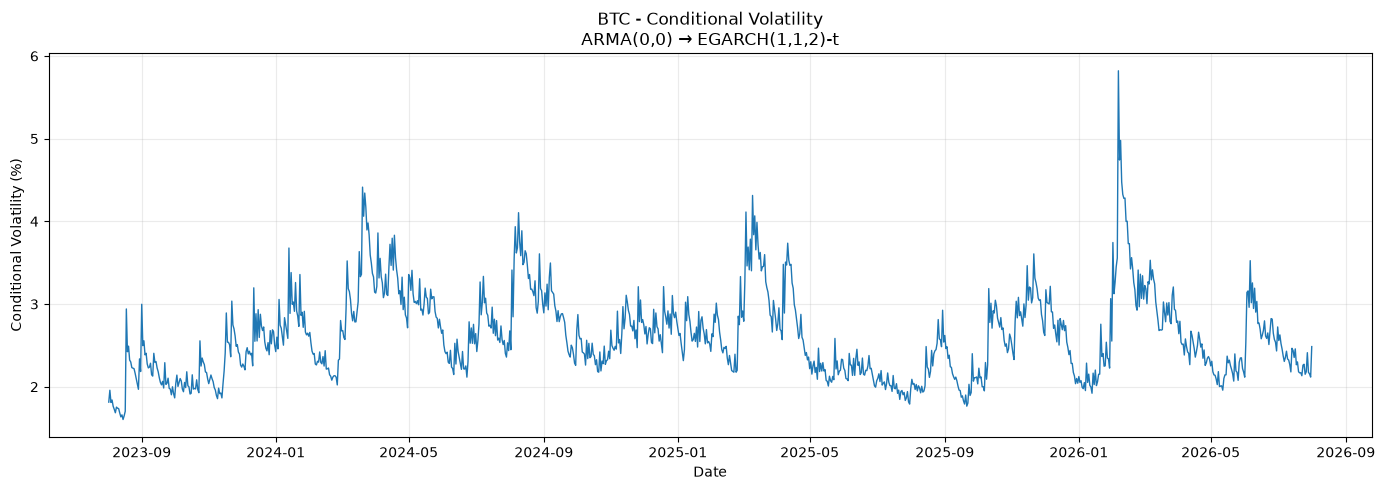

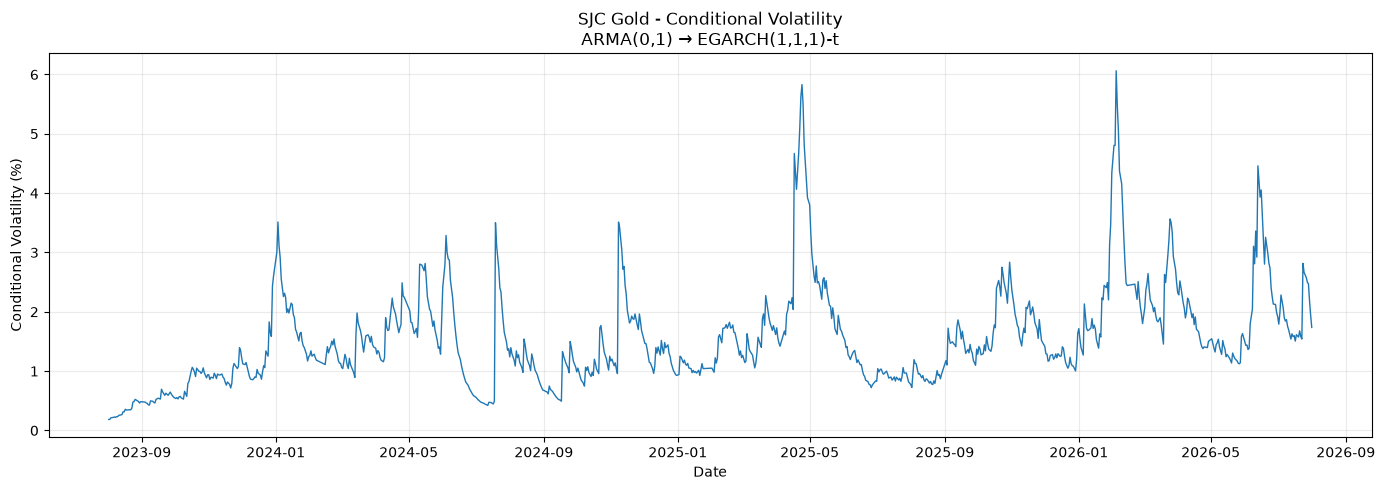

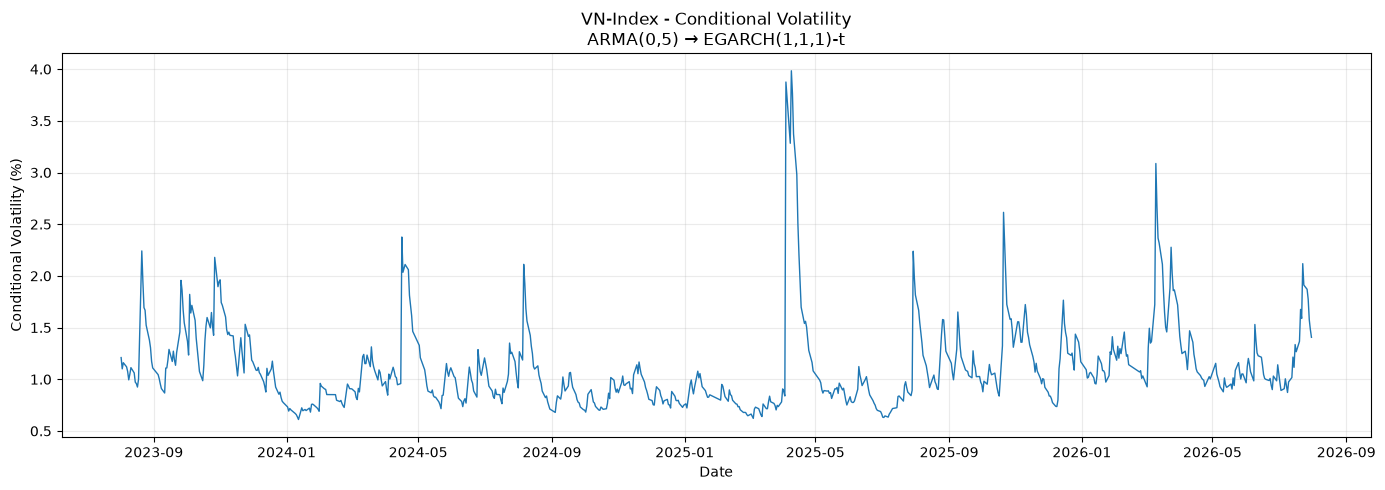

In [45]:
import pandas as pd
import matplotlib.pyplot as plt


# BTC
btc_dates = pd.to_datetime(
    btc.loc[btc_volatility.index, "Date"]
)

# SJC
sjc_dates = pd.to_datetime(
    sjc.loc[sjc_volatility.index, "Date"]
)

# VN-Index
vnindex_dates = pd.to_datetime(
    vnindex.loc[vnindex_volatility.index, "Date"]
)


# =========================================================
# 1. BTC CONDITIONAL VOLATILITY
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    btc_dates,
    btc_volatility.values,
    linewidth=1
)

plt.title(
    "BTC - Conditional Volatility\n"
    "ARMA(0,0) → EGARCH(1,1,2)-t"
)

plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# =========================================================
# 2. SJC CONDITIONAL VOLATILITY
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    sjc_dates,
    sjc_volatility.values,
    linewidth=1
)

plt.title(
    "SJC Gold - Conditional Volatility\n"
    "ARMA(0,1) → EGARCH(1,1,1)-t"
)

plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# =========================================================
# 3. VN-INDEX CONDITIONAL VOLATILITY
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    vnindex_dates,
    vnindex_volatility.values,
    linewidth=1
)

plt.title(
    "VN-Index - Conditional Volatility\n"
    "ARMA(0,5) → EGARCH(1,1,1)-t"
)

plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### So sánh conditional volatility giữa ba tài sản

Đồ thị conditional volatility cho thấy cả Bitcoin, vàng SJC và VN-Index đều tồn tại hiện tượng **volatility clustering**, trong đó các giai đoạn biến động cao có xu hướng tập trung thành từng cụm và kéo dài qua nhiều kỳ.

Mức conditional volatility trung bình lần lượt là:

$$
\bar{\sigma}_{BTC}=2.61\%,
\qquad
\bar{\sigma}_{SJC}=1.54\%,
\qquad
\bar{\sigma}_{VN}=1.11\%
$$

Do đó, Bitcoin có mức volatility trung bình cao nhất trong ba tài sản, trong khi VN-Index có mức thấp nhất.

Tuy nhiên, vàng SJC ghi nhận mức volatility cực đại lớn nhất:

$$
\sigma_{\max,SJC}=6.06\%
$$

so với:

$$
\sigma_{\max,BTC}=5.82\%,
\qquad
\sigma_{\max,VN}=3.98\%
$$

Các đồ thị cũng cho thấy volatility có tính dai dẳng rõ rệt, đặc biệt đối với vàng SJC. Sau các cú sốc lớn, volatility thường giảm dần thay vì trở lại mức bình thường ngay lập tức.

Về tính bất đối xứng, chỉ VN-Index cho thấy bằng chứng thống kê về leverage effect, với hệ số:

$$
\gamma_{VN}=-0.1334,
\qquad
p=0.018<0.05
$$

Điều này cho thấy các cú sốc âm (thông tin tiêu cực) có tác động làm tăng volatility của VN-Index mạnh hơn các cú sốc dương (thông tin tích cực) có cùng độ lớn. Đối với Bitcoin và vàng SJC, hệ số bất đối xứng không có ý nghĩa thống kê.

# MODEL 2 - DCC-GARCH VOLATILITY

1. Đồng bộ thời gian của ba chuỗi
2. Xây dựng ma trận dữ liệu đầu vào cho Model 2
3. Chuẩn hóa residual từ các mô hình ARMA-EGARCH
4. Kiểm tra điều kiện đầu vào cho DCC-GARCH
5. Đặc tả mô hình DCC-GARCH
6. Ước lượng phương trình GARCH đơn biến
7. Ước lượng tham số DCC
8. Tính ma trận tương quan có điều kiện động
9. Trích xuất các cặp tương quan động BTC-SJC, BTC-VN-Index, SJC-VN-Index
10. Kiểm định và chẩn đoán mô hình DCC-GARCH
11. Tính thống kê mô tả của dynamic correlations
12. Xác định các giai đoạn tương quan tăng mạnh, giảm mạnh hoặc đảo chiều
13. Vẽ đồ thị tương quan động theo thời gian

## Đồng bộ chuỗi theo thời gian trùng khớp

In [46]:
# =========================================================
# MODEL 2 - STEP 1: SYNCHRONIZE TIME SERIES BY DATE
# =========================================================

import pandas as pd

# Ensure Date is datetime
btc["Date"] = pd.to_datetime(btc["Date"])
sjc["Date"] = pd.to_datetime(sjc["Date"])
vnindex["Date"] = pd.to_datetime(vnindex["Date"])

# Sort by Date
btc = btc.sort_values("Date").reset_index(drop=True)
sjc = sjc.sort_values("Date").reset_index(drop=True)
vnindex = vnindex.sort_values("Date").reset_index(drop=True)

# Find common dates across all three assets
common_dates = (
    set(btc["Date"])
    & set(sjc["Date"])
    & set(vnindex["Date"])
)

common_dates = sorted(common_dates)

# Synchronize the three dataframes
btc_sync = (
    btc[btc["Date"].isin(common_dates)]
    .sort_values("Date")
    .reset_index(drop=True)
)

sjc_sync = (
    sjc[sjc["Date"].isin(common_dates)]
    .sort_values("Date")
    .reset_index(drop=True)
)

vnindex_sync = (
    vnindex[vnindex["Date"].isin(common_dates)]
    .sort_values("Date")
    .reset_index(drop=True)
)

# =========================================================
# CHECK
# =========================================================

print("Original observations:")
print(f"BTC      : {len(btc)}")
print(f"SJC Gold : {len(sjc)}")
print(f"VN-Index : {len(vnindex)}")

print("\nSynchronized observations:")
print(f"BTC      : {len(btc_sync)}")
print(f"SJC Gold : {len(sjc_sync)}")
print(f"VN-Index : {len(vnindex_sync)}")

print("\nDate range:")
print(f"Start : {common_dates[0]}")
print(f"End   : {common_dates[-1]}")

print("\nDate alignment check:")
print(
    btc_sync["Date"].equals(sjc_sync["Date"])
    and btc_sync["Date"].equals(vnindex_sync["Date"])
)

Original observations:
BTC      : 1097
SJC Gold : 910
VN-Index : 748

Synchronized observations:
BTC      : 748
SJC Gold : 748
VN-Index : 748

Date range:
Start : 2023-08-01 00:00:00
End   : 2026-07-31 00:00:00

Date alignment check:
True


In [47]:
# =========================================================
# CHECK LENGTH AND INDEX OF MODEL 1 OUTPUTS
# =========================================================

print("BTC")
print("DataFrame length       :", len(btc))
print("Std resid length       :", len(btc_std_resid))
print("Volatility length      :", len(btc_volatility))
print("Std resid index range  :", btc_std_resid.index.min(), "->", btc_std_resid.index.max())
print("Volatility index range :", btc_volatility.index.min(), "->", btc_volatility.index.max())

print("\nSJC")
print("DataFrame length       :", len(sjc))
print("Std resid length       :", len(sjc_std_resid))
print("Volatility length      :", len(sjc_volatility))
print("Std resid index range  :", sjc_std_resid.index.min(), "->", sjc_std_resid.index.max())
print("Volatility index range :", sjc_volatility.index.min(), "->", sjc_volatility.index.max())

print("\nVN-INDEX")
print("DataFrame length       :", len(vnindex))
print("Std resid length       :", len(vnindex_std_resid))
print("Volatility length      :", len(vnindex_volatility))
print("Std resid index range  :", vnindex_std_resid.index.min(), "->", vnindex_std_resid.index.max())
print("Volatility index range :", vnindex_volatility.index.min(), "->", vnindex_volatility.index.max())

BTC
DataFrame length       : 1097
Std resid length       : 1096
Volatility length      : 1096
Std resid index range  : 1 -> 1096
Volatility index range : 1 -> 1096

SJC
DataFrame length       : 910
Std resid length       : 909
Volatility length      : 909
Std resid index range  : 1 -> 909
Volatility index range : 1 -> 909

VN-INDEX
DataFrame length       : 748
Std resid length       : 747
Volatility length      : 747
Std resid index range  : 1 -> 747
Volatility index range : 1 -> 747


In [48]:
# =========================================================
# MODEL 2 - STEP 2: BUILD SYNCHRONIZED DCC INPUT DATA
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. ATTACH MODEL 1 OUTPUTS TO THE CORRECT DATES
# ---------------------------------------------------------

btc_model2 = pd.DataFrame({
    "Date": btc.loc[btc_std_resid.index, "Date"].values,
    "btc_std_resid": btc_std_resid.values,
    "btc_volatility": btc_volatility.values
})

sjc_model2 = pd.DataFrame({
    "Date": sjc.loc[sjc_std_resid.index, "Date"].values,
    "sjc_std_resid": sjc_std_resid.values,
    "sjc_volatility": sjc_volatility.values
})

vnindex_model2 = pd.DataFrame({
    "Date": vnindex.loc[vnindex_std_resid.index, "Date"].values,
    "vnindex_std_resid": vnindex_std_resid.values,
    "vnindex_volatility": vnindex_volatility.values
})


# ---------------------------------------------------------
# 2. INNER JOIN BY COMMON DATE
# ---------------------------------------------------------

dcc_data = (
    btc_model2
    .merge(sjc_model2, on="Date", how="inner")
    .merge(vnindex_model2, on="Date", how="inner")
    .sort_values("Date")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 3. REMOVE INVALID VALUES IF ANY
# ---------------------------------------------------------

dcc_data = (
    dcc_data
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 4. STANDARDIZED RESIDUAL MATRIX
#    Main input for DCC estimation
# ---------------------------------------------------------

Z = dcc_data[
    [
        "btc_std_resid",
        "sjc_std_resid",
        "vnindex_std_resid"
    ]
].copy()

Z.columns = ["BTC", "SJC", "VNINDEX"]


# ---------------------------------------------------------
# 5. CONDITIONAL VOLATILITY MATRIX
# ---------------------------------------------------------

conditional_vol = dcc_data[
    [
        "btc_volatility",
        "sjc_volatility",
        "vnindex_volatility"
    ]
].copy()

conditional_vol.columns = ["BTC", "SJC", "VNINDEX"]


# ---------------------------------------------------------
# 6. DATE VECTOR
# ---------------------------------------------------------

dcc_dates = dcc_data["Date"].copy()


# ---------------------------------------------------------
# 7. CHECK
# ---------------------------------------------------------

print("=" * 70)
print("MODEL 2 - DCC INPUT DATA")
print("=" * 70)

print(f"BTC Model 1 observations      : {len(btc_model2)}")
print(f"SJC Model 1 observations      : {len(sjc_model2)}")
print(f"VN-Index Model 1 observations : {len(vnindex_model2)}")

print(f"\nCommon DCC observations       : {len(dcc_data)}")

print("\nDate range:")
print(f"Start : {dcc_dates.iloc[0]}")
print(f"End   : {dcc_dates.iloc[-1]}")

print("\nZ matrix shape:")
print(Z.shape)

print("\nConditional volatility matrix shape:")
print(conditional_vol.shape)

print("\nMissing values:")
print(dcc_data.isna().sum())

print("\nFirst 5 observations:")
display(dcc_data.head())

MODEL 2 - DCC INPUT DATA
BTC Model 1 observations      : 1096
SJC Model 1 observations      : 909
VN-Index Model 1 observations : 747

Common DCC observations       : 747

Date range:
Start : 2023-08-02 00:00:00
End   : 2026-07-31 00:00:00

Z matrix shape:
(747, 3)

Conditional volatility matrix shape:
(747, 3)

Missing values:
Date                  0
btc_std_resid         0
btc_volatility        0
sjc_std_resid         0
sjc_volatility        0
vnindex_std_resid     0
vnindex_volatility    0
dtype: int64

First 5 observations:


,Date,btc_std_resid,btc_volatility,sjc_std_resid,sjc_volatility,vnindex_std_resid,vnindex_volatility
0,2023-08-02,-1.024776,1.813655,0.171997,0.184184,0.155573,1.209943
1,2023-08-03,0.125552,1.957532,-0.641254,0.188737,-0.768792,1.100940
2,2023-08-04,-0.206502,1.809888,-0.141003,0.213994,1.104695,1.160359
3,2023-08-07,0.169878,1.726941,0.010870,0.226253,0.947077,1.120516
4,2023-08-08,1.119061,1.685093,-0.367419,0.219442,-0.077205,1.075406


## Ma trận dữ liệu đầu vào

In [49]:
# =========================================================
# MODEL 2 - STEP 3: CHECK STANDARDIZED RESIDUAL STATISTICS
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. DESCRIPTIVE STATISTICS
# ---------------------------------------------------------

std_resid_stats = pd.DataFrame({
    "Mean": Z.mean(),
    "Std": Z.std(ddof=1),
    "Variance": Z.var(ddof=1),
    "Min": Z.min(),
    "Max": Z.max(),
    "Skewness": Z.skew(),
    "Kurtosis": Z.kurtosis()
})

print("=" * 70)
print("STANDARDIZED RESIDUALS - DESCRIPTIVE STATISTICS")
print("=" * 70)

display(std_resid_stats.round(4))


# ---------------------------------------------------------
# 2. CHECK WHETHER MEAN ≈ 0 AND VARIANCE ≈ 1
# ---------------------------------------------------------

standardization_check = pd.DataFrame({
    "Mean": Z.mean(),
    "|Mean|": Z.mean().abs(),
    "Variance": Z.var(ddof=1),
    "|Variance - 1|": (Z.var(ddof=1) - 1).abs()
})

print("\n" + "=" * 70)
print("STANDARDIZATION CHECK")
print("=" * 70)

display(standardization_check.round(4))


# ---------------------------------------------------------
# 3. UNCONDITIONAL CORRELATION MATRIX
#    Initial correlation structure
# ---------------------------------------------------------

Q_bar = Z.corr()

print("\n" + "=" * 70)
print("UNCONDITIONAL CORRELATION MATRIX (Q_bar)")
print("=" * 70)

display(Q_bar.round(4))


# ---------------------------------------------------------
# 4. UNCONDITIONAL COVARIANCE MATRIX
# ---------------------------------------------------------

S = Z.cov()

print("\n" + "=" * 70)
print("UNCONDITIONAL COVARIANCE MATRIX")
print("=" * 70)

display(S.round(4))


# ---------------------------------------------------------
# 5. MATRIX VALIDITY CHECKS
# ---------------------------------------------------------

Q_bar_np = Q_bar.to_numpy()

eigenvalues = np.linalg.eigvalsh(Q_bar_np)

print("\n" + "=" * 70)
print("MATRIX VALIDITY CHECK")
print("=" * 70)

print("Symmetric matrix:",
      np.allclose(Q_bar_np, Q_bar_np.T))

print("Eigenvalues:",
      np.round(eigenvalues, 6))

print("Positive definite:",
      np.all(eigenvalues > 0))

print("Determinant:",
      round(np.linalg.det(Q_bar_np), 6))

STANDARDIZED RESIDUALS - DESCRIPTIVE STATISTICS


,Mean,Std,Variance,Min,Max,Skewness,Kurtosis
BTC,-0.0133,1.0353,1.0719,-4.4407,4.9865,0.1963,2.1224
SJC,0.0285,0.7028,0.4939,-5.8660,6.9697,0.5895,21.6078
VNINDEX,-0.0105,1.0184,1.0372,-8.3360,3.9646,-1.4242,8.4540



STANDARDIZATION CHECK


,Mean,|Mean|,Variance,|Variance - 1|
BTC,-0.0133,0.0133,1.0719,0.0719
SJC,0.0285,0.0285,0.4939,0.5061
VNINDEX,-0.0105,0.0105,1.0372,0.0372



UNCONDITIONAL CORRELATION MATRIX (Q_bar)


,BTC,SJC,VNINDEX
BTC,1.0000,0.0296,0.0347
SJC,0.0296,1.0000,0.0121
VNINDEX,0.0347,0.0121,1.0000



UNCONDITIONAL COVARIANCE MATRIX


,BTC,SJC,VNINDEX
BTC,1.0719,0.0215,0.0366
SJC,0.0215,0.4939,0.0086
VNINDEX,0.0366,0.0086,1.0372



MATRIX VALIDITY CHECK
Symmetric matrix: True
Eigenvalues: [0.95992  0.988123 1.051957]
Positive definite: True
Determinant: 0.997801


In [50]:
# =========================================================
# MODEL 2/3 - SYNCHRONIZED MULTIVARIATE SAMPLE
# STEP 1: COMMON PRICES -> SYNCHRONIZED RETURNS
# =========================================================

import pandas as pd
import numpy as np


# ---------------------------------------------------------
# 1. PREPARE PRICE SERIES
# ---------------------------------------------------------

btc_price_sync = btc[
    ["Date", "btc_vnd_price"]
].copy()

sjc_price_sync = sjc[
    ["Date", "gold_price"]
].copy()

vnindex_price_sync = vnindex[
    ["Date", "vnindex_price"]
].copy()


# Rename price columns for consistency
btc_price_sync = btc_price_sync.rename(
    columns={"btc_vnd_price": "BTC_price"}
)

sjc_price_sync = sjc_price_sync.rename(
    columns={"gold_price": "SJC_price"}
)

vnindex_price_sync = vnindex_price_sync.rename(
    columns={"vnindex_price": "VNINDEX_price"}
)


# ---------------------------------------------------------
# 2. ENSURE DATE FORMAT
# ---------------------------------------------------------

btc_price_sync["Date"] = pd.to_datetime(btc_price_sync["Date"])
sjc_price_sync["Date"] = pd.to_datetime(sjc_price_sync["Date"])
vnindex_price_sync["Date"] = pd.to_datetime(vnindex_price_sync["Date"])


# ---------------------------------------------------------
# 3. INNER MERGE ON COMMON DATES
# ---------------------------------------------------------

common_prices = (
    btc_price_sync
    .merge(sjc_price_sync, on="Date", how="inner")
    .merge(vnindex_price_sync, on="Date", how="inner")
    .sort_values("Date")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 4. CALCULATE SYNCHRONIZED LOG RETURNS
# ---------------------------------------------------------

common_prices["BTC_return_sync"] = (
    100
    * np.log(
        common_prices["BTC_price"]
        / common_prices["BTC_price"].shift(1)
    )
)

common_prices["SJC_return_sync"] = (
    100
    * np.log(
        common_prices["SJC_price"]
        / common_prices["SJC_price"].shift(1)
    )
)

common_prices["VNINDEX_return_sync"] = (
    100
    * np.log(
        common_prices["VNINDEX_price"]
        / common_prices["VNINDEX_price"].shift(1)
    )
)


# ---------------------------------------------------------
# 5. CREATE SYNCHRONIZED RETURN DATASET
# ---------------------------------------------------------

sync_returns = common_prices[
    [
        "Date",
        "BTC_return_sync",
        "SJC_return_sync",
        "VNINDEX_return_sync"
    ]
].dropna().reset_index(drop=True)


# ---------------------------------------------------------
# 6. ADD LENGTH OF EACH RETURN INTERVAL
#    Useful diagnostic only
# ---------------------------------------------------------

common_prices["interval_days"] = (
    common_prices["Date"]
    .diff()
    .dt.days
)

sync_returns["interval_days"] = (
    common_prices.loc[
        common_prices[
            [
                "BTC_return_sync",
                "SJC_return_sync",
                "VNINDEX_return_sync"
            ]
        ].notna().all(axis=1),
        "interval_days"
    ]
    .to_numpy()
)


# ---------------------------------------------------------
# 7. CHECK
# ---------------------------------------------------------

print("=" * 70)
print("SYNCHRONIZED MULTIVARIATE SAMPLE")
print("=" * 70)

print(f"Common price observations : {len(common_prices)}")
print(f"Synchronized returns      : {len(sync_returns)}")

print("\nDate range - prices:")
print(
    common_prices["Date"].iloc[0],
    "->",
    common_prices["Date"].iloc[-1]
)

print("\nDate range - returns:")
print(
    sync_returns["Date"].iloc[0],
    "->",
    sync_returns["Date"].iloc[-1]
)

print("\nMissing values:")
print(sync_returns.isna().sum())

print("\nReturn interval distribution:")
print(sync_returns["interval_days"].value_counts().sort_index())

print("\nFirst 10 observations:")
display(sync_returns.head(10))

SYNCHRONIZED MULTIVARIATE SAMPLE
Common price observations : 748
Synchronized returns      : 747

Date range - prices:
2023-08-01 00:00:00 -> 2026-07-31 00:00:00

Date range - returns:
2023-08-02 00:00:00 -> 2026-07-31 00:00:00

Missing values:
Date                   0
BTC_return_sync        0
SJC_return_sync        0
VNINDEX_return_sync    0
interval_days          0
dtype: int64

Return interval distribution:
interval_days
1.0     591
2.0       2
3.0     141
4.0       3
5.0       5
6.0       2
8.0       1
10.0      2
Name: count, dtype: int64

First 10 observations:


,Date,BTC_return_sync,SJC_return_sync,VNINDEX_return_sync,interval_days
0,2023-08-02,-1.780751,0.112045,0.235440,1.0
1,2023-08-03,0.323612,-0.037334,-0.779808,1.0
2,2023-08-04,-0.295906,0.037334,1.233535,1.0
3,2023-08-07,0.260271,0.074627,1.251536,3.0
4,2023-08-08,1.963562,0.000000,0.065227,1.0
5,2023-08-09,-0.645561,0.037293,-0.665533,1.0
6,2023-08-10,-0.426127,-0.037293,-1.090209,1.0
7,2023-08-11,-0.087311,0.000000,0.945857,1.0
8,2023-08-14,0.078602,0.260756,0.375043,3.0
9,2023-08-15,-0.539602,0.148699,-0.225830,1.0


### Test tính dừng

In [51]:
# =========================================================
# MODEL 2/3 - SYNCHRONIZED MARGINAL FILTERING
# STEP 2: CHECK SYNCHRONIZED RETURNS
# =========================================================

import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron


sync_series = {
    "BTC": sync_returns["BTC_return_sync"],
    "SJC": sync_returns["SJC_return_sync"],
    "VNINDEX": sync_returns["VNINDEX_return_sync"]
}


# ---------------------------------------------------------
# 1. DESCRIPTIVE STATISTICS
# ---------------------------------------------------------

sync_descriptive = pd.DataFrame({
    name: {
        "N": len(x),
        "Mean": x.mean(),
        "Std": x.std(),
        "Min": x.min(),
        "Max": x.max(),
        "Skewness": x.skew(),
        "Kurtosis": x.kurtosis()
    }
    for name, x in sync_series.items()
}).T

print("=" * 75)
print("SYNCHRONIZED RETURNS - DESCRIPTIVE STATISTICS")
print("=" * 75)

display(sync_descriptive.round(4))


# ---------------------------------------------------------
# 2. STATIONARITY TESTS
# ---------------------------------------------------------

stationarity_results = []

for name, x in sync_series.items():

    x = x.dropna()

    # ADF
    adf_result = adfuller(
        x,
        regression="c",
        autolag="AIC"
    )

    # Phillips-Perron
    pp_result = PhillipsPerron(
        x,
        trend="c"
    )

    # KPSS
    kpss_result = kpss(
        x,
        regression="c",
        nlags="auto"
    )

    stationarity_results.append({
        "Asset": name,

        "ADF Statistic": adf_result[0],
        "ADF p-value": adf_result[1],

        "PP Statistic": pp_result.stat,
        "PP p-value": pp_result.pvalue,

        "KPSS Statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1]
    })


stationarity_sync = pd.DataFrame(stationarity_results)

print("\n" + "=" * 75)
print("STATIONARITY TESTS - SYNCHRONIZED RETURNS")
print("=" * 75)

display(stationarity_sync.round(4))


# ---------------------------------------------------------
# 3. SIMPLE STATIONARITY CONCLUSION
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("STATIONARITY SUMMARY")
print("=" * 75)

for _, row in stationarity_sync.iterrows():

    adf_pass = row["ADF p-value"] < 0.05
    pp_pass = row["PP p-value"] < 0.05
    kpss_pass = row["KPSS p-value"] >= 0.05

    print(f"\n{row['Asset']}:")

    print(
        f"ADF  : {'Stationary' if adf_pass else 'Not stationary'} "
        f"(p={row['ADF p-value']:.4f})"
    )

    print(
        f"PP   : {'Stationary' if pp_pass else 'Not stationary'} "
        f"(p={row['PP p-value']:.4f})"
    )

    print(
        f"KPSS : {'Stationary' if kpss_pass else 'Not stationary'} "
        f"(p={row['KPSS p-value']:.4f})"
    )

SYNCHRONIZED RETURNS - DESCRIPTIVE STATISTICS


,N,Mean,Std,Min,Max,Skewness,Kurtosis
BTC,747.0,0.1143,3.0685,-15.3181,16.0511,0.3527,3.5458
SJC,747.0,0.0988,1.2028,-8.7265,6.7899,-0.8828,11.6978
VNINDEX,747.0,0.0475,1.1911,-6.9102,6.5469,-0.9900,7.0730



STATIONARITY TESTS - SYNCHRONIZED RETURNS


,Asset,ADF Statistic,ADF p-value,PP Statistic,PP p-value,KPSS Statistic,KPSS p-value
0,BTC,-29.2604,0.0,-29.1996,0.0,0.5331,0.0342
1,SJC,-25.9814,0.0,-26.0663,0.0,0.1834,0.1000
2,VNINDEX,-9.8072,0.0,-24.6797,0.0,0.0910,0.1000



STATIONARITY SUMMARY

BTC:
ADF  : Stationary (p=0.0000)
PP   : Stationary (p=0.0000)
KPSS : Not stationary (p=0.0342)

SJC:
ADF  : Stationary (p=0.0000)
PP   : Stationary (p=0.0000)
KPSS : Stationary (p=0.1000)

VNINDEX:
ADF  : Stationary (p=0.0000)
PP   : Stationary (p=0.0000)
KPSS : Stationary (p=0.1000)


In [52]:
from statsmodels.tsa.stattools import kpss

btc_sync = sync_returns["BTC_return_sync"].dropna()

# Level stationarity
kpss_level = kpss(
    btc_sync,
    regression="c",
    nlags="auto"
)

# Trend stationarity
kpss_trend = kpss(
    btc_sync,
    regression="ct",
    nlags="auto"
)

print("=" * 70)
print("BTC SYNCHRONIZED RETURN - KPSS")
print("=" * 70)

print("\nLevel stationarity:")
print(f"Statistic : {kpss_level[0]:.6f}")
print(f"p-value   : {kpss_level[1]:.6f}")
print(f"Lags      : {kpss_level[2]}")

print("\nTrend stationarity:")
print(f"Statistic : {kpss_trend[0]:.6f}")
print(f"p-value   : {kpss_trend[1]:.6f}")
print(f"Lags      : {kpss_trend[2]}")

BTC SYNCHRONIZED RETURN - KPSS

Level stationarity:
Statistic : 0.533074
p-value   : 0.034218
Lags      : 4

Trend stationarity:
Statistic : 0.039184
p-value   : 0.100000
Lags      : 5


### Chọn ARMA(p,q) candidate

In [53]:
# =========================================================
# MODEL 2/3 - SYNCHRONIZED MARGINAL FILTERING
# STEP 3: ARMA(p,q) MODEL SELECTION
# =========================================================

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import warnings
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", UserWarning)


# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

MAX_P = 6
MAX_Q = 6

# Since max(p + q) = 12, use LB lags > 12
LB_LAGS = [15, 20]

ALPHA = 0.05


# ---------------------------------------------------------
# ARMA GRID SEARCH FUNCTION
# ---------------------------------------------------------

def select_arma_sync(series, asset_name,
                     max_p=MAX_P,
                     max_q=MAX_Q,
                     lb_lags=LB_LAGS):

    y = series.dropna().astype(float)

    results = []

    for p in range(max_p + 1):

        for q in range(max_q + 1):

            try:

                # -----------------------------------------
                # Estimate ARMA(p,q)
                # ARIMA(p,0,q) = ARMA(p,q)
                # -----------------------------------------

                model = ARIMA(
                    y,
                    order=(p, 0, q),
                    trend="c",
                    enforce_stationarity=True,
                    enforce_invertibility=True
                )

                fitted = model.fit()

                # -----------------------------------------
                # Check convergence
                # -----------------------------------------

                converged = fitted.mle_retvals.get(
                    "converged",
                    True
                )

                if not converged:
                    continue


                # -----------------------------------------
                # Residual diagnostics: Ljung-Box
                # -----------------------------------------

                resid = fitted.resid.dropna()

                lb = acorr_ljungbox(
                    resid,
                    lags=lb_lags,
                    model_df=p + q,
                    return_df=True
                )

                lb_p15 = lb.loc[15, "lb_pvalue"]
                lb_p20 = lb.loc[20, "lb_pvalue"]

                pass_lb = (
                    (lb_p15 > ALPHA)
                    and
                    (lb_p20 > ALPHA)
                )


                # -----------------------------------------
                # Store result
                # -----------------------------------------

                results.append({
                    "Model": f"ARMA({p},{q})",
                    "p": p,
                    "q": q,

                    "AIC": fitted.aic,
                    "BIC": fitted.bic,

                    "LB_pvalue_15": lb_p15,
                    "LB_pvalue_20": lb_p20,

                    "Pass_LB": pass_lb
                })

            except Exception:
                continue


    # -----------------------------------------------------
    # RESULTS TABLE
    # -----------------------------------------------------

    results_df = pd.DataFrame(results)

    if results_df.empty:
        print(f"No converged ARMA models for {asset_name}")
        return None


    # Sort all converged models by AIC
    results_df = (
        results_df
        .sort_values("AIC")
        .reset_index(drop=True)
    )


    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("\n" + "=" * 90)
    print(
        f"{asset_name} - ALL CONVERGED MODELS RANKED BY AIC"
    )
    print("=" * 90)

    display(
        results_df[
            [
                "Model",
                "AIC",
                "BIC",
                "LB_pvalue_15",
                "LB_pvalue_20",
                "Pass_LB"
            ]
        ].round(4)
    )


    # -----------------------------------------------------
    # MODELS THAT PASS LJUNG-BOX
    # -----------------------------------------------------

    valid = results_df[
        results_df["Pass_LB"]
    ].copy()


    if not valid.empty:

        print("\nTOP 10 VALID MODELS BY AIC")

        display(
            valid
            .sort_values("AIC")
            .head(10)[
                [
                    "Model",
                    "AIC",
                    "BIC",
                    "LB_pvalue_15",
                    "LB_pvalue_20"
                ]
            ]
            .round(4)
        )


        print("\nTOP 10 VALID MODELS BY BIC")

        display(
            valid
            .sort_values("BIC")
            .head(10)[
                [
                    "Model",
                    "AIC",
                    "BIC",
                    "LB_pvalue_15",
                    "LB_pvalue_20"
                ]
            ]
            .round(4)
        )


        # Best candidates
        best_aic = valid.loc[
            valid["AIC"].idxmin()
        ]

        best_bic = valid.loc[
            valid["BIC"].idxmin()
        ]


        print("\nBEST VALID MODEL BY AIC:")
        print(
            best_aic[
                [
                    "Model",
                    "AIC",
                    "BIC",
                    "LB_pvalue_15",
                    "LB_pvalue_20"
                ]
            ]
        )


        print("\nBEST VALID MODEL BY BIC:")
        print(
            best_bic[
                [
                    "Model",
                    "AIC",
                    "BIC",
                    "LB_pvalue_15",
                    "LB_pvalue_20"
                ]
            ]
        )

    else:

        print(
            "\nWARNING: No model passes Ljung-Box "
            "at both lag 15 and 20."
        )


    return results_df


# =========================================================
# RUN FOR THREE SYNCHRONIZED RETURNS
# =========================================================

btc_arma_sync_results = select_arma_sync(
    sync_returns["BTC_return_sync"],
    "BTC"
)

sjc_arma_sync_results = select_arma_sync(
    sync_returns["SJC_return_sync"],
    "SJC"
)

vnindex_arma_sync_results = select_arma_sync(
    sync_returns["VNINDEX_return_sync"],
    "VN-INDEX"
)


BTC - ALL CONVERGED MODELS RANKED BY AIC


,Model,AIC,BIC,LB_pvalue_15,LB_pvalue_20,Pass_LB
0,"ARMA(1,0)",3796.2030,3810.0512,0.2719,0.0805,True
1,"ARMA(0,1)",3796.2331,3810.0813,0.2707,0.0815,True
2,"ARMA(2,2)",3797.1668,3824.8632,0.3612,0.1213,True
3,"ARMA(0,0)",3797.9275,3807.1596,0.1597,0.0501,True
4,"ARMA(3,1)",3797.9572,3825.6536,0.2973,0.0758,True
5,"ARMA(0,2)",3798.1584,3816.6226,0.2139,0.0588,True
6,"ARMA(1,2)",3798.1964,3821.2767,0.2713,0.0845,True
7,"ARMA(1,3)",3798.1981,3825.8945,0.2794,0.0698,True
8,"ARMA(2,0)",3798.2011,3816.6654,0.2129,0.0601,True
9,"ARMA(1,1)",3798.2022,3816.6665,0.2129,0.0599,True



TOP 10 VALID MODELS BY AIC


,Model,AIC,BIC,LB_pvalue_15,LB_pvalue_20
0,"ARMA(1,0)",3796.2030,3810.0512,0.2719,0.0805
1,"ARMA(0,1)",3796.2331,3810.0813,0.2707,0.0815
2,"ARMA(2,2)",3797.1668,3824.8632,0.3612,0.1213
3,"ARMA(0,0)",3797.9275,3807.1596,0.1597,0.0501
4,"ARMA(3,1)",3797.9572,3825.6536,0.2973,0.0758
5,"ARMA(0,2)",3798.1584,3816.6226,0.2139,0.0588
6,"ARMA(1,2)",3798.1964,3821.2767,0.2713,0.0845
7,"ARMA(1,3)",3798.1981,3825.8945,0.2794,0.0698
8,"ARMA(2,0)",3798.2011,3816.6654,0.2129,0.0601
9,"ARMA(1,1)",3798.2022,3816.6665,0.2129,0.0599



TOP 10 VALID MODELS BY BIC


...


TOP 10 VALID MODELS BY AIC


,Model,AIC,BIC,LB_pvalue_15,LB_pvalue_20
0,"ARMA(2,4)",2368.5757,2405.5042,0.3669,0.6895
1,"ARMA(6,4)",2368.8638,2424.2566,0.6915,0.9595
2,"ARMA(6,2)",2368.9990,2415.1596,0.4825,0.7839
3,"ARMA(6,0)",2369.4553,2406.3839,0.2473,0.5680
4,"ARMA(4,2)",2369.5315,2406.4600,0.3275,0.6585
5,"ARMA(2,6)",2369.5602,2415.7209,0.4191,0.7791
6,"ARMA(5,2)",2369.9184,2411.4630,0.3077,0.6536
7,"ARMA(6,3)",2369.9768,2420.7535,0.4308,0.7453
8,"ARMA(6,1)",2370.5318,2412.0764,0.2274,0.5557
9,"ARMA(2,5)",2370.5728,2412.1174,0.2816,0.6174



TOP 10 VALID MODELS BY BIC


,Model,AIC,BIC,LB_pvalue_15,LB_pvalue_20
11,"ARMA(0,5)",2370.6633,2402.9757,0.2186,0.5179
19,"ARMA(5,0)",2372.6925,2405.0050,0.1189,0.3552
0,"ARMA(2,4)",2368.5757,2405.5042,0.3669,0.6895
22,"ARMA(1,4)",2373.8557,2406.1681,0.0828,0.2796
3,"ARMA(6,0)",2369.4553,2406.3839,0.2473,0.5680
4,"ARMA(4,2)",2369.5315,2406.4600,0.3275,0.6585
23,"ARMA(4,1)",2374.9067,2407.2191,0.0532,0.2058
15,"ARMA(0,6)",2372.0728,2409.0013,0.1564,0.4410
16,"ARMA(5,1)",2372.4174,2409.3459,0.1354,0.4012
17,"ARMA(1,5)",2372.4510,2409.3795,0.1578,0.4421



BEST VALID MODEL BY AIC:
Model             ARMA(2,4)
AIC             2368.575718
BIC              2405.50424
LB_pvalue_15       0.366934
LB_pvalue_20       0.689531
Name: 0, dtype: object

BEST VALID MODEL BY BIC:
Model             ARMA(0,5)
AIC             2370.663253
BIC              2402.97571
LB_pvalue_15       0.218553
LB_pvalue_20       0.517913
Name: 11, dtype: object


#### Chốt mô hình trung bình cho DCC-GARCH
Trên mẫu lợi suất đồng bộ gồm 747 quan sát, mô hình trung bình được lựa chọn lần lượt là **ARMA(1,0) cho Bitcoin, ARMA(0,0) cho vàng SJC và ARMA(0,5) cho VN-Index**.

Việc lựa chọn dựa trên sự kết hợp giữa AIC, BIC, kiểm định Ljung-Box và nguyên tắc mô hình gọn.
Cụ thể:
* **BTC**: ARMA(1,0) được chọn cho Bitcoin do có AIC thấp nhất và phần dư đạt yêu cầu không còn tự tương quan tốt hơn ARMA(0,0);
* **SJC**: ARMA(0,0) được chọn cho SJC theo tiêu chí BIC thấp nhất, phần dư không còn tự tương quan;
* **VN-Index**: ARMA(0,5) được chọn cho VN-Index vì có BIC thấp nhất, phần dư không còn tự tương quan (pass kiểm định Ljung-Box).

### ARMA-EGARCH

#### ARMA và kiểm định LJung-Box phần dư

In [54]:
# =========================================================
# MODEL 1 - STEP 4
# FIT FINAL ARMA CONDITIONAL MEAN MODELS
# =========================================================

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


# =========================================================
# 1. FINAL ARMA ORDERS
# =========================================================

btc_arma_order = (1, 0)
sjc_arma_order = (0, 0)
vnindex_arma_order = (0, 5)


# =========================================================
# 2. FUNCTION TO FIT FINAL ARMA MODEL
# =========================================================

def fit_final_arma(series, arma_order, asset_name):

    y = series.dropna().astype(float)

    p, q = arma_order

    # -----------------------------------------------------
    # FIT ARMA(p,q)
    # ARIMA(p,0,q) = ARMA(p,q)
    # -----------------------------------------------------

    model = ARIMA(
        y,
        order=(p, 0, q),
        trend="c",
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    fit = model.fit()


    # -----------------------------------------------------
    # RESIDUALS
    # -----------------------------------------------------

    resid = pd.Series(
        fit.resid,
        index=y.index,
        name=f"{asset_name}_arma_resid"
    )

    resid = (
        resid
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )


    # -----------------------------------------------------
    # LJUNG-BOX DIAGNOSTIC
    # H0: no residual autocorrelation
    # -----------------------------------------------------

    lb = acorr_ljungbox(
        resid,
        lags=[5, 10, 15, 20],
        model_df=p + q,
        return_df=True
    )


    # -----------------------------------------------------
    # OUTPUT
    # -----------------------------------------------------

    print("\n" + "=" * 85)
    print(f"{asset_name} - FINAL ARMA({p},{q})")
    print("=" * 85)

    print("\nMODEL SUMMARY")
    print(fit.summary())

    print("\nINFORMATION CRITERIA")
    print(f"AIC  : {fit.aic:.4f}")
    print(f"BIC  : {fit.bic:.4f}")
    print(f"HQIC : {fit.hqic:.4f}")
    print(f"Log-Likelihood : {fit.llf:.4f}")

    print("\nLJUNG-BOX TEST ON ARMA RESIDUALS")
    display(lb.round(4))

    print("\nResidual observations:", len(resid))

    return {
        "model": model,
        "fit": fit,
        "resid": resid,
        "ljungbox": lb
    }


# =========================================================
# 3. BTC
# =========================================================

btc_arma_result = fit_final_arma(
    sync_returns["BTC_return_sync"],
    btc_arma_order,
    "BTC"
)


# =========================================================
# 4. SJC
# =========================================================

sjc_arma_result = fit_final_arma(
    sync_returns["SJC_return_sync"],
    sjc_arma_order,
    "SJC"
)


# =========================================================
# 5. VN-INDEX
# =========================================================

vnindex_arma_result = fit_final_arma(
    sync_returns["VNINDEX_return_sync"],
    vnindex_arma_order,
    "VN-INDEX"
)


# =========================================================
# 6. SAVE FINAL ARMA MODELS AND RESIDUALS
# =========================================================

btc_arma_final = btc_arma_result["fit"]
sjc_arma_final = sjc_arma_result["fit"]
vnindex_arma_final = vnindex_arma_result["fit"]

btc_arma_resid = btc_arma_result["resid"]
sjc_arma_resid = sjc_arma_result["resid"]
vnindex_arma_resid = vnindex_arma_result["resid"]


BTC - FINAL ARMA(1,0)

MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:        BTC_return_sync   No. Observations:                  747
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1895.102
Date:                Wed, 12 Aug 2026   AIC                           3796.203
Time:                        17:18:41   BIC                           3810.051
Sample:                             0   HQIC                          3801.540
                                - 747                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1147      0.108      1.061      0.289      -0.097       0.326
ar.L1         -0.0705      0.031     -2.301      0.021      -0.131      -0.010
sigma2        

,lb_stat,lb_pvalue
5,3.5904,0.4643
10,10.3292,0.3245
15,16.7113,0.2719
20,28.1538,0.0805



Residual observations: 747

SJC - FINAL ARMA(0,0)

MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:        SJC_return_sync   No. Observations:                  747
Model:                          ARIMA   Log Likelihood               -1197.411
Date:                Wed, 12 Aug 2026   AIC                           2398.822
Time:                        17:18:41   BIC                           2408.054
Sample:                             0   HQIC                          2402.380
                                - 747                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0988      0.045      2.180      0.029       0.010       0.188
sigma2         1.4449      0.030     48.959      0.000       1.38

,lb_stat,lb_pvalue
5,6.0606,0.3004
10,9.3506,0.4992
15,12.7120,0.6245
20,14.3126,0.8143



Residual observations: 747

VN-INDEX - FINAL ARMA(0,5)

MODEL SUMMARY
                                SARIMAX Results                                
Dep. Variable:     VNINDEX_return_sync   No. Observations:                  747
Model:                  ARIMA(0, 0, 5)   Log Likelihood               -1178.332
Date:                 Wed, 12 Aug 2026   AIC                           2370.663
Time:                         17:18:41   BIC                           2402.976
Sample:                              0   HQIC                          2383.116
                                 - 747                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0472      0.054      0.875      0.382      -0.059       0.153
ma.L1          0.1130      0.026      4.389      0.0

,lb_stat,lb_pvalue
5,0.1327,NaN
10,8.7449,0.1197
15,13.0924,0.2186
20,14.1006,0.5179



Residual observations: 747


#### Kiểm định hiệu ứng ARCH của phần dư

In [55]:
# =========================================================
# MODEL 1 - STEP 5
# ARCH-LM TEST ON FINAL ARMA RESIDUALS
# =========================================================

import pandas as pd
from statsmodels.stats.diagnostic import het_arch


# =========================================================
# SETTINGS
# =========================================================

ARCH_LAGS = [5, 10, 15, 20]
ALPHA = 0.05


# =========================================================
# FUNCTION
# =========================================================

def arch_lm_test(resid, asset_name, lags=ARCH_LAGS):

    results = []

    for lag in lags:

        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
            resid.dropna(),
            nlags=lag
        )

        results.append({
            "Asset": asset_name,
            "Lag": lag,
            "LM Statistic": lm_stat,
            "LM p-value": lm_pvalue,
            "F Statistic": f_stat,
            "F p-value": f_pvalue,
            "ARCH Effect": "Yes" if lm_pvalue < ALPHA else "No"
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 85)
    print(f"{asset_name} - ARCH-LM TEST ON ARMA RESIDUALS")
    print("=" * 85)

    display(results_df.round(4))

    if (results_df["LM p-value"] < ALPHA).all():
        print(
            "\nConclusion: Reject H0 at all tested lags."
            "\n→ Significant ARCH effects remain."
            "\n→ Conditional variance modeling is required."
        )
    else:
        print(
            "\nConclusion: ARCH evidence is not significant at all tested lags."
        )

    return results_df


# =========================================================
# RUN FOR THREE ASSETS
# =========================================================

btc_arch_lm = arch_lm_test(
    btc_arma_resid,
    "BTC"
)

sjc_arch_lm = arch_lm_test(
    sjc_arma_resid,
    "SJC"
)

vnindex_arch_lm = arch_lm_test(
    vnindex_arma_resid,
    "VN-INDEX"
)


# =========================================================
# COMBINED SUMMARY
# =========================================================

arma_arch_diagnostics = pd.concat(
    [
        btc_arch_lm,
        sjc_arch_lm,
        vnindex_arch_lm
    ],
    ignore_index=True
)

print("\n" + "=" * 85)
print("ARCH-LM SUMMARY - ALL ASSETS")
print("=" * 85)

display(arma_arch_diagnostics.round(4))


BTC - ARCH-LM TEST ON ARMA RESIDUALS


,Asset,Lag,LM Statistic,LM p-value,F Statistic,F p-value,ARCH Effect
0,BTC,5,19.4354,0.0016,3.9594,0.0015,Yes
1,BTC,10,26.3112,0.0033,2.6878,0.0031,Yes
2,BTC,15,32.3666,0.0057,2.2083,0.0052,Yes
3,BTC,20,34.2334,0.0246,1.7444,0.0230,Yes



Conclusion: Reject H0 at all tested lags.
→ Significant ARCH effects remain.
→ Conditional variance modeling is required.

SJC - ARCH-LM TEST ON ARMA RESIDUALS


,Asset,Lag,LM Statistic,LM p-value,F Statistic,F p-value,ARCH Effect
0,SJC,5,93.1830,0.0,21.1408,0.0,Yes
1,SJC,10,96.3352,0.0,10.9167,0.0,Yes
2,SJC,15,102.9899,0.0,7.8155,0.0,Yes
3,SJC,20,103.7160,0.0,5.8740,0.0,Yes



Conclusion: Reject H0 at all tested lags.
→ Significant ARCH effects remain.
→ Conditional variance modeling is required.

VN-INDEX - ARCH-LM TEST ON ARMA RESIDUALS


,Asset,Lag,LM Statistic,LM p-value,F Statistic,F p-value,ARCH Effect
0,VN-INDEX,5,89.5712,0.0,20.2089,0.0,Yes
1,VN-INDEX,10,96.8228,0.0,10.9803,0.0,Yes
2,VN-INDEX,15,105.5790,0.0,8.0451,0.0,Yes
3,VN-INDEX,20,107.2156,0.0,6.1065,0.0,Yes



Conclusion: Reject H0 at all tested lags.
→ Significant ARCH effects remain.
→ Conditional variance modeling is required.

ARCH-LM SUMMARY - ALL ASSETS


,Asset,Lag,LM Statistic,LM p-value,F Statistic,F p-value,ARCH Effect
0,BTC,5,19.4354,0.0016,3.9594,0.0015,Yes
1,BTC,10,26.3112,0.0033,2.6878,0.0031,Yes
2,BTC,15,32.3666,0.0057,2.2083,0.0052,Yes
3,BTC,20,34.2334,0.0246,1.7444,0.0230,Yes
4,SJC,5,93.1830,0.0000,21.1408,0.0000,Yes
5,SJC,10,96.3352,0.0000,10.9167,0.0000,Yes
6,SJC,15,102.9899,0.0000,7.8155,0.0000,Yes
7,SJC,20,103.7160,0.0000,5.8740,0.0000,Yes
8,VN-INDEX,5,89.5712,0.0000,20.2089,0.0000,Yes
9,VN-INDEX,10,96.8228,0.0000,10.9803,0.0000,Yes


#### Tóm tắt mô hình ARMA và kiểm định độ phù hợp

**Bitcoin: ARMA(1,0)**  
- AIC = 3796.2030; BIC = 3810.0512.  
- Hệ số $AR(1)=-0.0705$, có ý nghĩa thống kê với $p=0.021$.

**SJC: ARMA(0,0)**  
- AIC = 2398.8219; BIC = 2408.0540.  
- Hệ số trung bình $\mu=0.0988$, có ý nghĩa thống kê với $p=0.029$.

**VN-Index: ARMA(0,5)**  
- AIC = 2370.6633; BIC = 2402.9757.  
- Các hệ số MA(1), MA(4) và MA(5) có ý nghĩa thống kê.

---

#### Kiểm định Ljung-Box

Giả thuyết:

$H_0$: Phần dư không có tự tương quan.

- **BTC:** $p_5=0.4643$, $p_{10}=0.3245$, $p_{15}=0.2719$, $p_{20}=0.0805$.
- **SJC:** $p_5=0.3004$, $p_{10}=0.4992$, $p_{15}=0.6245$, $p_{20}=0.8143$.
- **VN-Index:** $p_{10}=0.1197$, $p_{15}=0.2186$, $p_{20}=0.5179$.

Tất cả các p-value hợp lệ đều lớn hơn 0.05, do đó **không bác bỏ $H_0$**. Phần dư của các mô hình ARMA không còn tự tương quan đáng kể. Các phương trình trung bình được xem là phù hợp.

---

#### Kiểm định ARCH-LM

Giả thuyết:

$H_0$: Không tồn tại hiệu ứng ARCH trong phần dư.

- **BTC:** $p_5=0.0016$, $p_{10}=0.0033$, $p_{15}=0.0057$, $p_{20}=0.0246$.
- **SJC:** $p<0.001$ tại tất cả các lag 5, 10, 15 và 20.
- **VN-Index:** $p<0.001$ tại tất cả các lag 5, 10, 15 và 20.

Các p-value đều nhỏ hơn 0.05, do đó **bác bỏ $H_0$** đối với cả ba tài sản. Phần dư ARMA vẫn tồn tại hiệu ứng ARCH và phương sai có điều kiện thay đổi theo thời gian.

#### Kết luận

Các mô hình **ARMA(1,0) cho Bitcoin, ARMA(0,0) cho SJC và ARMA(0,5) cho VN-Index** đã xử lý phù hợp cấu trúc tự tương quan trong phương trình trung bình. Tuy nhiên, kiểm định ARCH–LM cho thấy phần dư của cả ba mô hình vẫn tồn tại hiệu ứng ARCH đáng kể. Vì vậy, cần tiếp tục mô hình hóa phương sai có điều kiện bằng **EGARCH**.

**Bitcoin: ARMA(1,0)**

$$
BTC\_return\_sync_t = 0.1147 - 0.0705BTC\_return\_sync_{t-1} + \varepsilon_t
$$

**SJC: ARMA(0,0)**

$$
SJC\_return\_sync_t = 0.0988 + \varepsilon_t
$$

**VN-Index: ARMA(0,5)**

$$
VNINDEX\_return\_sync_t =
0.0472
+ 0.1130\varepsilon_{t-1}
- 0.0206\varepsilon_{t-2}
- 0.0424\varepsilon_{t-3}
- 0.0900\varepsilon_{t-4}
+ 0.1002\varepsilon_{t-5}
+ \varepsilon_t
$$

### Diagnostics của mô hình

In [56]:
# =========================================================
# MODEL 1 - ARMA-EGARCH DIAGNOSTICS
# STEP 5: STANDARDIZED RESIDUAL DIAGNOSTICS
# =========================================================

import numpy as np
import pandas as pd

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)


# =========================================================
# SETTINGS
# =========================================================

LB_LAGS = [5, 10, 15, 20]
ARCH_LAGS = [5, 10, 15, 20]
ALPHA = 0.05


# =========================================================
# DIAGNOSTIC FUNCTION
# =========================================================

def egarch_diagnostics(std_resid, asset_name):

    z = (
        pd.Series(std_resid)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    z2 = z ** 2

    # -----------------------------------------------------
    # 1. STANDARDIZATION CHECK
    # -----------------------------------------------------

    standardization = pd.DataFrame({
        "Mean": [z.mean()],
        "Std": [z.std(ddof=1)],
        "Variance": [z.var(ddof=1)],
        "Skewness": [z.skew()],
        "Kurtosis": [z.kurtosis()]
    }, index=[asset_name])


    # -----------------------------------------------------
    # 2. LJUNG-BOX ON STANDARDIZED RESIDUALS
    #    H0: no serial correlation in z_t
    # -----------------------------------------------------

    lb_z = acorr_ljungbox(
        z,
        lags=LB_LAGS,
        return_df=True
    )

    lb_z = lb_z.rename(columns={
        "lb_stat": "LB_stat_z",
        "lb_pvalue": "LB_pvalue_z"
    })


    # -----------------------------------------------------
    # 3. LJUNG-BOX ON SQUARED STANDARDIZED RESIDUALS
    #    H0: no serial correlation in z_t^2
    # -----------------------------------------------------

    lb_z2 = acorr_ljungbox(
        z2,
        lags=LB_LAGS,
        return_df=True
    )

    lb_z2 = lb_z2.rename(columns={
        "lb_stat": "LB_stat_z2",
        "lb_pvalue": "LB_pvalue_z2"
    })


    # -----------------------------------------------------
    # 4. ARCH-LM TEST
    #    H0: no remaining ARCH effect
    # -----------------------------------------------------

    arch_results = []

    for lag in ARCH_LAGS:

        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
            z,
            nlags=lag
        )

        arch_results.append({
            "Lag": lag,
            "LM Statistic": lm_stat,
            "LM p-value": lm_pvalue,
            "F Statistic": f_stat,
            "F p-value": f_pvalue,
            "Pass_ARCH_LM": lm_pvalue > ALPHA
        })

    arch_results = pd.DataFrame(arch_results)


    # -----------------------------------------------------
    # 5. COMBINE LJUNG-BOX TABLE
    # -----------------------------------------------------

    lb_results = pd.concat(
        [lb_z, lb_z2],
        axis=1
    )

    lb_results["Pass_LB_z"] = (
        lb_results["LB_pvalue_z"] > ALPHA
    )

    lb_results["Pass_LB_z2"] = (
        lb_results["LB_pvalue_z2"] > ALPHA
    )


    # -----------------------------------------------------
    # OUTPUT
    # -----------------------------------------------------

    print("\n" + "=" * 85)
    print(f"{asset_name} - ARMA-EGARCH DIAGNOSTICS")
    print("=" * 85)

    print("\n1. STANDARDIZED RESIDUAL SUMMARY")
    display(standardization.round(4))

    print("\n2. LJUNG-BOX TESTS")
    display(lb_results.round(4))

    print("\n3. ARCH-LM TEST")
    display(arch_results.round(4))


    # -----------------------------------------------------
    # SIMPLE CONCLUSION
    # -----------------------------------------------------

    pass_mean = abs(z.mean()) < 0.10

    pass_lb_z = (
        lb_results["LB_pvalue_z"] > ALPHA
    ).all()

    pass_lb_z2 = (
        lb_results["LB_pvalue_z2"] > ALPHA
    ).all()

    pass_arch = (
        arch_results["LM p-value"] > ALPHA
    ).all()

    print("\n4. SUMMARY")

    print(
        "Mean approximately zero :",
        pass_mean
    )

    print(
        "No residual autocorrelation :",
        pass_lb_z
    )

    print(
        "No autocorrelation in squared residuals :",
        pass_lb_z2
    )

    print(
        "No remaining ARCH effect :",
        pass_arch
    )

    print(
        "\nOverall diagnostic status :",
        "PASS"
        if (pass_lb_z and pass_lb_z2 and pass_arch)
        else "REVIEW"
    )

    return {
        "standardization": standardization,
        "ljungbox": lb_results,
        "arch_lm": arch_results
    }


# =========================================================
# RUN DIAGNOSTICS
# =========================================================

btc_egarch_diagnostics = egarch_diagnostics(
    btc_std_resid_sync,
    "BTC"
)

sjc_egarch_diagnostics = egarch_diagnostics(
    sjc_std_resid_sync,
    "SJC"
)

vnindex_egarch_diagnostics = egarch_diagnostics(
    vnindex_std_resid_sync,
    "VN-INDEX"
)

NameError: name 'btc_std_resid_sync' is not defined

## Kết luận về mô hình ARMA-GARCH

Về phương trình trung bình có điều kiện (Conditional Mean Equation):
Giá trị trung bình của chuỗi phần dư chuẩn hóa ở cả ba chuỗi dữ liệu đều xấp xỉ 0 ($\mu_{BTC} = -0.0017$; $\mu_{SJC} = 0.0044$; $\mu_{VN\text{-}INDEX} = -0.0105$), thỏa mãn giả định cơ bản của mô hình chuỗi thời gian.

Kết quả kiểm định Ljung-Box trên phần dư chuẩn hóa $Q(z)$ tại tất cả các độ trễ (từ bậc 5 đến bậc 20) đều có giá trị $p\text{-value} > 0.05$. Do đó, không có đủ bằng chứng thực nghiệm để bác bỏ giả thuyết vô hiệu ($H_0$) về việc không tồn tại hiện tượng tự tương quan chuỗi bậc nhất và bậc cao.

Điều này xác nhận thành phần ARMA đã mô hình hóa và bóc tách đầy đủ các động lượng tuyến tính trong chuỗi tỷ suất sinh lợi.

--------
Về phương trình phương sai có điều kiện (Conditional Variance Equation):

**Kiểm định tương quan phần dư bình phương:** Thống kê Ljung-Box trên chuỗi phần dư chuẩn hóa bình phương $Q(z^2)$ đều cho $p\text{-value}$ vượt trội so với mức ý nghĩa 5% ở mọi độ trễ khảo sát (đặc biệt tại độ trễ 20: $p = 0.8494$ đối với BTC; $p = 0.9984$ đối với SJC; và $p = 1.0000$ đối với VN-INDEX).

**Kiểm định hiệu ứng ARCH còn lại:** Kết quả kiểm định nhân tử Lagrange (ARCH-LM Test) của Engle (1982) tại các bậc trễ 5, 10, 15 và 20 đều đồng thuận không bác bỏ giả thuyết $H_0$ ($p\text{-value} \gg 0.05$).

Cả hai kiểm định trên đồng nhất chứng minh rằng không còn tồn tại hiện tượng phương sai thay đổi có điều kiện hay hiện tượng phân cụm biến động (volatility clustering) trong phần dư. Cấu trúc mô hình EGARCH đã nắm bắt trọn vẹn đặc tính biến động phi tuyến tính và hiệu ứng bất đối xứng của các chuỗi tài sản.

**Đặc tính phân phối của phần dư:** Hệ số độ nhọn (Kurtosis) của phần dư chuẩn hóa ở cả ba thị trường đều lớn hơn 3 ($\text{Kurtosis}_{BTC} = 3.8823$; $\text{Kurtosis}_{SJC} = 14.5373$; $\text{Kurtosis}_{VN\text{-}INDEX} = 8.4540$), phản ánh rõ nét đặc tính phân phối đuôi dày (fat-tailed/leptokurtic) thường thấy trong dữ liệu tài chính. Điều này tái khẳng định tính đúng đắn khi thiết lập mô hình biến động điều kiện dựa trên các phân phối phi chuẩn (như Student-$t$).

-----------

## Kết luận chung

Tất cả các tiêu chí chẩn đoán thống kê đều thỏa mãn ở mức ý nghĩa 5% (Overall diagnostic status: PASS). Các mô hình ARMA-EGARCH được chỉ định cho BTC, SJC và VN-INDEX là hoàn toàn phù hợp, không bị vi phạm các khuyết tật mô hình (tự tương quan và heteroskedasticity), đủ độ tin cậy học thuật và giá trị thực tiễn để phục vụ các phân tích tiếp theo như dự báo rủi ro biến động, tính toán Giá trị chịu rủi ro (VaR) và phân tích lan truyền biến động liên thị trường.

## Xử lý residuals trước DCC

Vì variance của SJC chỉ 0.503, trước khi bắt đầu DCC, kiểm tra xem variance 0.503 có phải là một lỗi không:
1. xác nhận std_resid do chính arch trả về có giống với arma_resid / conditional_volatility;
2. kiểm tra conditional volatility của SJC có bị scale quá lớn hay không;
3. kiểm tra đặc biệt Student-t với $(nu=2.2949$), vì đây là phân phối đuôi dày;
4. so EGARCH(1,1,1)-t với một vài specification EGARCH khác để xem variance standardized residual có tiến gần 1 mà diagnostics vẫn tốt hay không.

### Check lỗi tạo standardized residual

In [ ]:
# Bước 1:
# =========================================================
# SJC CHECK 1
# VERIFY STANDARDIZED RESIDUAL CONSTRUCTION
# =========================================================

import numpy as np
import pandas as pd

# Residual from final ARMA
sjc_eps = sjc_arma_resid.copy()

# Conditional volatility from EGARCH
sjc_sigma = sjc_volatility_sync.copy()

# Our manually constructed standardized residual
sjc_z_manual = sjc_eps / sjc_sigma

# Standardized residual saved previously
sjc_z_saved = sjc_std_resid_sync.copy()

# Align indices
check_df = pd.concat(
    [
        sjc_eps.rename("epsilon"),
        sjc_sigma.rename("sigma"),
        sjc_z_manual.rename("z_manual"),
        sjc_z_saved.rename("z_saved")
    ],
    axis=1
).dropna()

check_df["difference"] = (
    check_df["z_manual"] - check_df["z_saved"]
)

print("=" * 75)
print("SJC - STANDARDIZED RESIDUAL CONSTRUCTION CHECK")
print("=" * 75)

print("Observations:", len(check_df))

print("\nMaximum absolute difference:")
print(check_df["difference"].abs().max())

print("\nMean absolute difference:")
print(check_df["difference"].abs().mean())

print("\nVariance:")
print("z_manual :", check_df["z_manual"].var(ddof=1))
print("z_saved  :", check_df["z_saved"].var(ddof=1))

print("\nFirst observations:")
display(check_df.head())

SJC - STANDARDIZED RESIDUAL CONSTRUCTION CHECK
Observations: 747

Maximum absolute difference:
0.0

Mean absolute difference:
0.0

Variance:
z_manual : 0.5030455648116261
z_saved  : 0.5030455648116261

First observations:


,epsilon,sigma,z_manual,z_saved,difference
0,0.013291,0.210944,0.063007,0.063007,0.0
1,-0.136088,0.211428,-0.643664,-0.643664,0.0
2,-0.061420,0.228317,-0.269010,-0.269010,0.0
3,-0.024127,0.233111,-0.103500,-0.103500,0.0
4,-0.098754,0.232300,-0.425114,-0.425114,0.0


đúng, loại trừ lỗi tạo standardized residual.

### Check scale của residual và conditional volatility SJC

In [ ]:
# Bước 2
# =========================================================
# SJC CHECK 2
# RESIDUAL VS CONDITIONAL VOLATILITY SCALE
# =========================================================

sjc_scale_check = pd.DataFrame({
    "ARMA residual": sjc_eps,
    "Conditional volatility": sjc_sigma,
    "Standardized residual": sjc_z_saved
}).dropna()

scale_stats = sjc_scale_check.agg([
    "mean",
    "std",
    "min",
    "median",
    "max"
]).T

print("=" * 75)
print("SJC - SCALE CHECK")
print("=" * 75)

display(scale_stats.round(6))

print("\nResidual variance:")
print(sjc_eps.var(ddof=1))

print("\nMean conditional variance E[sigma_t^2]:")
print((sjc_sigma ** 2).mean())

print("\nRatio:")
print(
    sjc_eps.var(ddof=1)
    /
    (sjc_sigma ** 2).mean()
)

print("\nMean squared standardized residual:")
print((sjc_z_saved ** 2).mean())

SJC - SCALE CHECK


,mean,std,min,median,max
ARMA residual,0.000005,1.202847,-8.825218,-0.098754,6.691184
Conditional volatility,1.584697,0.796759,0.210944,1.431279,5.907933
Standardized residual,0.004412,0.709257,-5.103480,-0.053138,5.837962



Residual variance:
1.4468402586859455

Mean conditional variance E[sigma_t^2]:
3.145237550169235

Ratio:
0.46000985159550056

Mean squared standardized residual:
0.5023916077100656


Standardized residuals có độ lớn khoảng 0.50, xác nhận EGARCH đang tạo conditional variance lớn tương đối so với realized residuals.

### Kiểm tra distribution

In [ ]:
# Bước 3:
# =========================================================
# SJC CHECK 3
# STUDENT-T SHAPE PARAMETER
# =========================================================

nu_sjc = sjc_egarch_sync_final.params["nu"]

print("=" * 75)
print("SJC - STUDENT-T DISTRIBUTION CHECK")
print("=" * 75)

print(f"Estimated nu = {nu_sjc:.6f}")

if nu_sjc > 2:
    theoretical_variance_raw_t = nu_sjc / (nu_sjc - 2)

    print(
        "Variance of an unstandardized Student-t with same nu:",
        round(theoretical_variance_raw_t, 4)
    )

    print(
        "\nNote: arch uses a standardized Student-t distribution,"
        "\nso model innovations are parameterized to have unit variance."
    )
else:
    print("nu <= 2: theoretical variance is not finite.")

SJC - STUDENT-T DISTRIBUTION CHECK
Estimated nu = 2.294917
Variance of an unstandardized Student-t with same nu: 7.7816

Note: arch uses a standardized Student-t distribution,
so model innovations are parameterized to have unit variance.


### So sánh các specification EGARCH khác cho riêng SJC

In [ ]:
# Bước 4, chạy lại candidates:
# =========================================================
# SJC CHECK 4
# COMPARE EGARCH SPECIFICATIONS
# =========================================================

from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

sjc_resid = sjc_arma_resid.dropna()

candidates = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2)
]

results = []

sjc_egarch_candidates = {}

for p, o, q in candidates:

    try:

        model = arch_model(
            sjc_resid,
            mean="Zero",
            vol="EGARCH",
            p=p,
            o=o,
            q=q,
            dist="StudentsT",
            rescale=False
        )

        fit = model.fit(
            disp="off",
            update_freq=0
        )

        sigma = fit.conditional_volatility

        z = (
            sjc_resid / sigma
        ).dropna()

        # Ljung-Box z
        lb_z = acorr_ljungbox(
            z,
            lags=[10, 15, 20],
            return_df=True
        )

        # Ljung-Box z^2
        lb_z2 = acorr_ljungbox(
            z ** 2,
            lags=[10, 15, 20],
            return_df=True
        )

        # ARCH-LM lag 10,15,20
        arch_pvals = []

        for lag in [10, 15, 20]:

            lm_stat, lm_pvalue, _, _ = het_arch(
                z,
                nlags=lag
            )

            arch_pvals.append(lm_pvalue)

        pass_lb_z = (
            lb_z["lb_pvalue"] > 0.05
        ).all()

        pass_lb_z2 = (
            lb_z2["lb_pvalue"] > 0.05
        ).all()

        pass_arch = all(
            pval > 0.05
            for pval in arch_pvals
        )

        results.append({
            "Model": f"EGARCH({p},{o},{q})-t",

            "AIC": fit.aic,
            "BIC": fit.bic,

            "z_mean": z.mean(),
            "z_std": z.std(ddof=1),
            "z_variance": z.var(ddof=1),

            "LB_z_p10": lb_z.loc[10, "lb_pvalue"],
            "LB_z_p15": lb_z.loc[15, "lb_pvalue"],
            "LB_z_p20": lb_z.loc[20, "lb_pvalue"],

            "LB_z2_p10": lb_z2.loc[10, "lb_pvalue"],
            "LB_z2_p15": lb_z2.loc[15, "lb_pvalue"],
            "LB_z2_p20": lb_z2.loc[20, "lb_pvalue"],

            "ARCH_p10": arch_pvals[0],
            "ARCH_p15": arch_pvals[1],
            "ARCH_p20": arch_pvals[2],

            "Pass_LB_z": pass_lb_z,
            "Pass_LB_z2": pass_lb_z2,
            "Pass_ARCH": pass_arch,

            "Pass_All": (
                pass_lb_z
                and pass_lb_z2
                and pass_arch
            )
        })

        sjc_egarch_candidates[
            f"EGARCH({p},{o},{q})"
        ] = fit

    except Exception as e:

        print(
            f"EGARCH({p},{o},{q}) failed:",
            e
        )


sjc_egarch_comparison = pd.DataFrame(results)

sjc_egarch_comparison = (
    sjc_egarch_comparison
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 100)
print("SJC - EGARCH CANDIDATE COMPARISON")
print("=" * 100)

display(
    sjc_egarch_comparison.round(4)
)

SJC - EGARCH CANDIDATE COMPARISON


,Model,AIC,BIC,z_mean,z_std,z_variance,LB_z_p10,LB_z_p15,LB_z_p20,LB_z2_p10,LB_z2_p15,LB_z2_p20,ARCH_p10,ARCH_p15,ARCH_p20,Pass_LB_z,Pass_LB_z2,Pass_ARCH,Pass_All
0,"EGARCH(1,1,1)-t",1802.1889,1825.2692,0.0044,0.7093,0.5030,0.3026,0.6707,0.8538,0.9914,0.9868,0.9984,0.9927,0.9863,0.9982,True,True,True,True
1,"EGARCH(2,1,2)-t",1802.3516,1834.6641,0.0082,0.7066,0.4993,0.3459,0.7173,0.8581,0.9986,0.9985,0.9998,0.9987,0.9982,0.9997,True,True,True,True
2,"EGARCH(1,1,2)-t",1803.3810,1831.0774,0.0031,0.7147,0.5107,0.3857,0.7349,0.9056,0.4577,0.6723,0.8798,0.5125,0.7340,0.9132,True,True,True,True
3,"EGARCH(2,1,1)-t",1803.9834,1831.6798,0.0041,0.7211,0.5200,0.2972,0.6655,0.8492,0.9862,0.9798,0.9973,0.9884,0.9801,0.9971,True,True,True,True


Không có khác biệt đáng kể ở các bậc EGARCH

### So sánh giữa các distributions

In [ ]:
# =========================================================
# SJC CHECK 5
# COMPARE INNOVATION DISTRIBUTIONS
# EGARCH(1,1,1)
# =========================================================

import numpy as np
import pandas as pd

from arch import arch_model
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)


sjc_resid = sjc_arma_resid.dropna()

distributions = {
    "Normal": "normal",
    "Student-t": "StudentsT",
    "GED": "ged",
    "Skew-t": "skewt"
}

results = []
sjc_distribution_models = {}


for dist_name, dist_code in distributions.items():

    try:

        model = arch_model(
            sjc_resid,
            mean="Zero",
            vol="EGARCH",
            p=1,
            o=1,
            q=1,
            dist=dist_code,
            rescale=False
        )

        fit = model.fit(
            disp="off",
            update_freq=0
        )

        sigma = fit.conditional_volatility

        z = (
            sjc_resid / sigma
        ).dropna()


        # ---------------------------------------------
        # Ljung-Box z
        # ---------------------------------------------

        lb_z = acorr_ljungbox(
            z,
            lags=[10, 15, 20],
            return_df=True
        )


        # ---------------------------------------------
        # Ljung-Box z^2
        # ---------------------------------------------

        lb_z2 = acorr_ljungbox(
            z ** 2,
            lags=[10, 15, 20],
            return_df=True
        )


        # ---------------------------------------------
        # ARCH-LM
        # ---------------------------------------------

        arch_pvals = []

        for lag in [10, 15, 20]:

            _, lm_pvalue, _, _ = het_arch(
                z,
                nlags=lag
            )

            arch_pvals.append(lm_pvalue)


        pass_lb_z = (
            lb_z["lb_pvalue"] > 0.05
        ).all()

        pass_lb_z2 = (
            lb_z2["lb_pvalue"] > 0.05
        ).all()

        pass_arch = all(
            p > 0.05
            for p in arch_pvals
        )


        # ---------------------------------------------
        # Distribution parameters
        # ---------------------------------------------

        nu = (
            fit.params["nu"]
            if "nu" in fit.params.index
            else np.nan
        )

        eta = (
            fit.params["eta"]
            if "eta" in fit.params.index
            else np.nan
        )

        lam = (
            fit.params["lambda"]
            if "lambda" in fit.params.index
            else np.nan
        )


        results.append({

            "Distribution": dist_name,

            "AIC": fit.aic,
            "BIC": fit.bic,
            "LogLik": fit.loglikelihood,

            "z_mean": z.mean(),
            "z_std": z.std(ddof=1),
            "z_variance": z.var(ddof=1),
            "mean_z2": (z ** 2).mean(),

            "nu": nu,
            "eta": eta,
            "lambda": lam,

            "LB_z_p10": lb_z.loc[10, "lb_pvalue"],
            "LB_z_p15": lb_z.loc[15, "lb_pvalue"],
            "LB_z_p20": lb_z.loc[20, "lb_pvalue"],

            "LB_z2_p10": lb_z2.loc[10, "lb_pvalue"],
            "LB_z2_p15": lb_z2.loc[15, "lb_pvalue"],
            "LB_z2_p20": lb_z2.loc[20, "lb_pvalue"],

            "ARCH_p10": arch_pvals[0],
            "ARCH_p15": arch_pvals[1],
            "ARCH_p20": arch_pvals[2],

            "Pass_All": (
                pass_lb_z
                and pass_lb_z2
                and pass_arch
            )
        })

        sjc_distribution_models[
            dist_name
        ] = fit


    except Exception as e:

        print(
            f"{dist_name} failed:",
            e
        )


sjc_distribution_comparison = (
    pd.DataFrame(results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("=" * 110)
print("SJC - EGARCH(1,1,1) DISTRIBUTION COMPARISON")
print("=" * 110)

display(
    sjc_distribution_comparison.round(4)
)

SJC - EGARCH(1,1,1) DISTRIBUTION COMPARISON


,Distribution,AIC,BIC,LogLik,z_mean,z_std,z_variance,mean_z2,nu,eta,...,LB_z_p10,LB_z_p15,LB_z_p20,LB_z2_p10,LB_z2_p15,LB_z2_p20,ARCH_p10,ARCH_p15,ARCH_p20,Pass_All
0,Skew-t,1800.5506,1828.2470,-894.2753,0.0049,0.6968,0.4855,0.4849,NaN,2.2775,...,0.3118,0.6826,0.8570,0.9952,0.9894,0.9988,0.9959,0.9887,0.9985,True
1,Student-t,1802.1889,1825.2692,-896.0944,0.0044,0.7093,0.5030,0.5024,2.2949,NaN,...,0.3026,0.6707,0.8538,0.9914,0.9868,0.9984,0.9927,0.9863,0.9982,True
2,GED,1829.5243,1852.6046,-909.7621,0.0124,1.1215,1.2578,1.2563,1.0100,NaN,...,0.3425,0.7232,0.8676,0.9968,0.9785,0.9974,0.9972,0.9765,0.9968,True
3,Normal,2095.7163,2114.1806,-1043.8582,0.0118,0.9979,0.9958,0.9946,NaN,NaN,...,0.3196,0.7030,0.7951,0.9985,0.8693,0.9708,0.9984,0.8579,0.9689,True


### Kết quả kiểm tra bổ sung đối với standardized residual của SJC

Sau khi ước lượng mô hình **ARMA(0,0)–EGARCH(1,1,1)–Student-t** cho SJC, standardized residual có mean gần 0 (**0.0044**) nhưng variance chỉ bằng **0.5030**, thấp đáng kể so với giá trị lý thuyết 1. Do standardized residual sẽ được sử dụng trực tiếp làm đầu vào cho mô hình DCC, cần thực hiện kiểm tra bổ sung để xác định liệu sai lệch này xuất phát từ lỗi tính toán, đặc tả EGARCH hay giả định về phân phối innovations.

Trước hết, standardized residual được kiểm tra lại theo công thức

$z_t=\varepsilon_t/\sigma_t$,

trong đó $\varepsilon_t$ là phần dư ARMA và $\sigma_t$ là conditional volatility từ EGARCH. Kết quả cho thấy residual tính thủ công trùng với residual đã lưu từ mô hình, qua đó loại trừ khả năng sai lệch do quá trình tính toán. Mean squared standardized residual bằng **0.5024**, xác nhận mức variance thấp là đặc điểm thực tế của mô hình đã ước lượng.

Tiếp theo, các đặc tả EGARCH khác gồm **EGARCH(1,1,2), EGARCH(2,1,1) và EGARCH(2,1,2)** được ước lượng để kiểm tra khả năng sai lệch xuất phát từ việc lựa chọn bậc mô hình. Tất cả các mô hình đều vượt kiểm định Ljung–Box trên $z_t$ và $z_t^2$, cũng như ARCH–LM, nhưng variance của standardized residual vẫn chỉ dao động trong khoảng **0.499–0.520**. Đồng thời, EGARCH(1,1,1) vẫn có AIC thấp nhất (**1802.1889**) và BIC thấp nhất (**1825.2692**). Vì vậy, việc tăng bậc EGARCH không giải quyết vấn đề và không mang lại cải thiện về độ phù hợp.

Cuối cùng, các phân phối **Normal, GED, Student-t và Skew-t** được so sánh. Phân phối Normal tạo variance gần 1 nhất (**0.9958**) nhưng có AIC rất cao (**2095.7163**), kém Student-t gần **294 điểm AIC**. GED cũng có AIC cao hơn đáng kể (**1829.5243**). Skew-t có AIC thấp hơn Student-t khoảng **1.64 điểm**, nhưng BIC cao hơn và variance standardized residual thậm chí giảm xuống **0.4855**. Do đó, việc thay đổi phân phối không tạo ra cải thiện đồng thời về độ phù hợp và tính chuẩn hóa của residual.

Từ các kiểm tra trên, có thể kết luận rằng variance thấp của standardized residual SJC **không xuất phát từ lỗi tính toán, không do lựa chọn sai bậc EGARCH và cũng không được cải thiện hợp lý bằng việc thay đổi phân phối**. Vì vậy, mô hình **ARMA(0,0)–EGARCH(1,1,1)–Student-t** được giữ lại và standardized residual nguyên bản được sử dụng cho bước DCC, không thực hiện re-standardization hậu nghiệm.

## DCC

### BTC-SJC

In [ ]:
# ============================================================
# MODEL 2 - BIVARIATE DCC(1,1): BTC - SJC
# INPUT: STANDARDIZED RESIDUALS FROM MODEL 1
#
# IMPORTANT:
# - Use ORIGINAL standardized residuals
# - No ex-post re-standardization
# - Only BTC and SJC enter this DCC model
# ============================================================

import numpy as np
import pandas as pd

from scipy.optimize import minimize


# ============================================================
# 1. BUILD PAIRWISE STANDARDIZED RESIDUAL MATRIX
# ============================================================

Z_btc_sjc = pd.DataFrame({
    "Date": pd.to_datetime(sync_returns["Date"]).to_numpy(),
    "BTC": np.asarray(btc_std_resid_sync),
    "SJC": np.asarray(sjc_std_resid_sync)
})

# Remove inf / NaN while preserving date alignment
Z_btc_sjc = (
    Z_btc_sjc
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


print("=" * 80)
print("BTC-SJC DCC INPUT CHECK")
print("=" * 80)

print("\nShape:")
print(Z_btc_sjc.shape)

print("\nDate range:")
print(
    Z_btc_sjc["Date"].min(),
    "->",
    Z_btc_sjc["Date"].max()
)

print("\nStandardized residual summary:")

display(
    Z_btc_sjc[["BTC", "SJC"]]
    .agg(["mean", "std", "var"])
    .T
    .round(4)
)

print("\nUnconditional correlation:")

display(
    Z_btc_sjc[["BTC", "SJC"]]
    .corr()
    .round(4)
)


# ============================================================
# 2. CONVERT PAIR TO NUMPY
# ============================================================

Z_np_btc_sjc = (
    Z_btc_sjc[["BTC", "SJC"]]
    .to_numpy()
)

T_btc_sjc, N_btc_sjc = Z_np_btc_sjc.shape

print("\nT =", T_btc_sjc)
print("N =", N_btc_sjc)


# ============================================================
# 3. LONG-RUN Q MATRIX
#
# Q_bar = (1/T) sum(z_t z_t')
#
# Use original standardized residuals.
# No ex-post variance normalization.
# ============================================================

Q_bar_btc_sjc = (
    Z_np_btc_sjc.T
    @ Z_np_btc_sjc
) / T_btc_sjc


print("\nQ_bar BTC-SJC:")

display(
    pd.DataFrame(
        Q_bar_btc_sjc,
        index=["BTC", "SJC"],
        columns=["BTC", "SJC"]
    ).round(6)
)


# ============================================================
# 4. PARAMETER TRANSFORMATION
#
# Guarantees:
#     a > 0
#     b > 0
#     a + b < 1
# ============================================================

def transform_dcc_params_btc_sjc(theta):

    theta = np.clip(
        theta,
        -30,
        30
    )

    ea = np.exp(theta[0])
    eb = np.exp(theta[1])

    denominator = (
        1.0
        + ea
        + eb
    )

    a = ea / denominator
    b = eb / denominator

    return a, b


# ============================================================
# 5. DCC CORRELATION NEGATIVE LOG-LIKELIHOOD
#
# Q_t =
# (1-a-b)Q_bar
# + a z_{t-1}z'_{t-1}
# + b Q_{t-1}
#
# R_t =
# diag(Q_t)^(-1/2)
# Q_t
# diag(Q_t)^(-1/2)
#
# Correlation likelihood:
#
# 0.5 * [
#     log|R_t|
#     + z_t' R_t^(-1) z_t
#     - z_t' z_t
# ]
# ============================================================

def dcc_neg_loglik_btc_sjc(
    theta,
    Z_np,
    Q_bar
):

    a, b = transform_dcc_params_btc_sjc(
        theta
    )

    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0

    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )

        # DCC recursion
        Q_t = (
            (1.0 - a - b) * Q_bar
            + a * (
                z_prev
                @ z_prev.T
            )
            + b * Q_t
        )

        # Protect against numerical asymmetry
        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )

        diag_Q = np.diag(Q_t)

        if np.any(diag_Q <= 1e-12):
            return 1e12

        inv_sqrt_diag = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )

        R_t = (
            inv_sqrt_diag
            @ Q_t
            @ inv_sqrt_diag
        )

        R_t = 0.5 * (
            R_t
            + R_t.T
        )

        sign, logdet = np.linalg.slogdet(
            R_t
        )

        if sign <= 0:
            return 1e12

        z_t = Z_np[t]

        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:
            return 1e12

        independent_quad = (
            z_t @ z_t
        )

        nll += 0.5 * (
            logdet
            + correlated_quad
            - independent_quad
        )

    return nll


# ============================================================
# 6. ESTIMATE BIVARIATE DCC(1,1)
# ============================================================

initial_theta_btc_sjc = np.array([
    -2.5,
     2.5
])


dcc_opt_btc_sjc = minimize(

    dcc_neg_loglik_btc_sjc,

    x0=initial_theta_btc_sjc,

    args=(
        Z_np_btc_sjc,
        Q_bar_btc_sjc
    ),

    method="BFGS",

    options={
        "maxiter": 2000,
        "gtol": 1e-8
    }
)


dcc_a_btc_sjc, dcc_b_btc_sjc = (
    transform_dcc_params_btc_sjc(
        dcc_opt_btc_sjc.x
    )
)


print("\n" + "=" * 80)
print("BTC-SJC DCC(1,1) ESTIMATION RESULT")
print("=" * 80)

print(
    f"Converged        : "
    f"{dcc_opt_btc_sjc.success}"
)

print(
    f"Message          : "
    f"{dcc_opt_btc_sjc.message}"
)

print(
    f"\na                : "
    f"{dcc_a_btc_sjc:.8f}"
)

print(
    f"b                : "
    f"{dcc_b_btc_sjc:.8f}"
)

print(
    f"a + b            : "
    f"{dcc_a_btc_sjc + dcc_b_btc_sjc:.8f}"
)

print(
    f"\nNegative LogLik  : "
    f"{dcc_opt_btc_sjc.fun:.8f}"
)


# ============================================================
# 7. RECONSTRUCT DYNAMIC CORRELATION MATRICES R_t
# ============================================================

Q_t = Q_bar_btc_sjc.copy()

R_list_btc_sjc = []


# Initial R_0
diag_Q = np.diag(Q_t)

D_inv = np.diag(
    1.0
    / np.sqrt(diag_Q)
)

R_t = (
    D_inv
    @ Q_t
    @ D_inv
)

R_t = 0.5 * (
    R_t
    + R_t.T
)

R_list_btc_sjc.append(
    R_t.copy()
)


# DCC recursion
for t in range(
    1,
    T_btc_sjc
):

    z_prev = (
        Z_np_btc_sjc[t - 1]
        .reshape(-1, 1)
    )

    Q_t = (
        (
            1.0
            - dcc_a_btc_sjc
            - dcc_b_btc_sjc
        )
        * Q_bar_btc_sjc

        + dcc_a_btc_sjc
        * (
            z_prev
            @ z_prev.T
        )

        + dcc_b_btc_sjc
        * Q_t
    )

    Q_t = 0.5 * (
        Q_t
        + Q_t.T
    )

    diag_Q = np.diag(Q_t)

    D_inv = np.diag(
        1.0
        / np.sqrt(diag_Q)
    )

    R_t = (
        D_inv
        @ Q_t
        @ D_inv
    )

    R_t = 0.5 * (
        R_t
        + R_t.T
    )

    R_list_btc_sjc.append(
        R_t.copy()
    )


R_array_btc_sjc = np.array(
    R_list_btc_sjc
)


print("\nR_array shape:")
print(
    R_array_btc_sjc.shape
)

# Expected:
# (747, 2, 2)


# ============================================================
# 8. EXTRACT BTC-SJC DYNAMIC CORRELATION
#
# For 2 x 2 R_t:
#
#       BTC        SJC
# BTC    1        rho_t
# SJC   rho_t       1
#
# therefore rho_t = R_t[0,1]
# ============================================================

dcc_btc_sjc = pd.DataFrame({

    "Date":
        Z_btc_sjc["Date"],

    "BTC_SJC":
        R_array_btc_sjc[:, 0, 1]
})


print("\n" + "=" * 80)
print("BTC-SJC DYNAMIC CONDITIONAL CORRELATION")
print("=" * 80)

display(
    dcc_btc_sjc.head()
)


# ============================================================
# 9. SUMMARY STATISTICS
# ============================================================

dcc_summary_btc_sjc = pd.DataFrame({

    "mean": [
        dcc_btc_sjc["BTC_SJC"].mean()
    ],

    "std": [
        dcc_btc_sjc["BTC_SJC"].std()
    ],

    "min": [
        dcc_btc_sjc["BTC_SJC"].min()
    ],

    "max": [
        dcc_btc_sjc["BTC_SJC"].max()
    ]

},
index=["BTC-SJC"])


print("\n" + "=" * 80)
print("BTC-SJC DCC CORRELATION SUMMARY")
print("=" * 80)

display(
    dcc_summary_btc_sjc.round(6)
)

BTC-SJC DCC INPUT CHECK

Shape:
(747, 3)

Date range:
2023-08-02 00:00:00 -> 2026-07-31 00:00:00

Standardized residual summary:


,mean,std,var
BTC,-0.0017,0.9691,0.9391
SJC,0.0044,0.7093,0.5030



Unconditional correlation:


,BTC,SJC
BTC,1.0000,0.0321
SJC,0.0321,1.0000



T = 747
N = 2

Q_bar BTC-SJC:


,BTC,SJC
BTC,0.937853,0.021997
SJC,0.021997,0.502392



BTC-SJC DCC(1,1) ESTIMATION RESULT
Converged        : False
Message          : Desired error not necessarily achieved due to precision loss.

a                : 0.00000000
b                : 0.99988866
a + b            : 0.99988866

Negative LogLik  : -0.35941781

R_array shape:
(747, 2, 2)

BTC-SJC DYNAMIC CONDITIONAL CORRELATION


,Date,BTC_SJC
0,2023-08-02,0.032047
1,2023-08-03,0.032047
2,2023-08-04,0.032047
3,2023-08-07,0.032047
4,2023-08-08,0.032047



BTC-SJC DCC CORRELATION SUMMARY


,mean,std,min,max
BTC-SJC,0.032047,0.0,0.032047,0.032047


#### Multi-start optimization + optimizer có bounds BTC-SJC

In [ ]:
# ============================================================
# BTC-SJC DCC(1,1)
# ROBUST MULTI-START OPTIMIZATION
#
# Goal:
# - Avoid BFGS precision-loss problem
# - Estimate a, b directly
# - Enforce:
#       a >= 0
#       b >= 0
#       a + b < 1
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ============================================================
# 1. DIRECT-PARAMETER DCC NEGATIVE LOG-LIKELIHOOD
# ============================================================

def dcc_neg_loglik_ab_btc_sjc(
    params,
    Z_np,
    Q_bar
):

    a, b = params

    # --------------------------------------------------------
    # Parameter restrictions
    # --------------------------------------------------------

    if (
        a < 0
        or b < 0
        or (a + b) >= 0.999999
    ):
        return 1e12


    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0


    # --------------------------------------------------------
    # DCC recursion
    # --------------------------------------------------------

    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )


        Q_t = (
            (1.0 - a - b)
            * Q_bar

            + a
            * (
                z_prev
                @ z_prev.T
            )

            + b
            * Q_t
        )


        # Numerical symmetry
        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)


        if np.any(
            diag_Q <= 1e-12
        ):
            return 1e12


        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )


        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        sign, logdet = (
            np.linalg.slogdet(
                R_t
            )
        )


        if sign <= 0:
            return 1e12


        z_t = Z_np[t]


        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:

            return 1e12


        independent_quad = (
            z_t @ z_t
        )


        # ----------------------------------------------------
        # DCC correlation likelihood
        # ----------------------------------------------------

        nll += 0.5 * (

            logdet

            + correlated_quad

            - independent_quad
        )


    return nll


# ============================================================
# 2. MULTIPLE STARTING VALUES
# ============================================================

starting_values_btc_sjc = [

    # Low a, high persistence
    (0.001, 0.95),
    (0.005, 0.95),
    (0.010, 0.95),
    (0.020, 0.95),

    # Standard DCC-like starts
    (0.010, 0.90),
    (0.020, 0.90),
    (0.030, 0.90),
    (0.050, 0.90),

    # Moderate persistence
    (0.020, 0.80),
    (0.050, 0.80),
    (0.100, 0.80),

    # Lower persistence
    (0.050, 0.60),
    (0.100, 0.60),
    (0.200, 0.50),

    # Near CCC
    (0.0001, 0.10),
    (0.0001, 0.50),

    # Low a / low b
    (0.001, 0.01),
    (0.010, 0.10)
]


# ============================================================
# 3. RUN MULTI-START SLSQP
# ============================================================

results_btc_sjc = []


for start_a, start_b in starting_values_btc_sjc:

    opt = minimize(

        dcc_neg_loglik_ab_btc_sjc,

        x0=np.array([
            start_a,
            start_b
        ]),

        args=(
            Z_np_btc_sjc,
            Q_bar_btc_sjc
        ),

        method="SLSQP",

        bounds=[
            (1e-10, 0.999),
            (1e-10, 0.999)
        ],

        constraints=[

            {
                "type": "ineq",

                "fun": lambda x:
                    0.999999
                    - x[0]
                    - x[1]
            }

        ],

        options={
            "maxiter": 5000,
            "ftol": 1e-12,
            "disp": False
        }
    )


    results_btc_sjc.append({

        "start_a":
            start_a,

        "start_b":
            start_b,

        "a":
            opt.x[0],

        "b":
            opt.x[1],

        "a+b":
            opt.x.sum(),

        "NegLogLik":
            opt.fun,

        "Converged":
            opt.success,

        "Iterations":
            opt.nit,

        "Message":
            opt.message
    })


# ============================================================
# 4. RESULTS TABLE
# ============================================================

dcc_multistart_btc_sjc = (
    pd.DataFrame(
        results_btc_sjc
    )
    .sort_values(
        "NegLogLik"
    )
    .reset_index(
        drop=True
    )
)


print("=" * 105)
print("BTC-SJC DCC(1,1) - MULTI-START OPTIMIZATION")
print("=" * 105)


display(
    dcc_multistart_btc_sjc
    .round(10)
)


# ============================================================
# 5. SELECT BEST CONVERGED SOLUTION
# ============================================================

valid_btc_sjc = (
    dcc_multistart_btc_sjc[
        dcc_multistart_btc_sjc[
            "Converged"
        ]
    ]
    .copy()
)


print("\n" + "=" * 80)
print("BTC-SJC - BEST CONVERGED SOLUTION")
print("=" * 80)


if len(valid_btc_sjc) == 0:

    print(
        "NO CONVERGED SOLUTION FOUND."
    )


else:

    best_btc_sjc = (
        valid_btc_sjc
        .iloc[0]
    )


    dcc_a_btc_sjc = (
        best_btc_sjc["a"]
    )

    dcc_b_btc_sjc = (
        best_btc_sjc["b"]
    )


    print(
        f"a       = "
        f"{dcc_a_btc_sjc:.10f}"
    )

    print(
        f"b       = "
        f"{dcc_b_btc_sjc:.10f}"
    )

    print(
        f"a + b   = "
        f"{dcc_a_btc_sjc + dcc_b_btc_sjc:.10f}"
    )

    print(
        f"NegLL   = "
        f"{best_btc_sjc['NegLogLik']:.10f}"
    )

    print(
        f"Starts converged = "
        f"{len(valid_btc_sjc)}"
        f"/"
        f"{len(dcc_multistart_btc_sjc)}"
    )

BTC-SJC DCC(1,1) - MULTI-START OPTIMIZATION


,start_a,start_b,a,b,a+b,NegLogLik,Converged,Iterations,Message
0,0.0200,0.95,1.000000e-10,4.030000e-08,4.040000e-08,-0.359418,True,4,Optimization terminated successfully
1,0.1000,0.60,1.000000e-10,8.751000e-07,8.752000e-07,-0.359418,True,5,Optimization terminated successfully
2,0.0500,0.90,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,4,Optimization terminated successfully
3,0.0200,0.90,1.000000e-10,7.691000e-07,7.692000e-07,-0.359418,True,6,Optimization terminated successfully
4,0.0010,0.01,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,2,Optimization terminated successfully
5,0.0100,0.90,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,6,Optimization terminated successfully
6,0.1000,0.80,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,3,Optimization terminated successfully
7,0.0100,0.95,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,2,Optimization terminated successfully
8,0.0100,0.10,1.000000e-10,1.000000e-10,2.000000e-10,-0.359418,True,2,Optimization terminated successfully
9,0.0050,0.95,1.000000e-10,1.180000e-08,1.190000e-08,-0.359418,True,7,Optimization terminated successfully



BTC-SJC - BEST CONVERGED SOLUTION
a       = 0.0000000001
b       = 0.0000000403
a + b   = 0.0000000404
NegLL   = -0.3594180891
Starts converged = 18/18


#### Kết luận sau kiểm định Multi-start cho cặp 1 BTC-SJC
Đối với cặp Bitcoin-SJC, ước lượng DCC(1,1) bằng phương pháp multi-start cho thấy tất cả 18 điểm khởi tạo đều hội tụ. Tuy nhiên, hệ số phản ứng của tương quan đối với shock mới \(a\) hội tụ về gần 0 ở mọi nghiệm, trong khi likelihood gần như không thay đổi theo \(b\). Điều này cho thấy không tồn tại bằng chứng đáng kể về động học của tương quan có điều kiện giữa Bitcoin và SJC. Vì vậy, mối quan hệ giữa hai tài sản phù hợp hơn với mô hình Constant Conditional Correlation (CCC).

### BTC-VNIndex

In [ ]:
# ============================================================
# MODEL 2 - BIVARIATE DCC(1,1): BTC - VNINDEX
# INPUT: STANDARDIZED RESIDUALS FROM MODEL 1
#
# - Original standardized residuals
# - No ex-post re-standardization
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ============================================================
# 1. BUILD PAIRWISE STANDARDIZED RESIDUAL MATRIX
# ============================================================

Z_btc_vn = pd.DataFrame({
    "Date": pd.to_datetime(sync_returns["Date"]).to_numpy(),
    "BTC": np.asarray(btc_std_resid_sync),
    "VNINDEX": np.asarray(vnindex_std_resid_sync)
})

Z_btc_vn = (
    Z_btc_vn
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


print("=" * 80)
print("BTC-VNINDEX DCC INPUT CHECK")
print("=" * 80)

print("\nShape:")
print(Z_btc_vn.shape)

print("\nDate range:")
print(
    Z_btc_vn["Date"].min(),
    "->",
    Z_btc_vn["Date"].max()
)

print("\nStandardized residual summary:")

display(
    Z_btc_vn[["BTC", "VNINDEX"]]
    .agg(["mean", "std", "var"])
    .T
    .round(4)
)

print("\nUnconditional correlation:")

display(
    Z_btc_vn[["BTC", "VNINDEX"]]
    .corr()
    .round(4)
)


# ============================================================
# 2. CONVERT TO NUMPY
# ============================================================

Z_np_btc_vn = (
    Z_btc_vn[["BTC", "VNINDEX"]]
    .to_numpy()
)

T_btc_vn, N_btc_vn = Z_np_btc_vn.shape

print("\nT =", T_btc_vn)
print("N =", N_btc_vn)


# ============================================================
# 3. LONG-RUN Q MATRIX
# ============================================================

Q_bar_btc_vn = (
    Z_np_btc_vn.T
    @ Z_np_btc_vn
) / T_btc_vn


print("\nQ_bar BTC-VNINDEX:")

display(
    pd.DataFrame(
        Q_bar_btc_vn,
        index=["BTC", "VNINDEX"],
        columns=["BTC", "VNINDEX"]
    ).round(6)
)


# ============================================================
# 4. PARAMETER TRANSFORMATION
#
# Guarantees:
#     a > 0
#     b > 0
#     a + b < 1
# ============================================================

def transform_dcc_params_btc_vn(theta):

    theta = np.clip(
        theta,
        -30,
        30
    )

    ea = np.exp(theta[0])
    eb = np.exp(theta[1])

    denominator = (
        1.0
        + ea
        + eb
    )

    a = ea / denominator
    b = eb / denominator

    return a, b


# ============================================================
# 5. DCC CORRELATION NEGATIVE LOG-LIKELIHOOD
#
# Q_t = (1-a-b)Q_bar
#       + a z_(t-1)z'_(t-1)
#       + b Q_(t-1)
#
# Correlation likelihood:
#
# 0.5 * [
#     log|R_t|
#     + z_t'R_t^(-1)z_t
#     - z_t'z_t
# ]
# ============================================================

def dcc_neg_loglik_btc_vn(
    theta,
    Z_np,
    Q_bar
):

    a, b = transform_dcc_params_btc_vn(
        theta
    )

    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0


    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )


        # DCC recursion
        Q_t = (
            (1.0 - a - b) * Q_bar

            + a * (
                z_prev
                @ z_prev.T
            )

            + b * Q_t
        )


        # Numerical symmetry
        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)

        if np.any(
            diag_Q <= 1e-12
        ):
            return 1e12


        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )


        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        sign, logdet = (
            np.linalg.slogdet(
                R_t
            )
        )

        if sign <= 0:
            return 1e12


        z_t = Z_np[t]


        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:

            return 1e12


        independent_quad = (
            z_t @ z_t
        )


        nll += 0.5 * (
            logdet
            + correlated_quad
            - independent_quad
        )


    return nll


# ============================================================
# 6. ESTIMATE BTC-VNINDEX DCC(1,1)
# ============================================================

initial_theta_btc_vn = np.array([
    -2.5,
     2.5
])


dcc_opt_btc_vn = minimize(

    dcc_neg_loglik_btc_vn,

    x0=initial_theta_btc_vn,

    args=(
        Z_np_btc_vn,
        Q_bar_btc_vn
    ),

    method="BFGS",

    options={
        "maxiter": 2000,
        "gtol": 1e-8
    }
)


dcc_a_btc_vn, dcc_b_btc_vn = (
    transform_dcc_params_btc_vn(
        dcc_opt_btc_vn.x
    )
)


print("\n" + "=" * 80)
print("BTC-VNINDEX DCC(1,1) ESTIMATION RESULT")
print("=" * 80)

print(
    f"Converged        : "
    f"{dcc_opt_btc_vn.success}"
)

print(
    f"Message          : "
    f"{dcc_opt_btc_vn.message}"
)

print(
    f"\na                : "
    f"{dcc_a_btc_vn:.8f}"
)

print(
    f"b                : "
    f"{dcc_b_btc_vn:.8f}"
)

print(
    f"a + b            : "
    f"{dcc_a_btc_vn + dcc_b_btc_vn:.8f}"
)

print(
    f"\nNegative LogLik  : "
    f"{dcc_opt_btc_vn.fun:.8f}"
)


# ============================================================
# 7. ONLY RECONSTRUCT R_t IF OPTIMIZER CONVERGED
# ============================================================

if dcc_opt_btc_vn.success:

    Q_t = Q_bar_btc_vn.copy()

    R_list_btc_vn = []


    # --------------------------------------------------------
    # Initial R_0
    # --------------------------------------------------------

    diag_Q = np.diag(Q_t)

    D_inv = np.diag(
        1.0
        / np.sqrt(diag_Q)
    )

    R_t = (
        D_inv
        @ Q_t
        @ D_inv
    )

    R_t = 0.5 * (
        R_t
        + R_t.T
    )

    R_list_btc_vn.append(
        R_t.copy()
    )


    # --------------------------------------------------------
    # DCC recursion
    # --------------------------------------------------------

    for t in range(
        1,
        T_btc_vn
    ):

        z_prev = (
            Z_np_btc_vn[t - 1]
            .reshape(-1, 1)
        )


        Q_t = (

            (
                1.0
                - dcc_a_btc_vn
                - dcc_b_btc_vn
            )
            * Q_bar_btc_vn

            + dcc_a_btc_vn
            * (
                z_prev
                @ z_prev.T
            )

            + dcc_b_btc_vn
            * Q_t
        )


        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)

        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )


        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        R_list_btc_vn.append(
            R_t.copy()
        )


    R_array_btc_vn = np.array(
        R_list_btc_vn
    )


    print("\nR_array shape:")
    print(
        R_array_btc_vn.shape
    )


    # ========================================================
    # 8. EXTRACT BTC-VNINDEX DYNAMIC CORRELATION
    # ========================================================

    dcc_btc_vn = pd.DataFrame({

        "Date":
            Z_btc_vn["Date"],

        "BTC_VNINDEX":
            R_array_btc_vn[:, 0, 1]
    })


    print("\n" + "=" * 80)
    print("BTC-VNINDEX DYNAMIC CONDITIONAL CORRELATION")
    print("=" * 80)


    display(
        dcc_btc_vn.head()
    )


    # ========================================================
    # 9. SUMMARY STATISTICS
    # ========================================================

    dcc_summary_btc_vn = pd.DataFrame({

        "mean": [
            dcc_btc_vn[
                "BTC_VNINDEX"
            ].mean()
        ],

        "std": [
            dcc_btc_vn[
                "BTC_VNINDEX"
            ].std()
        ],

        "min": [
            dcc_btc_vn[
                "BTC_VNINDEX"
            ].min()
        ],

        "max": [
            dcc_btc_vn[
                "BTC_VNINDEX"
            ].max()
        ]

    },
    index=["BTC-VNINDEX"])


    print("\n" + "=" * 80)
    print("BTC-VNINDEX DCC CORRELATION SUMMARY")
    print("=" * 80)


    display(
        dcc_summary_btc_vn
        .round(6)
    )


else:

    print("\n" + "=" * 80)

    print(
        "BFGS DID NOT CONVERGE."
    )

    print(
        "Do not interpret or reconstruct "
        "dynamic correlations yet."
    )

    print(
        "Next step: BTC-VNINDEX "
        "multi-start SLSQP."
    )

    print("=" * 80)

BTC-VNINDEX DCC INPUT CHECK

Shape:
(747, 3)

Date range:
2023-08-02 00:00:00 -> 2026-07-31 00:00:00

Standardized residual summary:


,mean,std,var
BTC,-0.0017,0.9691,0.9391
VNINDEX,-0.0105,1.0184,1.0372



Unconditional correlation:


,BTC,VNINDEX
BTC,1.0000,0.0739
VNINDEX,0.0739,1.0000



T = 747
N = 2

Q_bar BTC-VNINDEX:


,BTC,VNINDEX
BTC,0.937853,0.072819
VNINDEX,0.072819,1.035951



BTC-VNINDEX DCC(1,1) ESTIMATION RESULT
Converged        : True
Message          : Optimization terminated successfully.

a                : 0.00000000
b                : 1.00000000
a + b            : 1.00000000

Negative LogLik  : -2.04788612

R_array shape:
(747, 2, 2)

BTC-VNINDEX DYNAMIC CONDITIONAL CORRELATION


,Date,BTC_VNINDEX
0,2023-08-02,0.073876
1,2023-08-03,0.073876
2,2023-08-04,0.073876
3,2023-08-07,0.073876
4,2023-08-08,0.073876



BTC-VNINDEX DCC CORRELATION SUMMARY


,mean,std,min,max
BTC-VNINDEX,0.073876,0.0,0.073876,0.073876


#### Multi-start optimization cho BTC-VNindex

In [ ]:
# ============================================================
# BTC-VNINDEX DCC(1,1)
# ROBUST MULTI-START OPTIMIZATION
#
# Direct estimation of:
#     a >= 0
#     b >= 0
#     a + b < 1
#
# Uses ORIGINAL standardized residuals.
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ============================================================
# 1. DIRECT-PARAMETER DCC NEGATIVE LOG-LIKELIHOOD
# ============================================================

def dcc_neg_loglik_ab_btc_vn(
    params,
    Z_np,
    Q_bar
):

    a, b = params


    # --------------------------------------------------------
    # Parameter restrictions
    # --------------------------------------------------------

    if (
        a < 0
        or b < 0
        or (a + b) >= 0.999999
    ):
        return 1e12


    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0


    # --------------------------------------------------------
    # DCC recursion
    # --------------------------------------------------------

    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )


        Q_t = (
            (1.0 - a - b)
            * Q_bar

            + a
            * (
                z_prev
                @ z_prev.T
            )

            + b
            * Q_t
        )


        # Numerical symmetry
        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)


        if np.any(
            diag_Q <= 1e-12
        ):
            return 1e12


        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )


        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        sign, logdet = (
            np.linalg.slogdet(
                R_t
            )
        )


        if sign <= 0:
            return 1e12


        z_t = Z_np[t]


        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:

            return 1e12


        independent_quad = (
            z_t @ z_t
        )


        # ----------------------------------------------------
        # DCC correlation likelihood
        # ----------------------------------------------------

        nll += 0.5 * (
            logdet
            + correlated_quad
            - independent_quad
        )


    return nll


# ============================================================
# 2. MULTIPLE STARTING VALUES
# ============================================================

starting_values_btc_vn = [

    # Very small a, high persistence
    (0.001, 0.95),
    (0.005, 0.95),
    (0.010, 0.95),
    (0.020, 0.95),

    # Standard DCC starts
    (0.010, 0.90),
    (0.020, 0.90),
    (0.030, 0.90),
    (0.050, 0.90),

    # Moderate persistence
    (0.020, 0.80),
    (0.050, 0.80),
    (0.100, 0.80),

    # Lower persistence
    (0.050, 0.60),
    (0.100, 0.60),
    (0.200, 0.50),

    # Near CCC
    (0.0001, 0.10),
    (0.0001, 0.50),

    # Low a / low b
    (0.001, 0.01),
    (0.010, 0.10)
]


# ============================================================
# 3. RUN MULTI-START SLSQP
# ============================================================

results_btc_vn = []


for start_a, start_b in starting_values_btc_vn:

    opt = minimize(

        dcc_neg_loglik_ab_btc_vn,

        x0=np.array([
            start_a,
            start_b
        ]),

        args=(
            Z_np_btc_vn,
            Q_bar_btc_vn
        ),

        method="SLSQP",

        bounds=[
            (1e-10, 0.999),
            (1e-10, 0.999)
        ],

        constraints=[
            {
                "type": "ineq",

                "fun": lambda x:
                    0.999999
                    - x[0]
                    - x[1]
            }
        ],

        options={
            "maxiter": 5000,
            "ftol": 1e-12,
            "disp": False
        }
    )


    results_btc_vn.append({

        "start_a":
            start_a,

        "start_b":
            start_b,

        "a":
            opt.x[0],

        "b":
            opt.x[1],

        "a+b":
            opt.x.sum(),

        "NegLogLik":
            opt.fun,

        "Converged":
            opt.success,

        "Iterations":
            opt.nit,

        "Message":
            opt.message
    })


# ============================================================
# 4. RESULTS TABLE
# ============================================================

dcc_multistart_btc_vn = (
    pd.DataFrame(
        results_btc_vn
    )
    .sort_values(
        "NegLogLik"
    )
    .reset_index(
        drop=True
    )
)


print("=" * 105)
print("BTC-VNINDEX DCC(1,1) - MULTI-START OPTIMIZATION")
print("=" * 105)


display(
    dcc_multistart_btc_vn
    .round(10)
)


# ============================================================
# 5. SELECT BEST CONVERGED SOLUTION
# ============================================================

valid_btc_vn = (
    dcc_multistart_btc_vn[
        dcc_multistart_btc_vn[
            "Converged"
        ]
    ]
    .copy()
)


print("\n" + "=" * 80)
print("BTC-VNINDEX - BEST CONVERGED SOLUTION")
print("=" * 80)


if len(valid_btc_vn) == 0:

    print(
        "NO CONVERGED SOLUTION FOUND."
    )


else:

    best_btc_vn = (
        valid_btc_vn
        .iloc[0]
    )


    dcc_a_btc_vn = (
        best_btc_vn["a"]
    )

    dcc_b_btc_vn = (
        best_btc_vn["b"]
    )


    print(
        f"a       = "
        f"{dcc_a_btc_vn:.10f}"
    )

    print(
        f"b       = "
        f"{dcc_b_btc_vn:.10f}"
    )

    print(
        f"a + b   = "
        f"{dcc_a_btc_vn + dcc_b_btc_vn:.10f}"
    )

    print(
        f"NegLL   = "
        f"{best_btc_vn['NegLogLik']:.10f}"
    )

    print(
        f"Starts converged = "
        f"{len(valid_btc_vn)}"
        f"/"
        f"{len(dcc_multistart_btc_vn)}"
    )

BTC-VNINDEX DCC(1,1) - MULTI-START OPTIMIZATION


,start_a,start_b,a,b,a+b,NegLogLik,Converged,Iterations,Message
0,0.0050,0.95,1.000000e-10,5.000000e-10,6.000000e-10,-2.047886,True,7,Optimization terminated successfully
1,0.0300,0.90,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,4,Optimization terminated successfully
2,0.0200,0.90,1.000000e-10,2.000000e-10,3.000000e-10,-2.047886,True,3,Optimization terminated successfully
3,0.0100,0.90,1.000000e-10,3.000000e-10,4.000000e-10,-2.047886,True,3,Optimization terminated successfully
4,0.0500,0.90,1.000000e-10,2.000000e-10,3.000000e-10,-2.047886,True,4,Optimization terminated successfully
5,0.0500,0.80,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,3,Optimization terminated successfully
6,0.1000,0.80,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,6,Optimization terminated successfully
7,0.0100,0.10,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,6,Optimization terminated successfully
8,0.0200,0.80,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,6,Optimization terminated successfully
9,0.0500,0.60,1.000000e-10,1.000000e-10,2.000000e-10,-2.047886,True,2,Optimization terminated successfully



BTC-VNINDEX - BEST CONVERGED SOLUTION
a       = 0.0000000001
b       = 0.0000000005
a + b   = 0.0000000006
NegLL   = -2.0478861192
Starts converged = 18/18


#### Kết luận sau kiểm định Multi-start cho cặp 2 BTC-VNIndex
Đối với cặp Bitcoin-VNIndex, ước lượng DCC(1,1) bằng phương pháp multi-start cho thấy tất cả 18 điểm khởi tạo đều hội tụ. Tuy nhiên, hệ số phản ứng của tương quan đối với shock mới \(a\) hội tụ về gần 0 ở mọi nghiệm, trong khi likelihood gần như không thay đổi đáng kể theo \(b\). Kết quả này cho thấy không có bằng chứng đáng kể về động học của tương quan có điều kiện giữa Bitcoin và VN-Index. Vì vậy, mối quan hệ giữa hai tài sản phù hợp hơn với mô hình Constant Conditional Correlation (CCC).

### SJC - VNindex

In [ ]:
# ============================================================
# MODEL 2 - BIVARIATE DCC(1,1): SJC - VNINDEX
# INPUT: STANDARDIZED RESIDUALS FROM MODEL 1
#
# - Use ORIGINAL standardized residuals
# - No ex-post re-standardization
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ============================================================
# 1. BUILD PAIRWISE STANDARDIZED RESIDUAL MATRIX
# ============================================================

Z_sjc_vn = pd.DataFrame({
    "Date": pd.to_datetime(sync_returns["Date"]).to_numpy(),
    "SJC": np.asarray(sjc_std_resid_sync),
    "VNINDEX": np.asarray(vnindex_std_resid_sync)
})

Z_sjc_vn = (
    Z_sjc_vn
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


print("=" * 80)
print("SJC-VNINDEX DCC INPUT CHECK")
print("=" * 80)

print("\nShape:")
print(Z_sjc_vn.shape)

print("\nDate range:")
print(
    Z_sjc_vn["Date"].min(),
    "->",
    Z_sjc_vn["Date"].max()
)

print("\nStandardized residual summary:")

display(
    Z_sjc_vn[["SJC", "VNINDEX"]]
    .agg(["mean", "std", "var"])
    .T
    .round(4)
)

print("\nUnconditional correlation:")

display(
    Z_sjc_vn[["SJC", "VNINDEX"]]
    .corr()
    .round(4)
)


# ============================================================
# 2. CONVERT TO NUMPY
# ============================================================

Z_np_sjc_vn = (
    Z_sjc_vn[["SJC", "VNINDEX"]]
    .to_numpy()
)

T_sjc_vn, N_sjc_vn = Z_np_sjc_vn.shape

print("\nT =", T_sjc_vn)
print("N =", N_sjc_vn)


# ============================================================
# 3. LONG-RUN Q MATRIX
# ============================================================

Q_bar_sjc_vn = (
    Z_np_sjc_vn.T
    @ Z_np_sjc_vn
) / T_sjc_vn


print("\nQ_bar SJC-VNINDEX:")

display(
    pd.DataFrame(
        Q_bar_sjc_vn,
        index=["SJC", "VNINDEX"],
        columns=["SJC", "VNINDEX"]
    ).round(6)
)


# ============================================================
# 4. PARAMETER TRANSFORMATION
#
# Guarantees:
#     a > 0
#     b > 0
#     a + b < 1
# ============================================================

def transform_dcc_params_sjc_vn(theta):

    theta = np.clip(
        theta,
        -30,
        30
    )

    ea = np.exp(theta[0])
    eb = np.exp(theta[1])

    denominator = (
        1.0
        + ea
        + eb
    )

    a = ea / denominator
    b = eb / denominator

    return a, b


# ============================================================
# 5. DCC CORRELATION NEGATIVE LOG-LIKELIHOOD
# ============================================================

def dcc_neg_loglik_sjc_vn(
    theta,
    Z_np,
    Q_bar
):

    a, b = transform_dcc_params_sjc_vn(
        theta
    )

    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0


    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )


        # DCC recursion
        Q_t = (
            (1.0 - a - b) * Q_bar

            + a * (
                z_prev
                @ z_prev.T
            )

            + b * Q_t
        )


        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)

        if np.any(
            diag_Q <= 1e-12
        ):
            return 1e12


        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )

        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        sign, logdet = np.linalg.slogdet(
            R_t
        )

        if sign <= 0:
            return 1e12


        z_t = Z_np[t]


        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:

            return 1e12


        independent_quad = (
            z_t @ z_t
        )


        # DCC correlation likelihood
        nll += 0.5 * (
            logdet
            + correlated_quad
            - independent_quad
        )


    return nll


# ============================================================
# 6. ESTIMATE SJC-VNINDEX DCC(1,1)
# ============================================================

initial_theta_sjc_vn = np.array([
    -2.5,
     2.5
])


dcc_opt_sjc_vn = minimize(

    dcc_neg_loglik_sjc_vn,

    x0=initial_theta_sjc_vn,

    args=(
        Z_np_sjc_vn,
        Q_bar_sjc_vn
    ),

    method="BFGS",

    options={
        "maxiter": 2000,
        "gtol": 1e-8
    }
)


dcc_a_sjc_vn, dcc_b_sjc_vn = (
    transform_dcc_params_sjc_vn(
        dcc_opt_sjc_vn.x
    )
)


print("\n" + "=" * 80)
print("SJC-VNINDEX DCC(1,1) ESTIMATION RESULT")
print("=" * 80)

print(
    f"Converged        : "
    f"{dcc_opt_sjc_vn.success}"
)

print(
    f"Message          : "
    f"{dcc_opt_sjc_vn.message}"
)

print(
    f"\na                : "
    f"{dcc_a_sjc_vn:.8f}"
)

print(
    f"b                : "
    f"{dcc_b_sjc_vn:.8f}"
)

print(
    f"a + b            : "
    f"{dcc_a_sjc_vn + dcc_b_sjc_vn:.8f}"
)

print(
    f"\nNegative LogLik  : "
    f"{dcc_opt_sjc_vn.fun:.8f}"
)


# ============================================================
# 7. ONLY RECONSTRUCT R_t IF BFGS CONVERGED
# ============================================================

if dcc_opt_sjc_vn.success:

    Q_t = Q_bar_sjc_vn.copy()

    R_list_sjc_vn = []


    # Initial correlation matrix
    diag_Q = np.diag(Q_t)

    D_inv = np.diag(
        1.0
        / np.sqrt(diag_Q)
    )

    R_t = (
        D_inv
        @ Q_t
        @ D_inv
    )

    R_t = 0.5 * (
        R_t
        + R_t.T
    )

    R_list_sjc_vn.append(
        R_t.copy()
    )


    # DCC recursion
    for t in range(
        1,
        T_sjc_vn
    ):

        z_prev = (
            Z_np_sjc_vn[t - 1]
            .reshape(-1, 1)
        )


        Q_t = (

            (
                1.0
                - dcc_a_sjc_vn
                - dcc_b_sjc_vn
            )
            * Q_bar_sjc_vn

            + dcc_a_sjc_vn
            * (
                z_prev
                @ z_prev.T
            )

            + dcc_b_sjc_vn
            * Q_t
        )


        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)

        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )

        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        R_list_sjc_vn.append(
            R_t.copy()
        )


    R_array_sjc_vn = np.array(
        R_list_sjc_vn
    )


    print("\nR_array shape:")
    print(
        R_array_sjc_vn.shape
    )


    # ========================================================
    # 8. EXTRACT SJC-VNINDEX DYNAMIC CORRELATION
    # ========================================================

    dcc_sjc_vn = pd.DataFrame({

        "Date":
            Z_sjc_vn["Date"],

        "SJC_VNINDEX":
            R_array_sjc_vn[:, 0, 1]
    })


    print("\n" + "=" * 80)
    print("SJC-VNINDEX DYNAMIC CONDITIONAL CORRELATION")
    print("=" * 80)

    display(
        dcc_sjc_vn.head()
    )


    # ========================================================
    # 9. SUMMARY STATISTICS
    # ========================================================

    dcc_summary_sjc_vn = pd.DataFrame({

        "mean": [
            dcc_sjc_vn[
                "SJC_VNINDEX"
            ].mean()
        ],

        "std": [
            dcc_sjc_vn[
                "SJC_VNINDEX"
            ].std()
        ],

        "min": [
            dcc_sjc_vn[
                "SJC_VNINDEX"
            ].min()
        ],

        "max": [
            dcc_sjc_vn[
                "SJC_VNINDEX"
            ].max()
        ]

    },
    index=["SJC-VNINDEX"])


    print("\n" + "=" * 80)
    print("SJC-VNINDEX DCC CORRELATION SUMMARY")
    print("=" * 80)

    display(
        dcc_summary_sjc_vn
        .round(6)
    )


else:

    print("\n" + "=" * 80)

    print(
        "BFGS DID NOT CONVERGE."
    )

    print(
        "Do not interpret dynamic correlations yet."
    )

    print(
        "Next step: SJC-VNINDEX multi-start SLSQP."
    )

    print("=" * 80)

SJC-VNINDEX DCC INPUT CHECK

Shape:
(747, 3)

Date range:
2023-08-02 00:00:00 -> 2026-07-31 00:00:00

Standardized residual summary:


,mean,std,var
SJC,0.0044,0.7093,0.5030
VNINDEX,-0.0105,1.0184,1.0372



Unconditional correlation:


,SJC,VNINDEX
SJC,1.0000,0.0441
VNINDEX,0.0441,1.0000



T = 747
N = 2

Q_bar SJC-VNINDEX:


,SJC,VNINDEX
SJC,0.502392,0.031772
VNINDEX,0.031772,1.035951



SJC-VNINDEX DCC(1,1) ESTIMATION RESULT
Converged        : False
Message          : Desired error not necessarily achieved due to precision loss.

a                : 0.00964724
b                : 0.96075794
a + b            : 0.97040518

Negative LogLik  : -0.88313864

BFGS DID NOT CONVERGE.
Do not interpret dynamic correlations yet.
Next step: SJC-VNINDEX multi-start SLSQP.


#### Multi-start SLSQP

In [ ]:
# ============================================================
# SJC-VNINDEX DCC(1,1)
# ROBUST MULTI-START OPTIMIZATION
#
# Direct estimation:
#     a >= 0
#     b >= 0
#     a + b < 1
#
# Uses ORIGINAL standardized residuals.
# No ex-post re-standardization.
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ============================================================
# 1. DIRECT-PARAMETER DCC NEGATIVE LOG-LIKELIHOOD
# ============================================================

def dcc_neg_loglik_ab_sjc_vn(
    params,
    Z_np,
    Q_bar
):

    a, b = params


    # --------------------------------------------------------
    # Parameter restrictions
    # --------------------------------------------------------

    if (
        a < 0
        or b < 0
        or (a + b) >= 0.999999
    ):
        return 1e12


    T, N = Z_np.shape

    Q_t = Q_bar.copy()

    nll = 0.0


    # --------------------------------------------------------
    # DCC recursion
    # --------------------------------------------------------

    for t in range(1, T):

        z_prev = (
            Z_np[t - 1]
            .reshape(-1, 1)
        )


        Q_t = (
            (1.0 - a - b)
            * Q_bar

            + a
            * (
                z_prev
                @ z_prev.T
            )

            + b
            * Q_t
        )


        # Numerical symmetry
        Q_t = 0.5 * (
            Q_t
            + Q_t.T
        )


        diag_Q = np.diag(Q_t)


        if np.any(
            diag_Q <= 1e-12
        ):
            return 1e12


        D_inv = np.diag(
            1.0
            / np.sqrt(diag_Q)
        )


        R_t = (
            D_inv
            @ Q_t
            @ D_inv
        )


        R_t = 0.5 * (
            R_t
            + R_t.T
        )


        sign, logdet = (
            np.linalg.slogdet(
                R_t
            )
        )


        if sign <= 0:
            return 1e12


        z_t = Z_np[t]


        try:

            correlated_quad = (
                z_t
                @ np.linalg.solve(
                    R_t,
                    z_t
                )
            )

        except np.linalg.LinAlgError:

            return 1e12


        independent_quad = (
            z_t @ z_t
        )


        # ----------------------------------------------------
        # DCC correlation likelihood
        # ----------------------------------------------------

        nll += 0.5 * (
            logdet
            + correlated_quad
            - independent_quad
        )


    return nll


# ============================================================
# 2. MULTIPLE STARTING VALUES
# ============================================================

starting_values_sjc_vn = [

    # Very small a, high persistence
    (0.001, 0.95),
    (0.005, 0.95),
    (0.010, 0.95),
    (0.020, 0.95),

    # Standard DCC-like starts
    (0.010, 0.90),
    (0.020, 0.90),
    (0.030, 0.90),
    (0.050, 0.90),

    # Moderate persistence
    (0.020, 0.80),
    (0.050, 0.80),
    (0.100, 0.80),

    # Lower persistence
    (0.050, 0.60),
    (0.100, 0.60),
    (0.200, 0.50),

    # Near CCC
    (0.0001, 0.10),
    (0.0001, 0.50),

    # Low a / low b
    (0.001, 0.01),
    (0.010, 0.10)
]


# ============================================================
# 3. RUN MULTI-START SLSQP
# ============================================================

results_sjc_vn = []


for start_a, start_b in starting_values_sjc_vn:

    opt = minimize(

        dcc_neg_loglik_ab_sjc_vn,

        x0=np.array([
            start_a,
            start_b
        ]),

        args=(
            Z_np_sjc_vn,
            Q_bar_sjc_vn
        ),

        method="SLSQP",

        bounds=[
            (1e-10, 0.999),
            (1e-10, 0.999)
        ],

        constraints=[
            {
                "type": "ineq",

                "fun": lambda x:
                    0.999999
                    - x[0]
                    - x[1]
            }
        ],

        options={
            "maxiter": 5000,
            "ftol": 1e-12,
            "disp": False
        }
    )


    results_sjc_vn.append({

        "start_a":
            start_a,

        "start_b":
            start_b,

        "a":
            opt.x[0],

        "b":
            opt.x[1],

        "a+b":
            opt.x.sum(),

        "NegLogLik":
            opt.fun,

        "Converged":
            opt.success,

        "Iterations":
            opt.nit,

        "Message":
            opt.message
    })


# ============================================================
# 4. RESULTS TABLE
# ============================================================

dcc_multistart_sjc_vn = (
    pd.DataFrame(
        results_sjc_vn
    )
    .sort_values(
        "NegLogLik"
    )
    .reset_index(
        drop=True
    )
)


print("=" * 105)
print("SJC-VNINDEX DCC(1,1) - MULTI-START OPTIMIZATION")
print("=" * 105)


display(
    dcc_multistart_sjc_vn
    .round(10)
)


# ============================================================
# 5. SELECT BEST CONVERGED SOLUTION
# ============================================================

valid_sjc_vn = (
    dcc_multistart_sjc_vn[
        dcc_multistart_sjc_vn[
            "Converged"
        ]
    ]
    .copy()
)


print("\n" + "=" * 80)
print("SJC-VNINDEX - BEST CONVERGED SOLUTION")
print("=" * 80)


if len(valid_sjc_vn) == 0:

    print(
        "NO CONVERGED SOLUTION FOUND."
    )


else:

    best_sjc_vn = (
        valid_sjc_vn
        .iloc[0]
    )


    dcc_a_sjc_vn = (
        best_sjc_vn["a"]
    )

    dcc_b_sjc_vn = (
        best_sjc_vn["b"]
    )


    print(
        f"a       = "
        f"{dcc_a_sjc_vn:.10f}"
    )

    print(
        f"b       = "
        f"{dcc_b_sjc_vn:.10f}"
    )

    print(
        f"a + b   = "
        f"{dcc_a_sjc_vn + dcc_b_sjc_vn:.10f}"
    )

    print(
        f"NegLL   = "
        f"{best_sjc_vn['NegLogLik']:.10f}"
    )

    print(
        f"Starts converged = "
        f"{len(valid_sjc_vn)}"
        f"/"
        f"{len(dcc_multistart_sjc_vn)}"
    )

SJC-VNINDEX DCC(1,1) - MULTI-START OPTIMIZATION


,start_a,start_b,a,b,a+b,NegLogLik,Converged,Iterations,Message
0,0.0050,0.95,9.647228e-03,9.607579e-01,9.704052e-01,-0.883139,True,11,Optimization terminated successfully
1,0.0100,0.95,9.647228e-03,9.607580e-01,9.704052e-01,-0.883139,True,10,Optimization terminated successfully
2,0.0500,0.60,9.647230e-03,9.607579e-01,9.704052e-01,-0.883139,True,22,Optimization terminated successfully
3,0.0200,0.95,9.647227e-03,9.607580e-01,9.704052e-01,-0.883139,True,11,Optimization terminated successfully
4,0.0010,0.95,9.647227e-03,9.607579e-01,9.704052e-01,-0.883139,True,9,Optimization terminated successfully
5,0.0100,0.90,9.647226e-03,9.607580e-01,9.704052e-01,-0.883139,True,17,Optimization terminated successfully
6,0.0200,0.90,9.647226e-03,9.607580e-01,9.704052e-01,-0.883139,True,11,Optimization terminated successfully
7,0.0500,0.90,1.000000e-10,7.652539e-01,7.652539e-01,-0.654445,True,4,Optimization terminated successfully
8,0.0001,0.50,1.000000e-10,5.008356e-01,5.008356e-01,-0.654445,True,2,Optimization terminated successfully
9,0.2000,0.50,1.000000e-10,1.000000e-10,2.000000e-10,-0.654445,True,2,Optimization terminated successfully



SJC-VNINDEX - BEST CONVERGED SOLUTION
a       = 0.0096472280
b       = 0.9607579475
a + b   = 0.9704051756
NegLL   = -0.8831386443
Starts converged = 18/18


#### Kết luận sau kiểm định Multi-start cho cặp 3 SJC-VNIndex
Ước lượng ban đầu bằng BFGS không đạt điều kiện hội tụ. Do đó, mô hình được ước lượng lại bằng phương pháp multi-start SLSQP nhằm giảm phụ thuộc vào giá trị khởi tạo và cải thiện độ ổn định của tối ưu hóa. Kết quả cho thấy toàn bộ 18 điểm khởi tạo đều hội tụ, trong đó các nghiệm tốt nhất hội tụ nhất quán về $(a=0.0096$) và $(b=0.9608$). Vì vậy, kết quả DCC cuối cùng được xác định dựa trên nghiệm multi-start SLSQP thay vì nghiệm BFGS ban đầu.

Đối với cặp SJC-VNIndex, ước lượng DCC(1,1) bằng phương pháp multi-start cho thấy tất cả 18 điểm khởi tạo đều hội tụ. Nghiệm tốt nhất đạt $(a=0.0096$), $(b=0.9608$) và $(a+b=0.9704<1$), với negative log-likelihood thấp hơn rõ rệt so với các nghiệm biên có $(a\approx0$). Kết quả này cho thấy tồn tại tương quan có điều kiện động giữa SJC và VN-Index. Hệ số $(a$) nhỏ cho thấy tương quan phản ứng tương đối yếu trước shock mới, trong khi hệ số $(b$) cao phản ánh mức độ dai dẳng lớn của động học tương quan.

Vậy Model 2 hiện tại có kết quả rất thú vị:
* BTC-SJC: CCC
* BTC-VNIndex: CCC
* SJC-VNIndex: **DCC(1,1)**

SJC-VNINDEX FINAL DCC PARAMETERS
a       = 0.0096472280
b       = 0.9607579475
a + b   = 0.9704051756

R_array shape:
(747, 2, 2)

SJC-VNINDEX DYNAMIC CONDITIONAL CORRELATION


,Date,SJC_VNINDEX
0,2023-08-02,0.044041
1,2023-08-03,0.044166
2,2023-08-04,0.050560
3,2023-08-07,0.046003
4,2023-08-08,0.044407



SJC-VNINDEX DCC SUMMARY


,Mean,Std,Min,Max
SJC-VNIndex,0.043021,0.036845,-0.026649,0.211658



EXTREME CORRELATION DATES
Minimum correlation:
Date           2024-03-15 00:00:00
SJC_VNINDEX              -0.026649
Name: 154, dtype: object

Maximum correlation:
Date           2026-06-09 00:00:00
SJC_VNINDEX               0.211658
Name: 708, dtype: object


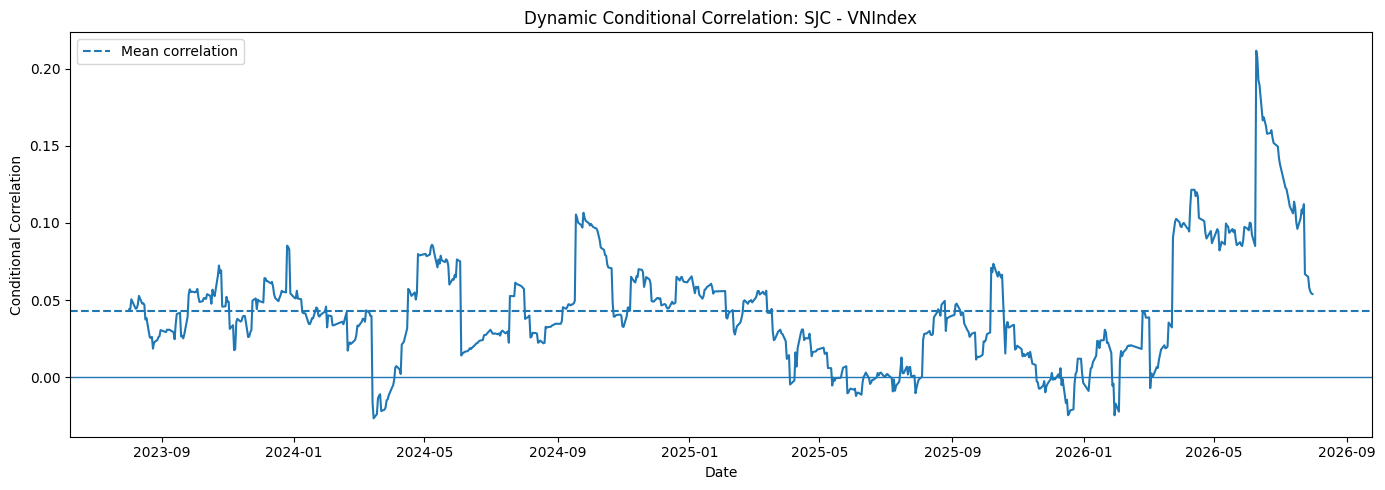

In [ ]:
# ============================================================
# SJC-VNINDEX DCC(1,1)
# RECONSTRUCT DYNAMIC CONDITIONAL CORRELATION
# FROM BEST MULTI-START SOLUTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. USE BEST MULTI-START PARAMETERS
# ============================================================

a_sjc_vn = float(dcc_a_sjc_vn)
b_sjc_vn = float(dcc_b_sjc_vn)

print("=" * 80)
print("SJC-VNINDEX FINAL DCC PARAMETERS")
print("=" * 80)

print(f"a       = {a_sjc_vn:.10f}")
print(f"b       = {b_sjc_vn:.10f}")
print(f"a + b   = {a_sjc_vn + b_sjc_vn:.10f}")


# ============================================================
# 2. INITIALIZE Q0 = Q_BAR
# ============================================================

Q_t = Q_bar_sjc_vn.copy()

R_list_sjc_vn_final = []


# ============================================================
# 3. INITIAL R0
# ============================================================

diag_Q = np.diag(Q_t)

D_inv = np.diag(
    1.0 / np.sqrt(diag_Q)
)

R_t = (
    D_inv
    @ Q_t
    @ D_inv
)

R_t = 0.5 * (
    R_t
    + R_t.T
)

R_list_sjc_vn_final.append(
    R_t.copy()
)


# ============================================================
# 4. DCC RECURSION
# ============================================================

for t in range(1, T_sjc_vn):

    z_prev = (
        Z_np_sjc_vn[t - 1]
        .reshape(-1, 1)
    )

    Q_t = (

        (
            1.0
            - a_sjc_vn
            - b_sjc_vn
        )
        * Q_bar_sjc_vn

        + a_sjc_vn
        * (
            z_prev
            @ z_prev.T
        )

        + b_sjc_vn
        * Q_t
    )

    # Numerical symmetry
    Q_t = 0.5 * (
        Q_t
        + Q_t.T
    )

    diag_Q = np.diag(Q_t)

    D_inv = np.diag(
        1.0 / np.sqrt(diag_Q)
    )

    R_t = (
        D_inv
        @ Q_t
        @ D_inv
    )

    R_t = 0.5 * (
        R_t
        + R_t.T
    )

    R_list_sjc_vn_final.append(
        R_t.copy()
    )


# ============================================================
# 5. STORE R_t ARRAY
# ============================================================

R_array_sjc_vn_final = np.array(
    R_list_sjc_vn_final
)

print("\nR_array shape:")
print(
    R_array_sjc_vn_final.shape
)


# ============================================================
# 6. EXTRACT SJC-VNINDEX DYNAMIC CORRELATION
# ============================================================

dcc_sjc_vn_final = pd.DataFrame({

    "Date":
        Z_sjc_vn["Date"],

    "SJC_VNINDEX":
        R_array_sjc_vn_final[:, 0, 1]
})


print("\n" + "=" * 80)
print("SJC-VNINDEX DYNAMIC CONDITIONAL CORRELATION")
print("=" * 80)

display(
    dcc_sjc_vn_final.head()
)


# ============================================================
# 7. SUMMARY STATISTICS
# ============================================================

dcc_summary_sjc_vn_final = pd.DataFrame({

    "Mean": [
        dcc_sjc_vn_final[
            "SJC_VNINDEX"
        ].mean()
    ],

    "Std": [
        dcc_sjc_vn_final[
            "SJC_VNINDEX"
        ].std()
    ],

    "Min": [
        dcc_sjc_vn_final[
            "SJC_VNINDEX"
        ].min()
    ],

    "Max": [
        dcc_sjc_vn_final[
            "SJC_VNINDEX"
        ].max()
    ]

},
index=["SJC-VNIndex"])


print("\n" + "=" * 80)
print("SJC-VNINDEX DCC SUMMARY")
print("=" * 80)

display(
    dcc_summary_sjc_vn_final
    .round(6)
)


# ============================================================
# 8. FIND DATES OF MINIMUM AND MAXIMUM CORRELATION
# ============================================================

idx_min = (
    dcc_sjc_vn_final[
        "SJC_VNINDEX"
    ].idxmin()
)

idx_max = (
    dcc_sjc_vn_final[
        "SJC_VNINDEX"
    ].idxmax()
)


print("\n" + "=" * 80)
print("EXTREME CORRELATION DATES")
print("=" * 80)

print(
    "Minimum correlation:"
)

print(
    dcc_sjc_vn_final.loc[
        idx_min
    ]
)

print(
    "\nMaximum correlation:"
)

print(
    dcc_sjc_vn_final.loc[
        idx_max
    ]
)


# ============================================================
# 9. PLOT DYNAMIC CONDITIONAL CORRELATION
# ============================================================

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    dcc_sjc_vn_final["Date"],
    dcc_sjc_vn_final["SJC_VNINDEX"]
)

plt.axhline(
    y=dcc_sjc_vn_final[
        "SJC_VNINDEX"
    ].mean(),
    linestyle="--",
    label="Mean correlation"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Dynamic Conditional Correlation: SJC - VNIndex"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Conditional Correlation"
)

plt.legend()

plt.tight_layout()

plt.show()

#### Kết quả tương quan động giữa SJC và VN-Index
Kết quả DCC(1,1) cho cặp SJC-VNIndex cho thấy hệ số $(a=0.0096$), $(b=0.9608$) và $(a+b=0.9704<1$), phản ánh tương quan có điều kiện biến động theo thời gian với mức độ dai dẳng cao.

Tương quan trung bình đạt $(0.0430$), cho thấy mối quan hệ đồng biến giữa hai tài sản nhìn chung khá yếu. Trong toàn bộ giai đoạn nghiên cứu, hệ số tương quan dao động từ $(-0.0266$) đến $(0.2117$).

Mức thấp nhất ghi nhận vào ngày **15/03/2024**, trong khi mức cao nhất xuất hiện vào ngày **09/06/2026**. Kết quả cho thấy SJC và VN-Index phần lớn duy trì tương quan thấp, nhưng mức độ đồng biến có thể gia tăng đáng kể trong một số giai đoạn nhất định.

#### Diagnostics cho DCC SJC-VNindex

1. Kiểm định tính hằng của correlation theo kiểu Engle-Sheppard cho từng cặp, để bổ sung bằng chứng CCC/DCC.
2. Kiểm tra tính hợp lệ của các ma trận $(R_t$): đối xứng, đường chéo bằng 1, positive definite, correlation nằm trong $([-1,1]$).

In [ ]:
# ============================================================
# MODEL 2 - STEP 10
# DCC / CCC FINAL DIAGNOSTICS
#
# 1. Pairwise Engle-Sheppard-style constant correlation test
# 2. Check validity of final conditional correlation matrices
#
# Uses:
#   Z_np_btc_sjc
#   Z_np_btc_vn
#   Z_np_sjc_vn
#
#   Q_bar_btc_sjc
#   Q_bar_btc_vn
#   Q_bar_sjc_vn
#
#   R_array_sjc_vn_final
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2


# ============================================================
# 1. AUXILIARY FUNCTION:
#    VECH OF z_t z_t'
#
# For N = 2:
#
# vech(z_t z_t') =
# [
#     z1^2,
#     z1*z2,
#     z2^2
# ]
#
# Dimension m = N(N+1)/2 = 3
# ============================================================

def build_vech_outer(Z):

    T, N = Z.shape

    tri_idx = np.tril_indices(N)

    W = np.zeros(
        (
            T,
            len(tri_idx[0])
        )
    )

    for t in range(T):

        outer = np.outer(
            Z[t],
            Z[t]
        )

        W[t] = outer[
            tri_idx
        ]

    # Center each second-moment series
    W = (
        W
        - W.mean(axis=0)
    )

    return W


# ============================================================
# 2. ENGLE-SHEPPARD-STYLE CCC TEST
#
# H0:
#     Conditional correlation is constant
#
# H1:
#     Correlation contains dynamic dependence
#
# Auxiliary regressions:
#
# W_t = c
#       + B1 W_(t-1)
#       + ...
#       + Bp W_(t-p)
#       + error_t
#
# Statistic:
#     LM = T_eff * sum(R_j^2)
#
# df:
#     m^2 * p
#
# For bivariate system:
#     m = 3
#     df = 9p
# ============================================================

def engle_sheppard_pair_test(
    Z,
    lag
):

    W = build_vech_outer(
        Z
    )

    T, m = W.shape


    # --------------------------------------------------------
    # Build dependent variables
    # --------------------------------------------------------

    Y = W[lag:]


    # --------------------------------------------------------
    # Build lagged regressors
    # --------------------------------------------------------

    X_lags = []

    for l in range(
        1,
        lag + 1
    ):

        X_lags.append(
            W[
                lag - l:
                T - l
            ]
        )


    X = np.hstack(
        X_lags
    )


    # Add constant
    X = np.column_stack([
        np.ones(len(X)),
        X
    ])


    T_eff = len(Y)

    sum_R2 = 0.0


    # --------------------------------------------------------
    # Run one auxiliary regression
    # for each vech component
    # --------------------------------------------------------

    for j in range(m):

        y = Y[:, j]


        beta = np.linalg.lstsq(
            X,
            y,
            rcond=None
        )[0]


        fitted = X @ beta


        residual = (
            y
            - fitted
        )


        SSR = np.sum(
            residual ** 2
        )


        TSS = np.sum(
            (
                y
                - y.mean()
            ) ** 2
        )


        if TSS <= 1e-14:

            R2 = 0.0

        else:

            R2 = (
                1.0
                - SSR / TSS
            )


        # Numerical protection
        R2 = max(
            R2,
            0.0
        )


        sum_R2 += R2


    LM_stat = (
        T_eff
        * sum_R2
    )


    df = (
        m
        * m
        * lag
    )


    p_value = chi2.sf(
        LM_stat,
        df
    )


    return (
        LM_stat,
        df,
        p_value
    )


# ============================================================
# 3. RUN TEST FOR ALL THREE PAIRS
# ============================================================

pairs_for_test = {

    "BTC-SJC":
        Z_np_btc_sjc,

    "BTC-VNINDEX":
        Z_np_btc_vn,

    "SJC-VNINDEX":
        Z_np_sjc_vn
}


test_lags = [
    1,
    2,
    5,
    10
]


es_results = []


for pair_name, Z_pair in pairs_for_test.items():

    for lag in test_lags:

        stat, df, pval = (
            engle_sheppard_pair_test(
                Z_pair,
                lag
            )
        )


        es_results.append({

            "Pair":
                pair_name,

            "Lag":
                lag,

            "Statistic":
                stat,

            "df":
                df,

            "p-value":
                pval,

            "Decision_5%":
                (
                    "Reject CCC"
                    if pval < 0.05
                    else "Do not reject CCC"
                )
        })


engle_sheppard_pairwise = (
    pd.DataFrame(
        es_results
    )
)


print("=" * 100)
print("PAIRWISE CONSTANT-CORRELATION DIAGNOSTIC")
print("=" * 100)

display(
    engle_sheppard_pairwise
    .round({
        "Statistic": 6,
        "p-value": 6
    })
)


# ============================================================
# 4. CREATE FINAL CCC MATRICES
#    FOR BTC-SJC AND BTC-VNINDEX
#
# Normalize Q_bar into correlation matrix:
#
# R = D^(-1) Q_bar D^(-1)
# ============================================================

def qbar_to_corr(
    Q_bar
):

    diag_Q = np.diag(
        Q_bar
    )


    D_inv = np.diag(
        1.0
        / np.sqrt(
            diag_Q
        )
    )


    R = (
        D_inv
        @ Q_bar
        @ D_inv
    )


    R = 0.5 * (
        R
        + R.T
    )


    return R


# BTC-SJC CCC matrix
R_ccc_btc_sjc = (
    qbar_to_corr(
        Q_bar_btc_sjc
    )
)


# BTC-VNIndex CCC matrix
R_ccc_btc_vn = (
    qbar_to_corr(
        Q_bar_btc_vn
    )
)


# Repeat constant matrices across time
R_array_btc_sjc_final = np.repeat(

    R_ccc_btc_sjc[
        None,
        :,
        :
    ],

    repeats=
        len(
            Z_np_btc_sjc
        ),

    axis=0
)


R_array_btc_vn_final = np.repeat(

    R_ccc_btc_vn[
        None,
        :,
        :
    ],

    repeats=
        len(
            Z_np_btc_vn
        ),

    axis=0
)


# ============================================================
# 5. MATRIX VALIDITY DIAGNOSTICS
#
# Check:
# - Symmetry
# - Diagonal = 1
# - Positive definiteness
# - |rho| <= 1
# ============================================================

def diagnose_R_array(
    R_array,
    pair_name
):

    min_eigenvalue = np.inf

    max_symmetry_error = 0.0

    max_diag_error = 0.0

    min_corr = np.inf

    max_corr = -np.inf


    for R_t in R_array:

        # Symmetry error
        symmetry_error = (
            np.max(
                np.abs(
                    R_t
                    - R_t.T
                )
            )
        )


        max_symmetry_error = max(
            max_symmetry_error,
            symmetry_error
        )


        # Diagonal should be 1
        diag_error = (
            np.max(
                np.abs(
                    np.diag(R_t)
                    - 1.0
                )
            )
        )


        max_diag_error = max(
            max_diag_error,
            diag_error
        )


        # Eigenvalues
        eigenvalues = (
            np.linalg.eigvalsh(
                R_t
            )
        )


        min_eigenvalue = min(
            min_eigenvalue,
            eigenvalues.min()
        )


        # Pairwise correlation
        rho = R_t[0, 1]


        min_corr = min(
            min_corr,
            rho
        )


        max_corr = max(
            max_corr,
            rho
        )


    positive_definite = (
        min_eigenvalue > 0
    )


    valid_corr_bounds = (
        min_corr >= -1
        and max_corr <= 1
    )


    return {

        "Pair":
            pair_name,

        "Min_Eigenvalue":
            min_eigenvalue,

        "Max_Symmetry_Error":
            max_symmetry_error,

        "Max_Diag_Error":
            max_diag_error,

        "Min_Correlation":
            min_corr,

        "Max_Correlation":
            max_corr,

        "Positive_Definite":
            positive_definite,

        "Valid_Corr_Bounds":
            valid_corr_bounds
    }


# ============================================================
# 6. RUN MATRIX DIAGNOSTICS
# ============================================================

R_diagnostics = []


R_diagnostics.append(
    diagnose_R_array(
        R_array_btc_sjc_final,
        "BTC-SJC (CCC)"
    )
)


R_diagnostics.append(
    diagnose_R_array(
        R_array_btc_vn_final,
        "BTC-VNINDEX (CCC)"
    )
)


R_diagnostics.append(
    diagnose_R_array(
        R_array_sjc_vn_final,
        "SJC-VNINDEX (DCC)"
    )
)


dcc_matrix_diagnostics = (
    pd.DataFrame(
        R_diagnostics
    )
)


print("\n" + "=" * 100)
print("FINAL CONDITIONAL CORRELATION MATRIX DIAGNOSTICS")
print("=" * 100)

display(
    dcc_matrix_diagnostics
    .round(10)
)


# ============================================================
# 7. FINAL PARAMETER / MODEL SUMMARY
# ============================================================

final_model2_specification = pd.DataFrame({

    "Pair": [
        "BTC-SJC",
        "BTC-VNINDEX",
        "SJC-VNINDEX"
    ],

    "Final_Model": [
        "CCC",
        "CCC",
        "DCC(1,1)"
    ],

    "a": [
        0.0,
        0.0,
        a_sjc_vn
    ],

    "b": [
        0.0,
        0.0,
        b_sjc_vn
    ],

    "a+b": [
        0.0,
        0.0,
        a_sjc_vn + b_sjc_vn
    ]
})


print("\n" + "=" * 100)
print("MODEL 2 - FINAL SPECIFICATION SUMMARY")
print("=" * 100)

display(
    final_model2_specification
    .round(6)
)

PAIRWISE CONSTANT-CORRELATION DIAGNOSTIC


,Pair,Lag,Statistic,df,p-value,Decision_5%
0,BTC-SJC,1,10.708592,9,0.296213,Do not reject CCC
1,BTC-SJC,2,33.105901,18,0.016205,Reject CCC
2,BTC-SJC,5,55.912964,45,0.127634,Do not reject CCC
3,BTC-SJC,10,76.646062,90,0.841095,Do not reject CCC
4,BTC-VNINDEX,1,6.722919,9,0.665942,Do not reject CCC
5,BTC-VNINDEX,2,36.587813,18,0.005928,Reject CCC
6,BTC-VNINDEX,5,58.078355,45,0.091315,Do not reject CCC
7,BTC-VNINDEX,10,87.593004,90,0.552193,Do not reject CCC
8,SJC-VNINDEX,1,3.703355,9,0.929831,Do not reject CCC
9,SJC-VNINDEX,2,6.965013,18,0.990418,Do not reject CCC



FINAL CONDITIONAL CORRELATION MATRIX DIAGNOSTICS


,Pair,Min_Eigenvalue,Max_Symmetry_Error,Max_Diag_Error,Min_Correlation,Max_Correlation,Positive_Definite,Valid_Corr_Bounds
0,BTC-SJC (CCC),0.967953,0.0,0.0,0.032047,0.032047,True,True
1,BTC-VNINDEX (CCC),0.926124,0.0,0.0,0.073876,0.073876,True,True
2,SJC-VNINDEX (DCC),0.788342,0.0,0.0,-0.026649,0.211658,True,True



MODEL 2 - FINAL SPECIFICATION SUMMARY


,Pair,Final_Model,a,b,a+b
0,BTC-SJC,CCC,0.000000,0.000000,0.000000
1,BTC-VNINDEX,CCC,0.000000,0.000000,0.000000
2,SJC-VNINDEX,"DCC(1,1)",0.009647,0.960758,0.970405


## Kết luận kiểm định và chẩn đoán Model 2
Kết quả kiểm định tính hằng của tương quan cho thấy giả thuyết Constant Conditional Correlation (CCC) nhìn chung không bị bác bỏ. Đối với BTC-SJC và BTC-VNIndex, chỉ kiểm định tại độ trễ 2 bác bỏ CCC ở mức ý nghĩa 5%, trong khi các độ trễ 1, 5 và 10 đều không bác bỏ. Đặc biệt, đối với SJC-VNIndex, giả thuyết CCC không bị bác bỏ tại tất cả các độ trễ được xem xét.

Mặc dù ước lượng DCC(1,1) cho SJC-VNIndex thu được nghiệm nội $(a=0.0096$), $(b=0.9608$) và một chuỗi tương quan biến động theo thời gian, bằng chứng kiểm định chưa đủ mạnh để khẳng định sự tồn tại của tương quan có điều kiện động. Do đó, kết quả DCC của cặp này được sử dụng chủ yếu như một phân tích mô tả bổ sung, trong khi kết luận thống kê chính vẫn nghiêng về tương quan có điều kiện hằng.

## Thống kê mô tả của correlations

In [ ]:
# ============================================================
# MODEL 2 - STEP 11
# DESCRIPTIVE STATISTICS OF CONDITIONAL CORRELATIONS
#
# Final interpretation:
#   BTC-SJC      -> CCC
#   BTC-VNINDEX  -> CCC
#   SJC-VNINDEX  -> CCC not rejected,
#                   DCC path retained as descriptive analysis
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. EXTRACT FINAL CCC CORRELATIONS
# ============================================================

rho_btc_sjc_ccc = float(
    R_ccc_btc_sjc[0, 1]
)

rho_btc_vn_ccc = float(
    R_ccc_btc_vn[0, 1]
)


print("=" * 80)
print("FINAL CCC CORRELATIONS")
print("=" * 80)

print(
    f"BTC-SJC      : "
    f"{rho_btc_sjc_ccc:.6f}"
)

print(
    f"BTC-VNINDEX  : "
    f"{rho_btc_vn_ccc:.6f}"
)


# ============================================================
# 2. DESCRIPTIVE DCC PATH FOR SJC-VNINDEX
# ============================================================

rho_sjc_vn_dynamic = (
    dcc_sjc_vn_final[
        "SJC_VNINDEX"
    ]
)


sjc_vn_mean = (
    rho_sjc_vn_dynamic.mean()
)

sjc_vn_std = (
    rho_sjc_vn_dynamic.std()
)

sjc_vn_min = (
    rho_sjc_vn_dynamic.min()
)

sjc_vn_max = (
    rho_sjc_vn_dynamic.max()
)

sjc_vn_median = (
    rho_sjc_vn_dynamic.median()
)


# ============================================================
# 3. BUILD FINAL SUMMARY TABLE
# ============================================================

model2_correlation_summary = pd.DataFrame({

    "Pair": [
        "BTC-SJC",
        "BTC-VNINDEX",
        "SJC-VNINDEX"
    ],

    "Statistical_Conclusion": [
        "CCC",
        "CCC",
        "CCC not rejected"
    ],

    "Correlation_Measure": [
        "CCC correlation",
        "CCC correlation",
        "Estimated DCC path (descriptive)"
    ],

    "Mean": [
        rho_btc_sjc_ccc,
        rho_btc_vn_ccc,
        sjc_vn_mean
    ],

    "Std": [
        0.0,
        0.0,
        sjc_vn_std
    ],

    "Median": [
        rho_btc_sjc_ccc,
        rho_btc_vn_ccc,
        sjc_vn_median
    ],

    "Min": [
        rho_btc_sjc_ccc,
        rho_btc_vn_ccc,
        sjc_vn_min
    ],

    "Max": [
        rho_btc_sjc_ccc,
        rho_btc_vn_ccc,
        sjc_vn_max
    ]
})


print("\n" + "=" * 110)
print("MODEL 2 - CONDITIONAL CORRELATION SUMMARY")
print("=" * 110)


display(
    model2_correlation_summary
    .round(6)
)


# ============================================================
# 4. ADD RANGE FOR INTERPRETATION
# ============================================================

model2_correlation_summary[
    "Range"
] = (
    model2_correlation_summary["Max"]
    - model2_correlation_summary["Min"]
)


print("\n" + "=" * 110)
print("MODEL 2 - SUMMARY INCLUDING CORRELATION RANGE")
print("=" * 110)


display(
    model2_correlation_summary
    .round(6)
)


# ============================================================
# 5. SIMPLE ECONOMIC-MAGNITUDE CLASSIFICATION
#
# Based on absolute mean correlation:
#
# |rho| < 0.10       -> Very weak
# 0.10 <= |rho|<0.30 -> Weak
# 0.30 <= |rho|<0.50 -> Moderate
# >= 0.50            -> Strong
#
# This classification is descriptive only.
# ============================================================

def classify_corr_strength(rho):

    abs_rho = abs(rho)

    if abs_rho < 0.10:
        return "Very weak"

    elif abs_rho < 0.30:
        return "Weak"

    elif abs_rho < 0.50:
        return "Moderate"

    else:
        return "Strong"


model2_correlation_summary[
    "Mean_Strength"
] = (
    model2_correlation_summary[
        "Mean"
    ]
    .apply(
        classify_corr_strength
    )
)


print("\n" + "=" * 110)
print("MODEL 2 - FINAL DESCRIPTIVE CORRELATION TABLE")
print("=" * 110)


display(
    model2_correlation_summary
    .round(6)
)

FINAL CCC CORRELATIONS
BTC-SJC      : 0.032047
BTC-VNINDEX  : 0.073876

MODEL 2 - CONDITIONAL CORRELATION SUMMARY


,Pair,Statistical_Conclusion,Correlation_Measure,Mean,Std,Median,Min,Max
0,BTC-SJC,CCC,CCC correlation,0.032047,0.000000,0.032047,0.032047,0.032047
1,BTC-VNINDEX,CCC,CCC correlation,0.073876,0.000000,0.073876,0.073876,0.073876
2,SJC-VNINDEX,CCC not rejected,Estimated DCC path (descriptive),0.043021,0.036845,0.039287,-0.026649,0.211658



MODEL 2 - SUMMARY INCLUDING CORRELATION RANGE


,Pair,Statistical_Conclusion,Correlation_Measure,Mean,Std,Median,Min,Max,Range
0,BTC-SJC,CCC,CCC correlation,0.032047,0.000000,0.032047,0.032047,0.032047,0.000000
1,BTC-VNINDEX,CCC,CCC correlation,0.073876,0.000000,0.073876,0.073876,0.073876,0.000000
2,SJC-VNINDEX,CCC not rejected,Estimated DCC path (descriptive),0.043021,0.036845,0.039287,-0.026649,0.211658,0.238307



MODEL 2 - FINAL DESCRIPTIVE CORRELATION TABLE


,Pair,Statistical_Conclusion,Correlation_Measure,Mean,Std,Median,Min,Max,Range,Mean_Strength
0,BTC-SJC,CCC,CCC correlation,0.032047,0.000000,0.032047,0.032047,0.032047,0.000000,Very weak
1,BTC-VNINDEX,CCC,CCC correlation,0.073876,0.000000,0.073876,0.073876,0.073876,0.000000,Very weak
2,SJC-VNINDEX,CCC not rejected,Estimated DCC path (descriptive),0.043021,0.036845,0.039287,-0.026649,0.211658,0.238307,Very weak


#### Kết luận thống kê mô tả
Kết luận thống kê mô tả tương quan có điều kiện
Kết quả cho thấy mức độ tương quan giữa ba cặp tài sản nhìn chung rất yếu. Đối với BTC-SJC và BTC-VNIndex, mô hình CCC cho hệ số tương quan lần lượt là $(0.0320$) và $(0.0739$), cho thấy mối quan hệ đồng biến nhưng ở mức rất thấp. Đối với SJC-VNIndex, mặc dù giả thuyết CCC không bị bác bỏ, đường DCC ước lượng dùng cho mục đích mô tả có tương quan trung bình $(0.0430$), dao động từ $(-0.0266$) đến $(0.2117$). Nhìn chung, kết quả cho thấy không tồn tại mối tương quan mạnh và ổn định giữa các tài sản trong giai đoạn nghiên cứu, trong đó SJC-VNIndex có mức biến động tương quan lớn hơn hai cặp còn lại.

## Xác định giai đoạn tương quan mạnh, giảm mạnh, hoặc đảo chiều

Vì BTC-SJC và BTC-VNIndex đã được kết luận theo CCC nên không có dynamics để phân tích theo thời gian. Bước này chỉ áp dụng cho đường DCC mô tả của SJC-VNIndex.

In [ ]:
# ============================================================
# MODEL 2 - STEP 12
# IDENTIFY STRONG INCREASES, DECREASES AND SIGN REVERSALS
# SJC - VNINDEX
#
# Note:
# BTC-SJC and BTC-VNINDEX are CCC,
# therefore no time-varying periods are analyzed for them.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. PREPARE DYNAMIC CORRELATION SERIES
# ============================================================

corr_periods_sjc_vn = (
    dcc_sjc_vn_final[
        ["Date", "SJC_VNINDEX"]
    ]
    .copy()
)

corr_periods_sjc_vn["Date"] = pd.to_datetime(
    corr_periods_sjc_vn["Date"]
)

corr_periods_sjc_vn = (
    corr_periods_sjc_vn
    .sort_values("Date")
    .reset_index(drop=True)
)


# ============================================================
# 2. ONE-OBSERVATION CHANGE
#
# Δrho_t = rho_t - rho_(t-1)
# ============================================================

corr_periods_sjc_vn["Delta_rho_1"] = (
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    .diff()
)


# ============================================================
# 3. TOP STRONGEST DAILY INCREASES
# ============================================================

top_increases_1 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_1"
        ]
    ]
    .nlargest(
        10,
        "Delta_rho_1"
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("TOP 10 STRONGEST ONE-OBSERVATION CORRELATION INCREASES")
print("=" * 90)

display(
    top_increases_1
    .round(6)
)


# ============================================================
# 4. TOP STRONGEST DAILY DECREASES
# ============================================================

top_decreases_1 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_1"
        ]
    ]
    .nsmallest(
        10,
        "Delta_rho_1"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("TOP 10 STRONGEST ONE-OBSERVATION CORRELATION DECREASES")
print("=" * 90)

display(
    top_decreases_1
    .round(6)
)


# ============================================================
# 5. SIGN REVERSALS AROUND ZERO
#
# Positive -> Negative
# Negative -> Positive
# ============================================================

corr_periods_sjc_vn["Prev_rho"] = (
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    .shift(1)
)


corr_periods_sjc_vn[
    "Sign_Reversal"
] = np.select(

    [

        (
            (
                corr_periods_sjc_vn[
                    "Prev_rho"
                ] >= 0
            )
            &
            (
                corr_periods_sjc_vn[
                    "SJC_VNINDEX"
                ] < 0
            )
        ),

        (
            (
                corr_periods_sjc_vn[
                    "Prev_rho"
                ] <= 0
            )
            &
            (
                corr_periods_sjc_vn[
                    "SJC_VNINDEX"
                ] > 0
            )
        )

    ],

    [
        "Positive -> Negative",
        "Negative -> Positive"
    ],

    default=""
)


sign_reversals_sjc_vn = (
    corr_periods_sjc_vn[
        corr_periods_sjc_vn[
            "Sign_Reversal"
        ] != ""
    ]
    [
        [
            "Date",
            "Prev_rho",
            "SJC_VNINDEX",
            "Sign_Reversal"
        ]
    ]
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("SJC-VNINDEX CORRELATION SIGN REVERSALS")
print("=" * 90)

display(
    sign_reversals_sjc_vn
    .round(6)
)

print(
    "\nNumber of sign reversals:",
    len(sign_reversals_sjc_vn)
)


# ============================================================
# 6. MEDIUM-TERM CHANGES
#
# 5 observations:
# short-run movement
#
# 20 observations:
# broader correlation regime movement
# ============================================================

corr_periods_sjc_vn[
    "Delta_rho_5"
] = (
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    -
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    .shift(5)
)


corr_periods_sjc_vn[
    "Delta_rho_20"
] = (
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    -
    corr_periods_sjc_vn[
        "SJC_VNINDEX"
    ]
    .shift(20)
)


# ============================================================
# 7. STRONGEST 5-OBSERVATION MOVEMENTS
# ============================================================

top_increases_5 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_5"
        ]
    ]
    .nlargest(
        5,
        "Delta_rho_5"
    )
    .reset_index(drop=True)
)


top_decreases_5 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_5"
        ]
    ]
    .nsmallest(
        5,
        "Delta_rho_5"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("TOP 5 STRONGEST 5-OBSERVATION INCREASES")
print("=" * 90)

display(
    top_increases_5
    .round(6)
)


print("\n" + "=" * 90)
print("TOP 5 STRONGEST 5-OBSERVATION DECREASES")
print("=" * 90)

display(
    top_decreases_5
    .round(6)
)


# ============================================================
# 8. STRONGEST 20-OBSERVATION MOVEMENTS
# ============================================================

top_increases_20 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_20"
        ]
    ]
    .nlargest(
        5,
        "Delta_rho_20"
    )
    .reset_index(drop=True)
)


top_decreases_20 = (
    corr_periods_sjc_vn[
        [
            "Date",
            "SJC_VNINDEX",
            "Delta_rho_20"
        ]
    ]
    .nsmallest(
        5,
        "Delta_rho_20"
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("TOP 5 STRONGEST 20-OBSERVATION INCREASES")
print("=" * 90)

display(
    top_increases_20
    .round(6)
)


print("\n" + "=" * 90)
print("TOP 5 STRONGEST 20-OBSERVATION DECREASES")
print("=" * 90)

display(
    top_decreases_20
    .round(6)
)


# ============================================================
# 9. SAVE IMPORTANT OBJECTS
# ============================================================

model2_step12_summary = {

    "Top_daily_increases":
        top_increases_1,

    "Top_daily_decreases":
        top_decreases_1,

    "Sign_reversals":
        sign_reversals_sjc_vn,

    "Top_5obs_increases":
        top_increases_5,

    "Top_5obs_decreases":
        top_decreases_5,

    "Top_20obs_increases":
        top_increases_20,

    "Top_20obs_decreases":
        top_decreases_20
}


print("\n" + "=" * 90)

print(
    "Objects saved in: model2_step12_summary"
)

TOP 10 STRONGEST ONE-OBSERVATION CORRELATION INCREASES


,Date,SJC_VNINDEX,Delta_rho_1
0,2026-06-09,0.211658,0.126580
1,2026-03-24,0.090450,0.058160
2,2024-09-18,0.105511,0.055842
3,2025-10-07,0.070932,0.041939
4,2026-02-03,0.010890,0.033222
5,2023-12-26,0.085303,0.030326
6,2024-07-19,0.052661,0.030278
7,2024-04-16,0.057262,0.025606
8,2024-04-25,0.079879,0.025369
9,2026-02-24,0.042384,0.024053



TOP 10 STRONGEST ONE-OBSERVATION CORRELATION DECREASES


,Date,SJC_VNINDEX,Delta_rho_1
0,2024-06-04,0.014090,-0.060976
1,2024-03-14,-0.016530,-0.056203
2,2025-10-20,0.015367,-0.051104
3,2026-03-03,-0.007063,-0.045845
4,2026-07-24,0.066824,-0.045349
5,2023-12-29,0.054315,-0.028387
6,2024-02-20,0.017254,-0.024828
7,2023-10-27,0.045758,-0.023517
8,2026-06-15,0.166473,-0.022969
9,2024-10-22,0.047862,-0.022767



SJC-VNINDEX CORRELATION SIGN REVERSALS


...


TOP 5 STRONGEST 20-OBSERVATION INCREASES


,Date,SJC_VNINDEX,Delta_rho_20
0,2026-06-09,0.211658,0.111987
1,2026-06-10,0.207193,0.108954
2,2026-03-31,0.097755,0.104818
3,2026-04-10,0.121525,0.103590
4,2026-04-15,0.119964,0.100922



TOP 5 STRONGEST 20-OBSERVATION DECREASES


,Date,SJC_VNINDEX,Delta_rho_20
0,2026-07-07,0.121907,-0.089750
1,2026-07-08,0.118345,-0.088848
2,2026-07-27,0.065096,-0.084455
3,2026-07-24,0.066824,-0.084445
4,2026-07-28,0.057980,-0.084026



Objects saved in: model2_step12_summary


### Kết luận về các giai đoạn tương quan tăng, giảm và đảo chiều
Đường DCC mô tả của cặp SJC-VNIndex cho thấy một số giai đoạn biến động tương quan đáng chú ý. Mức giảm mạnh nhất trong ngắn hạn xuất hiện vào giữa tháng 3/2024, khi hệ số tương quan giảm xuống mức âm thấp nhất $(-0.0266$). Ngược lại, giai đoạn tăng mạnh nhất tập trung vào tháng 6/2026, đặc biệt ngày 09/06/2026 khi tương quan đạt mức cao nhất $(0.2117$); trong cửa sổ 5 quan sát, mức tăng đạt khoảng $(0.1164$). Xét trong cửa sổ 20 quan sát, xu hướng tăng đáng kể đã xuất hiện từ cuối tháng 3 đến giữa tháng 4/2026 và tiếp tục mạnh lên đến tháng 6/2026. Sau đó, tương quan giảm rõ rệt trong tháng 7/2026, với mức giảm khoảng $(0.09$) trong cửa sổ 20 quan sát.

Mặc dù ghi nhận 28 lần đổi dấu, phần lớn các lần này xảy ra khi hệ số tương quan chỉ dao động rất gần 0, nên phản ánh nhiều hơn sự dao động quanh trạng thái gần như không tương quan hơn là những lần đảo chiều mạnh về mặt kinh tế. Vì vậy, các giai đoạn đáng chú ý nhất là sự suy giảm vào tháng 3/2024, sự gia tăng mạnh từ quý II đến tháng 6/2026 và sự điều chỉnh giảm trong tháng 7/2026.

## Vẽ đồ thị đường tương quan động

MODEL 2 - FINAL CORRELATION DATA
Shape: (747, 4)
Date range: 2023-08-02 00:00:00 -> 2026-07-31 00:00:00


,Date,BTC_SJC,BTC_VNINDEX,SJC_VNINDEX
0,2023-08-02,0.032047,0.073876,0.044041
1,2023-08-03,0.032047,0.073876,0.044166
2,2023-08-04,0.032047,0.073876,0.050560
3,2023-08-07,0.032047,0.073876,0.046003
4,2023-08-08,0.032047,0.073876,0.044407


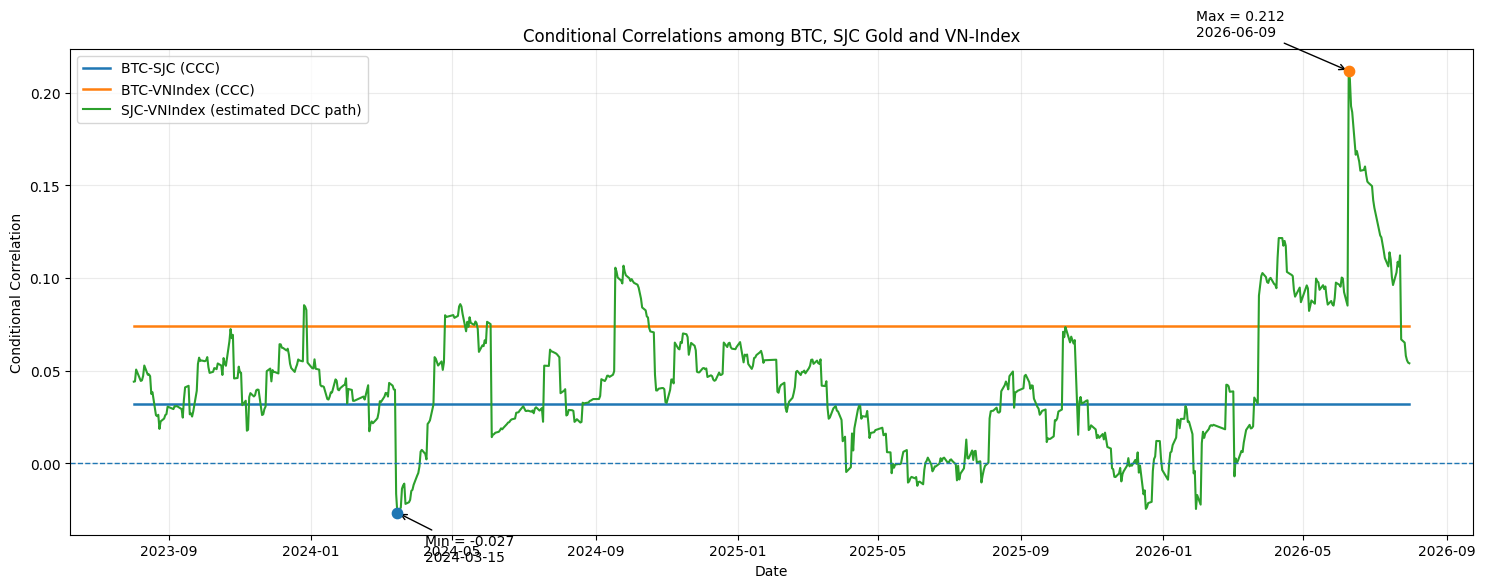


STEP 13 COMPLETE
Saved dataframe: model2_final_correlations


In [ ]:
# ============================================================
# MODEL 2 - STEP 13
# FINAL CORRELATION PLOT
#
# BTC-SJC      -> CCC
# BTC-VNINDEX  -> CCC
# SJC-VNINDEX  -> Estimated DCC path (descriptive)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. BUILD FINAL CORRELATION DATAFRAME
# ============================================================

model2_final_correlations = pd.DataFrame({

    "Date":
        dcc_sjc_vn_final["Date"],

    "BTC_SJC":
        rho_btc_sjc_ccc,

    "BTC_VNINDEX":
        rho_btc_vn_ccc,

    "SJC_VNINDEX":
        dcc_sjc_vn_final[
            "SJC_VNINDEX"
        ].to_numpy()
})


# ============================================================
# 2. CHECK DATA
# ============================================================

print("=" * 90)
print("MODEL 2 - FINAL CORRELATION DATA")
print("=" * 90)

print(
    "Shape:",
    model2_final_correlations.shape
)

print(
    "Date range:",
    model2_final_correlations["Date"].min(),
    "->",
    model2_final_correlations["Date"].max()
)

display(
    model2_final_correlations.head()
)


# ============================================================
# 3. PLOT ALL THREE PAIRS
# ============================================================

plt.figure(
    figsize=(15, 6)
)


plt.plot(
    model2_final_correlations["Date"],
    model2_final_correlations["BTC_SJC"],
    label="BTC-SJC (CCC)",
    linewidth=1.8
)


plt.plot(
    model2_final_correlations["Date"],
    model2_final_correlations["BTC_VNINDEX"],
    label="BTC-VNIndex (CCC)",
    linewidth=1.8
)


plt.plot(
    model2_final_correlations["Date"],
    model2_final_correlations["SJC_VNINDEX"],
    label="SJC-VNIndex (estimated DCC path)",
    linewidth=1.5
)


# ============================================================
# 4. ZERO REFERENCE LINE
# ============================================================

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)


# ============================================================
# 5. MARK SJC-VNINDEX MIN / MAX
# ============================================================

idx_min = (
    model2_final_correlations[
        "SJC_VNINDEX"
    ].idxmin()
)

idx_max = (
    model2_final_correlations[
        "SJC_VNINDEX"
    ].idxmax()
)


min_date = (
    model2_final_correlations.loc[
        idx_min,
        "Date"
    ]
)

min_value = (
    model2_final_correlations.loc[
        idx_min,
        "SJC_VNINDEX"
    ]
)


max_date = (
    model2_final_correlations.loc[
        idx_max,
        "Date"
    ]
)

max_value = (
    model2_final_correlations.loc[
        idx_max,
        "SJC_VNINDEX"
    ]
)


plt.scatter(
    min_date,
    min_value,
    s=55,
    zorder=5
)


plt.scatter(
    max_date,
    max_value,
    s=55,
    zorder=5
)


plt.annotate(
    f"Min = {min_value:.3f}\n{min_date:%Y-%m-%d}",

    xy=(
        min_date,
        min_value
    ),

    xytext=(
        20,
        -35
    ),

    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)


plt.annotate(
    f"Max = {max_value:.3f}\n{max_date:%Y-%m-%d}",

    xy=(
        max_date,
        max_value
    ),

    xytext=(
        -110,
        25
    ),

    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)


# ============================================================
# 6. FINAL FORMATTING
# ============================================================

plt.title(
    "Conditional Correlations among BTC, SJC Gold and VN-Index"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Conditional Correlation"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. SAVE FINAL DATA OBJECT
# ============================================================

print("\n" + "=" * 90)
print("STEP 13 COMPLETE")
print("=" * 90)

print(
    "Saved dataframe:",
    "model2_final_correlations"
)

# MODEL 3 - CHỈ SỐ LAN TRUYỀN RỦI RO

## Tạo dataset chính cho model 3

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# MODEL 3 - STEP 1
# BUILD SYNCHRONIZED CONDITIONAL VOLATILITY DATA
# ============================================================

# 1. Lấy Date từ synchronized sample của Model 2
if "Date" in sync_returns.columns:
    dy_dates = pd.to_datetime(sync_returns["Date"]).reset_index(drop=True)
else:
    dy_dates = pd.Series(
        pd.to_datetime(sync_returns.index),
        name="Date"
    ).reset_index(drop=True)


# 2. Chuẩn hóa volatility về Series và reset index
btc_vol = pd.Series(
    np.asarray(btc_volatility_sync).squeeze(),
    name="BTC"
).reset_index(drop=True)

sjc_vol = pd.Series(
    np.asarray(sjc_volatility_sync).squeeze(),
    name="SJC"
).reset_index(drop=True)

vn_vol = pd.Series(
    np.asarray(vnindex_volatility_sync).squeeze(),
    name="VNINDEX"
).reset_index(drop=True)


# 3. Kiểm tra độ dài trước khi ghép
print("=" * 70)
print("CHECK LENGTHS")
print("=" * 70)

print("sync_returns :", len(dy_dates))
print("BTC vol      :", len(btc_vol))
print("SJC vol      :", len(sjc_vol))
print("VN-Index vol :", len(vn_vol))


assert len(dy_dates) == len(btc_vol), \
    "BTC volatility length does not match sync_returns"

assert len(dy_dates) == len(sjc_vol), \
    "SJC volatility length does not match sync_returns"

assert len(dy_dates) == len(vn_vol), \
    "VN-Index volatility length does not match sync_returns"


# 4. Ghép dataset
dy_volatility = pd.DataFrame({
    "Date": dy_dates,
    "BTC": btc_vol,
    "SJC": sjc_vol,
    "VNINDEX": vn_vol
})


# 5. Sort theo thời gian
dy_volatility = (
    dy_volatility
    .sort_values("Date")
    .reset_index(drop=True)
)


# 6. Kiểm tra missing / inf
vol_cols = ["BTC", "SJC", "VNINDEX"]

dy_volatility[vol_cols] = (
    dy_volatility[vol_cols]
    .replace([np.inf, -np.inf], np.nan)
)


print("\n" + "=" * 70)
print("MODEL 3 VOLATILITY DATA")
print("=" * 70)

print("Shape:", dy_volatility.shape)

print(
    "Date range:",
    dy_volatility["Date"].min(),
    "->",
    dy_volatility["Date"].max()
)

print("\nMissing values:")
print(dy_volatility.isna().sum())

print("\nDescriptive statistics:")
print(
    dy_volatility[vol_cols]
    .describe()
    .round(6)
)

print("\nMinimum volatility:")
print(dy_volatility[vol_cols].min())

print("\nAll volatility > 0:")
print((dy_volatility[vol_cols] > 0).all())

CHECK LENGTHS
sync_returns : 747
BTC vol      : 747
SJC vol      : 747
VN-Index vol : 747

MODEL 3 VOLATILITY DATA
Shape: (747, 4)
Date range: 2023-08-02 00:00:00 -> 2026-07-31 00:00:00

Missing values:
Date       0
BTC        0
SJC        0
VNINDEX    0
dtype: int64

Descriptive statistics:
              BTC         SJC     VNINDEX
count  747.000000  747.000000  747.000000
mean     3.138428    1.584697    1.109501
std      0.543944    0.796759    0.413432
min      2.079419    0.210944    0.610954
25%      2.758323    1.090124    0.852673
50%      3.100127    1.431279    1.007766
75%      3.437925    1.921691    1.234266
max      5.646076    5.907933    3.983910

Minimum volatility:
BTC        2.079419
SJC        0.210944
VNINDEX    0.610954
dtype: float64

All volatility > 0:
BTC        True
SJC        True
VNINDEX    True
dtype: bool


### Lưu trước conditional variance cho robustness check

In [ ]:
# ============================================================
# ROBUSTNESS DATA: CONDITIONAL VARIANCE sigma_t^2
# ============================================================

dy_variance = dy_volatility.copy()

dy_variance["BTC"] = dy_variance["BTC"] ** 2
dy_variance["SJC"] = dy_variance["SJC"] ** 2
dy_variance["VNINDEX"] = dy_variance["VNINDEX"] ** 2

print(dy_variance.head())

        Date       BTC       SJC   VNINDEX
0 2023-08-02  5.184349  0.044498  1.463961
1 2023-08-03  5.717808  0.044702  1.212069
2 2023-08-04  5.328578  0.052129  1.346432
3 2023-08-07  5.143075  0.054341  1.255556
4 2023-08-08  4.826879  0.053963  1.156498


## Kiểm tra input


*   Tính dừng
*   Thống kê mô tả
*   Vẽ đồ thị dữ liệu




In [ ]:
# ============================================================
# MODEL 3 - DESCRIPTIVE STATISTICS
# Conditional Volatility: BTC, SJC, VN-Index
# ============================================================

import pandas as pd
from scipy.stats import skew, kurtosis

vol_cols = ["BTC", "SJC", "VNINDEX"]

desc_stats = pd.DataFrame({
    "N": dy_volatility[vol_cols].count(),
    "Mean": dy_volatility[vol_cols].mean(),
    "Std. Dev.": dy_volatility[vol_cols].std(),
    "Min": dy_volatility[vol_cols].min(),
    "25%": dy_volatility[vol_cols].quantile(0.25),
    "Median": dy_volatility[vol_cols].median(),
    "75%": dy_volatility[vol_cols].quantile(0.75),
    "Max": dy_volatility[vol_cols].max(),
    "Skewness": dy_volatility[vol_cols].apply(
        lambda x: skew(x.dropna(), bias=False)
    ),
    "Kurtosis": dy_volatility[vol_cols].apply(
        lambda x: kurtosis(x.dropna(), fisher=False, bias=False)
    )
})

# Chuyển tài sản thành hàng
desc_stats.index.name = "Asset"

print("=" * 90)
print("DESCRIPTIVE STATISTICS - CONDITIONAL VOLATILITY")
print("=" * 90)

print(desc_stats.round(4))

DESCRIPTIVE STATISTICS - CONDITIONAL VOLATILITY
           N    Mean  Std. Dev.     Min     25%  Median     75%     Max  \
Asset                                                                     
BTC      747  3.1384     0.5439  2.0794  2.7583  3.1001  3.4379  5.6461   
SJC      747  1.5847     0.7968  0.2109  1.0901  1.4313  1.9217  5.9079   
VNINDEX  747  1.1095     0.4134  0.6110  0.8527  1.0078  1.2343  3.9839   

         Skewness  Kurtosis  
Asset                        
BTC        0.7867    4.3205  
SJC        1.6084    7.3419  
VNINDEX    2.6366   14.1549  


### Thống kê mô tả
BTC có mức volatility trung bình cao nhất: $(3.1384$), tiếp theo là SJC $(1.5847$), VN-Index $(1.1095$).
Nhưng xét độ biến thiên tương đối, SJC lại dao động mạnh hơn quanh mức trung bình:BTC: $(CV $~ 0.17$)
SJC: $(CV $~ 0.50$)
VN-Index: $(CV $~ 0.37$)

Cả ba chuỗi đều lệch phải: $[
Skewness_{BTC}=0.79, Skewness_{SJC}=1.61, Skewness_{VN}=2.64 $]
tức là tồn tại những giai đoạn volatility tăng vọt.

Kurtosis đều lớn hơn 3: $[
4.32, 7.34, 14.15
$] đặc biệt VN-Index có phân phối volatility rất nhọn và đuôi dày.

BTC có volatility trung bình cao nhất nhưng VN-Index lại có skewness và kurtosis lớn nhất. Nghĩa là BTC thường xuyên ở mức biến động cao hơn, còn VN-Index có xu hướng tương đối yên ổn trong phần lớn thời gian nhưng xuất hiện một số volatility spike rất mạnh.

SJC nằm giữa hai trường hợp: volatility trung bình thấp hơn BTC nhưng biến động tương đối quanh mean lớn hơn đáng kể.

### Test tính dừng

In [ ]:
# ============================================================
# MODEL 3 - STEP 2
# STATIONARITY TESTS FOR CONDITIONAL VOLATILITY
# ADF + PP + KPSS
# ============================================================

import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron


vol_cols = ["BTC", "SJC", "VNINDEX"]

stationarity_results = []


for asset in vol_cols:

    x = (
        dy_volatility[asset]
        .dropna()
        .astype(float)
    )

    # ========================================================
    # 1. ADF TEST
    # H0: Unit root / Non-stationary
    # ========================================================

    adf_result = adfuller(
        x,
        regression="c",
        autolag="AIC"
    )

    adf_stat = adf_result[0]
    adf_p = adf_result[1]
    adf_lag = adf_result[2]


    # ========================================================
    # 2. PHILLIPS-PERRON TEST
    # H0: Unit root / Non-stationary
    # ========================================================

    pp_result = PhillipsPerron(
        x,
        trend="c"
    )

    pp_stat = pp_result.stat
    pp_p = pp_result.pvalue


    # ========================================================
    # 3. KPSS TEST
    # H0: Stationary
    # ========================================================

    kpss_result = kpss(
        x,
        regression="c",
        nlags="auto"
    )

    kpss_stat = kpss_result[0]
    kpss_p = kpss_result[1]
    kpss_lag = kpss_result[2]


    stationarity_results.append({

        "Asset": asset,

        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Lag": adf_lag,

        "PP Statistic": pp_stat,
        "PP p-value": pp_p,

        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Lag": kpss_lag
    })


# ============================================================
# RESULT TABLE
# ============================================================

stationarity_table = pd.DataFrame(
    stationarity_results
).set_index("Asset")


print("=" * 110)
print("STATIONARITY TESTS - CONDITIONAL VOLATILITY")
print("=" * 110)

print(
    stationarity_table.round(6)
)

STATIONARITY TESTS - CONDITIONAL VOLATILITY
         ADF Statistic  ADF p-value  ADF Lag  PP Statistic  PP p-value  \
Asset                                                                    
BTC          -4.818065     0.000050        3     -4.722935    0.000076   
SJC          -4.944503     0.000029        5     -4.220941    0.000607   
VNINDEX      -7.119816     0.000000        2     -6.860004    0.000000   

         KPSS Statistic  KPSS p-value  KPSS Lag  
Asset                                            
BTC            0.177615          0.10        17  
SJC            1.194747          0.01        17  
VNINDEX        0.294107          0.10        16  


#### KPSS mâu thuẫn ở SJC, test thêm trend KPSS

In [ ]:
# ============================================================
# MODEL 3 - KPSS WITH TREND
# H0: Trend-stationary
# ============================================================

from statsmodels.tsa.stattools import kpss
import pandas as pd

vol_cols = ["BTC", "SJC", "VNINDEX"]

kpss_trend_results = []

for asset in vol_cols:

    x = (
        dy_volatility[asset]
        .dropna()
        .astype(float)
    )

    result = kpss(
        x,
        regression="ct",
        nlags="auto"
    )

    kpss_trend_results.append({
        "Asset": asset,
        "KPSS Trend Statistic": result[0],
        "KPSS Trend p-value": result[1],
        "KPSS Trend Lag": result[2]
    })


kpss_trend_table = (
    pd.DataFrame(kpss_trend_results)
    .set_index("Asset")
)

print("=" * 80)
print("KPSS TREND-STATIONARITY TEST - CONDITIONAL VOLATILITY")
print("=" * 80)

print(kpss_trend_table.round(6))

KPSS TREND-STATIONARITY TEST - CONDITIONAL VOLATILITY
         KPSS Trend Statistic  KPSS Trend p-value  KPSS Trend Lag
Asset                                                            
BTC                  0.180716            0.023232              17
SJC                  0.065700            0.100000              17
VNINDEX              0.186396            0.021101              16


SJC ở KPSS test trend có p-value > 0.05

#### Test ZA cho riêng SJC

In [ ]:
# ============================================================
# MODEL 3 - ZIVOT-ANDREWS TEST FOR SJC VOLATILITY
# ============================================================

from statsmodels.tsa.stattools import zivot_andrews

x = (
    dy_volatility["SJC"]
    .dropna()
    .astype(float)
)

za_stat, za_pvalue, za_cv, za_baselag, za_break = zivot_andrews(
    x,
    trim=0.15,
    maxlag=None,
    regression="ct",
    autolag="AIC"
)

break_date = (
    dy_volatility
    .loc[x.index[za_break], "Date"]
)

print("=" * 70)
print("ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY")
print("=" * 70)

print(f"ZA Statistic       : {za_stat:.6f}")
print(f"p-value            : {za_pvalue:.6f}")
print(f"Selected lag       : {za_baselag}")
print(f"Break index        : {za_break}")
print(f"Estimated break date: {break_date}")

print("\nCritical values:")
for level, value in za_cv.items():
    print(f"{level}: {value:.6f}")

ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY
ZA Statistic       : -6.113863
p-value            : 0.001885
Selected lag       : 5
Break index        : 207
Estimated break date: 2024-06-04 00:00:00

Critical values:
1%: -5.575560
5%: -5.073320
10%: -4.826680


#### Kết quả test tính dừng

1. ADF test: cho kết quả thống nhất, có thể kết luận 3 chuỗi là chuỗi dừng
2. PP test: cho kết quả thống nhất, có thể kết luận 3 chuỗi là chuỗi dừng
3. KPSS test: kết quả chuỗi BTC, VNINDEX dừng, tuy nhiên mâu thuẫn ở SJC.
4. KPSS test trend riêng SJC: Chuỗi không có nghiệm đơn vị
5. ZA test riêng cho SJC: chấp nhận chuỗi dừng khi có 1 structual break.

#### Kết luận tính dừng

Kết quả kiểm định ADF và Phillips--Perron (PP) cho thấy cả ba chuỗi biến động có điều kiện của BTC, SJC và VN-Index đều bác bỏ giả thuyết không $H_0$ về sự tồn tại của nghiệm đơn vị ở mức ý nghĩa $5\%$. Cụ thể, giá trị $p$-value của ADF lần lượt là $0.000050$, $0.000029$ và $0.000000$, trong khi $p$-value của PP lần lượt là $0.000076$, $0.000607$ và $0.000000$. Do đó, hai kiểm định nghiệm đơn vị đều cung cấp bằng chứng mạnh cho thấy ba chuỗi volatility không phải là các chuỗi $I(1)$.

Đối với kiểm định KPSS với giả thuyết không $H_0$ là chuỗi dừng quanh một hằng số, BTC và VN-Index có $p\text{-value}=0.10>0.05$, do đó không bác bỏ giả thuyết dừng. Ngược lại, SJC có:

$$
KPSS_{\text{SJC}}=1.194747,\qquad p\text{-value}=0.01<0.05,
$$

cho thấy bằng chứng bác bỏ tính dừng quanh một mức trung bình cố định. Tuy nhiên, khi mở rộng KPSS sang trường hợp dừng quanh xu hướng xác định, SJC có:

$$
KPSS_{\text{trend}}=0.065700,\qquad p\text{-value}=0.10>0.05,
$$

nên không bác bỏ giả thuyết trend-stationarity.

Để kiểm tra khả năng kết quả KPSS của SJC bị ảnh hưởng bởi thay đổi cấu trúc, kiểm định Zivot-Andrews được thực hiện cho phép một điểm gãy nội sinh. Kết quả cho thấy:

$$
ZA=-6.113863,\qquad p\text{-value}=0.001885,
$$

với điểm gãy cấu trúc được ước lượng vào ngày $04/06/2024$. Giá trị thống kê ZA nhỏ hơn giá trị tới hạn ở mức $1\%$,

$$
-6.113863<-5.575560,
$$

do đó bác bỏ giả thuyết nghiệm đơn vị ngay cả khi cho phép tồn tại một structural break. Kết quả này cho thấy sự mâu thuẫn giữa KPSS level và ADF-PP của SJC nhiều khả năng liên quan đến sự thay đổi về mức hoặc cấu trúc của quá trình volatility hơn là bằng chứng về một stochastic unit root.

Nhìn chung, bằng chứng tổng hợp từ các kiểm định ADF, PP, KPSS và Zivot-Andrews cho phép xem ba chuỗi conditional volatility là phù hợp để sử dụng trong mô hình VAR ở dạng mức. Vì vậy, Model 3 sử dụng vector:

$$
\mathbf{Y}_t=
\begin{bmatrix}
\sigma_{\text{BTC},t}\\
\sigma_{\text{SJC},t}\\
\sigma_{\text{VNIndex},t}
\end{bmatrix}
$$

mà không thực hiện sai phân. Việc giữ các chuỗi ở dạng mức đồng thời duy trì cách diễn giải nhất quán của phân rã phương sai và các chỉ số lan truyền Diebold--Yılmaz, trong đó spillover được đo lường trực tiếp giữa mức biến động có điều kiện của ba thị trường.

### Vẽ plot volatility

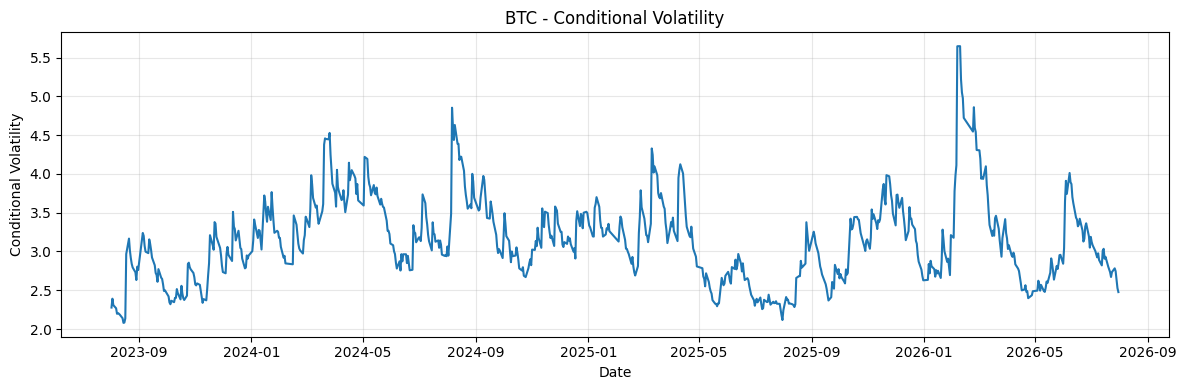

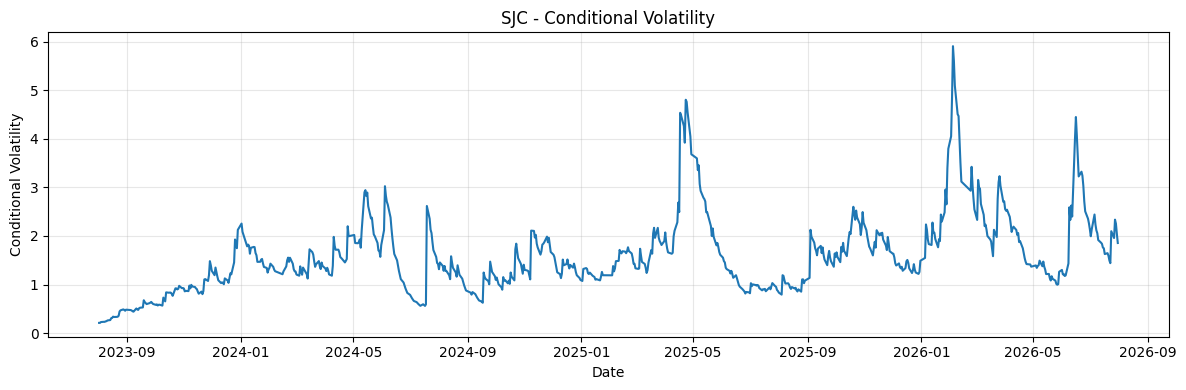

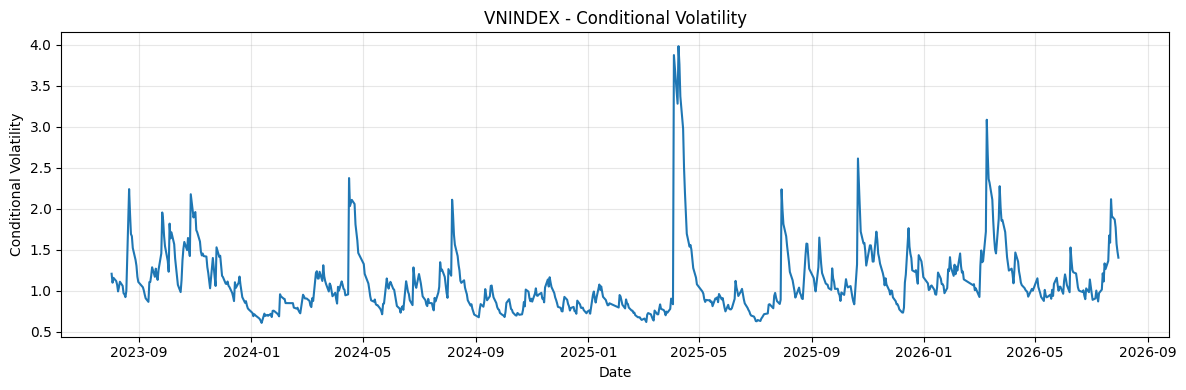

In [ ]:
# ============================================================
# MODEL 3 - PLOT CONDITIONAL VOLATILITY
# ============================================================

import matplotlib.pyplot as plt

for asset in ["BTC", "SJC", "VNINDEX"]:

    plt.figure(figsize=(12, 4))

    plt.plot(
        dy_volatility["Date"],
        dy_volatility[asset]
    )

    plt.title(f"{asset} - Conditional Volatility")
    plt.xlabel("Date")
    plt.ylabel("Conditional Volatility")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Chọn VAR specification

### Chọn lag cho VAR theo 4 tiêu chí thông tin

*   AIC: 3
*   FPE: 3
*   BIC: 1
*   HQIC: 1

In [ ]:
# ============================================================
# MODEL 3 - STEP 3
# VAR LAG ORDER SELECTION
# ============================================================

from statsmodels.tsa.api import VAR

# Endogenous variables
var_data = (
    dy_volatility[
        ["BTC", "SJC", "VNINDEX"]
    ]
    .dropna()
    .copy()
)

# ============================================================
# VAR lag-order selection
# ============================================================

var_model = VAR(var_data)

lag_selection = var_model.select_order(
    maxlags=20,
    trend="c"
)

print("=" * 80)
print("VAR LAG ORDER SELECTION - CONDITIONAL VOLATILITY")
print("=" * 80)

print(lag_selection.summary())

print("\nSelected lag by criterion:")
print("AIC  :", lag_selection.aic)
print("BIC  :", lag_selection.bic)
print("HQIC :", lag_selection.hqic)
print("FPE  :", lag_selection.fpe)

VAR LAG ORDER SELECTION - CONDITIONAL VOLATILITY
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.627      -3.608     0.02659      -3.620
1       -9.674     -9.599*   6.287e-05     -9.645*
2       -9.666      -9.533   6.343e-05      -9.614
3      -9.683*      -9.494  6.234e-05*      -9.610
4       -9.682      -9.435   6.243e-05      -9.587
5       -9.676      -9.373   6.280e-05      -9.559
6       -9.666      -9.306   6.340e-05      -9.527
7       -9.665      -9.249   6.346e-05      -9.504
8       -9.668      -9.195   6.325e-05      -9.486
9       -9.677      -9.147   6.270e-05      -9.473
10      -9.664      -9.077   6.354e-05      -9.437
11      -9.647      -9.003   6.463e-05      -9.399
12      -9.632      -8.932   6.559e-05      -9.362
13      -9.645      -8.887   6.479e-05      -9.352
14      -9.629      -8.815   6.583e-05      -9.315
15      -9.611      -8.740   6.69

#### So sánh VAR(3) và VAR(1)

Kết luận đều fail residual whiteness test. Không chọn được cả 2 lag này.

In [ ]:
# ============================================================
# MODEL 3 - STEP 4
# COMPARE VAR(1) AND VAR(3)
# Stability + Residual Whiteness
# ============================================================

from statsmodels.tsa.api import VAR
import pandas as pd

var_data = (
    dy_volatility[["BTC", "SJC", "VNINDEX"]]
    .dropna()
    .copy()
)

diagnostic_results = []

for p in [1, 3]:

    print("\n" + "=" * 90)
    print(f"VAR({p}) DIAGNOSTICS")
    print("=" * 90)

    # --------------------------------------------------------
    # Estimate VAR
    # --------------------------------------------------------
    result = VAR(var_data).fit(
        maxlags=p,
        trend="c"
    )

    print(result.summary())

    # --------------------------------------------------------
    # 1. Stability
    # --------------------------------------------------------
    stable = result.is_stable()

    print("\nStability:")
    print("Is VAR stable?:", stable)

    # --------------------------------------------------------
    # 2. Portmanteau residual whiteness test
    # H0: residuals have no serial correlation up to nlags
    # --------------------------------------------------------
    whiteness_10 = result.test_whiteness(
        nlags=10,
        adjusted=True
    )

    whiteness_15 = result.test_whiteness(
        nlags=15,
        adjusted=True
    )

    whiteness_20 = result.test_whiteness(
        nlags=20,
        adjusted=True
    )

    print("\nResidual Whiteness Test:")
    print(
        f"Lag 10: statistic={whiteness_10.test_statistic:.4f}, "
        f"p-value={whiteness_10.pvalue:.6f}"
    )

    print(
        f"Lag 15: statistic={whiteness_15.test_statistic:.4f}, "
        f"p-value={whiteness_15.pvalue:.6f}"
    )

    print(
        f"Lag 20: statistic={whiteness_20.test_statistic:.4f}, "
        f"p-value={whiteness_20.pvalue:.6f}"
    )

    diagnostic_results.append({
        "VAR": f"VAR({p})",
        "AIC": result.aic,
        "BIC": result.bic,
        "HQIC": result.hqic,
        "Stable": stable,
        "White_p10": whiteness_10.pvalue,
        "White_p15": whiteness_15.pvalue,
        "White_p20": whiteness_20.pvalue
    })


# ============================================================
# SUMMARY TABLE
# ============================================================

var_diagnostics = pd.DataFrame(diagnostic_results)

print("\n" + "=" * 100)
print("VAR(1) VS VAR(3) - DIAGNOSTIC SUMMARY")
print("=" * 100)

print(var_diagnostics.round(6))


VAR(1) DIAGNOSTICS
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 12, Aug, 2026
Time:                     08:19:07
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -9.58973
Nobs:                     746.000    HQIC:                  -9.63535
Log likelihood:           441.074    FPE:                6.35323e-05
AIC:                     -9.66396    Det(Omega_mle):     6.25212e-05
--------------------------------------------------------------------
Results for equation BTC
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.186281         0.040961            4.548           0.000
L1.BTC             0.937174         0.012834           73.022           0.000
L1.SJC             0.014400         0.008791          

### Scan nhiều VAR lag để tìm lag tối ưu

In [ ]:
# ============================================================
# MODEL 3 - VAR LAG DIAGNOSTIC SEARCH
# Find the smallest stable VAR with white residuals
# ============================================================

from statsmodels.tsa.api import VAR
import pandas as pd
import numpy as np

var_data = (
    dy_volatility[["BTC", "SJC", "VNINDEX"]]
    .dropna()
    .copy()
)

results = []

# Search VAR(1) -> VAR(15)
for p in range(1, 16):

    try:
        model = VAR(var_data).fit(
            maxlags=p,
            trend="c"
        )

        # ----------------------------------------------------
        # Stability
        # ----------------------------------------------------
        stable = model.is_stable()

        # ----------------------------------------------------
        # Whiteness test
        #
        # Use horizons larger than the fitted VAR lag.
        # ----------------------------------------------------
        horizons = [20, 25, 30]

        white_pvalues = {}

        for h in horizons:

            if h > p:

                test = model.test_whiteness(
                    nlags=h,
                    adjusted=True
                )

                white_pvalues[h] = test.pvalue

            else:
                white_pvalues[h] = np.nan


        # Require all available tests to pass 5%
        valid_pvalues = [
            x for x in white_pvalues.values()
            if not np.isnan(x)
        ]

        pass_white = all(
            pval > 0.05
            for pval in valid_pvalues
        )

        pass_all = stable and pass_white


        results.append({

            "Lag": p,

            "AIC": model.aic,
            "BIC": model.bic,
            "HQIC": model.hqic,

            "Stable": stable,

            "White_p20": white_pvalues[20],
            "White_p25": white_pvalues[25],
            "White_p30": white_pvalues[30],

            "Pass_White": pass_white,
            "Pass_All": pass_all
        })

    except Exception as e:

        print(f"VAR({p}) failed: {e}")


# ============================================================
# Result table
# ============================================================

var_lag_diagnostics = pd.DataFrame(results)

print("=" * 120)
print("VAR LAG DIAGNOSTIC SEARCH")
print("=" * 120)

print(
    var_lag_diagnostics
    .round(6)
    .to_string(index=False)
)


# ============================================================
# Passing models only
# ============================================================

passing_models = (
    var_lag_diagnostics[
        var_lag_diagnostics["Pass_All"]
    ]
    .copy()
)

print("\n" + "=" * 120)
print("MODELS PASSING BOTH STABILITY AND RESIDUAL WHITENESS")
print("=" * 120)

if len(passing_models) == 0:

    print("No VAR(1)-VAR(15) passes all diagnostic criteria.")

else:

    print(
        passing_models
        .round(6)
        .to_string(index=False)
    )

    print(
        "\nSmallest acceptable lag:",
        int(passing_models.iloc[0]["Lag"])
    )

VAR LAG DIAGNOSTIC SEARCH
 Lag       AIC       BIC      HQIC  Stable  White_p20  White_p25  White_p30  Pass_White  Pass_All
   1 -9.663963 -9.589731 -9.635353    True   0.000013   0.000344   0.000392       False     False
   2 -9.658803 -9.528762 -9.608680    True   0.000032   0.000694   0.000968       False     False
   3 -9.670161 -9.484192 -9.598476    True   0.001268   0.015495   0.022489       False     False
   4 -9.662639 -9.420624 -9.569344    True   0.002538   0.026383   0.035729       False     False
   5 -9.653236 -9.355057 -9.538284    True   0.002359   0.026483   0.041970       False     False
   6 -9.639770 -9.285308 -9.503111    True   0.002941   0.049120   0.083127       False     False
   7 -9.633061 -9.222197 -9.474647    True   0.004166   0.062443   0.096395       False     False
   8 -9.630652 -9.163267 -9.450434    True   0.019654   0.139046   0.227458       False     False
   9 -9.636566 -9.112540 -9.434495    True   0.074259   0.356635   0.434423        True     

#### Kết luận VAR specification

Nhóm VAR(1) - VAR(8) đều ổn định nhưng residuals vẫn còn tự tương quan; VAR(9) là lag nhỏ nhất mà cả ba Portmanteau whiteness tests đều vượt mức 5%:
$$
p_{20}=0.074259,\qquad
p_{25}=0.356635,\qquad
p_{30}=0.434423.
$$

Do đó chấp nhận H0:
$$
H_0:\text{phần dư không có tự tương quan đáng kể}.
$$

VAR(9) không phải có information criteria tối thiểu, nhưng hai specification VAR(1) và VAR(3) đều không đạt kiểm định residual whiteness (nghĩa là trong phần dư vẫn còn tự tương quan).

Vì mục tiêu tiếp theo là xây dựng FEVD, ta ưu tiên một VAR có dynamic specification đầy đủ hơn.

In [ ]:
# Chốt VAR(9) và lưu mô hình

from statsmodels.tsa.api import VAR
import numpy as np

var_data = (
    dy_volatility[
        ["BTC", "SJC", "VNINDEX"]
    ]
    .dropna()
    .copy()
)

# Estimate final VAR(9)
var_final = VAR(var_data).fit(
    maxlags=9,
    trend="c"
)

print("=" * 80)
print("FINAL VAR(9) MODEL")
print("=" * 80)

print(var_final.summary())


# ============================================================
# FINAL DIAGNOSTICS
# ============================================================

print("\n" + "=" * 80)
print("FINAL VAR(9) DIAGNOSTICS")
print("=" * 80)

print("\nStable:", var_final.is_stable())

for h in [20, 25, 30]:

    test = var_final.test_whiteness(
        nlags=h,
        adjusted=True
    )

    print(
        f"Whiteness lag {h}: "
        f"statistic={test.test_statistic:.4f}, "
        f"p-value={test.pvalue:.6f}"
    )


# ============================================================
# BASIC MODEL INFORMATION
# ============================================================

print("\nNumber of observations :", var_final.nobs)
print("Number of variables    :", var_final.neqs)
print("VAR lag order          :", var_final.k_ar)
print("AIC                    :", round(var_final.aic, 6))
print("BIC                    :", round(var_final.bic, 6))
print("HQIC                   :", round(var_final.hqic, 6))

FINAL VAR(9) MODEL
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 12, Aug, 2026
Time:                     08:38:15
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -9.11254
Nobs:                     738.000    HQIC:                  -9.43450
Log likelihood:           498.363    FPE:                6.53041e-05
AIC:                     -9.63657    Det(Omega_mle):     5.84014e-05
--------------------------------------------------------------------
Results for equation BTC
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.220975         0.048043            4.599           0.000
L1.BTC             1.011425         0.037587           26.909           0.000
L1.SJC            -0.009295         0.030570           

## Ước lượng VAR


In [ ]:
# ============================================================
# MODEL 3 - STEP 4
# FINAL VAR(9) ESTIMATION
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# ============================================================
# 1. Prepare data
# ============================================================

var_cols = ["BTC", "SJC", "VNINDEX"]

var_data = (
    dy_volatility[var_cols]
    .dropna()
    .copy()
)

# ============================================================
# 2. Estimate VAR(9)
# ============================================================

var_model_final = VAR(var_data)

var_final = var_model_final.fit(
    maxlags=9,
    trend="c"
)

print("=" * 90)
print("FINAL VAR(9) ESTIMATION - CONDITIONAL VOLATILITY")
print("=" * 90)

print(var_final.summary())


# ============================================================
# 3. Basic information
# ============================================================

print("\n" + "=" * 90)
print("MODEL INFORMATION")
print("=" * 90)

print("Number of variables :", var_final.neqs)
print("Lag order           :", var_final.k_ar)
print("Observations used   :", var_final.nobs)

print(f"AIC                  : {var_final.aic:.6f}")
print(f"BIC                  : {var_final.bic:.6f}")
print(f"HQIC                 : {var_final.hqic:.6f}")
print(f"FPE                  : {var_final.fpe:.8f}")

print("\nStable VAR           :", var_final.is_stable())

FINAL VAR(9) ESTIMATION - CONDITIONAL VOLATILITY
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 12, Aug, 2026
Time:                     08:42:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -9.11254
Nobs:                     738.000    HQIC:                  -9.43450
Log likelihood:           498.363    FPE:                6.53041e-05
AIC:                     -9.63657    Det(Omega_mle):     5.84014e-05
--------------------------------------------------------------------
Results for equation BTC
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.220975         0.048043            4.599           0.000
L1.BTC             1.011425         0.037587           26.909           0.000
L1.SJC            -0.0092

In [ ]:
# ============================================================
# EXTRACT VAR COEFFICIENT MATRICES
# A1, A2, ..., A9
# ============================================================

A = var_final.coefs

print("=" * 90)
print("VAR COEFFICIENT MATRICES")
print("=" * 90)

print("Shape of coefficient array:", A.shape)

for lag in range(var_final.k_ar):

    A_lag = pd.DataFrame(
        A[lag],
        index=var_cols,
        columns=var_cols
    )

    print(f"\nA_{lag + 1}")
    print("-" * 50)

    print(
        A_lag.round(6)
    )

VAR COEFFICIENT MATRICES
Shape of coefficient array: (9, 3, 3)

A_1
--------------------------------------------------
              BTC       SJC   VNINDEX
BTC      1.011425 -0.009295 -0.041555
SJC      0.023656  1.026298  0.023573
VNINDEX  0.115925 -0.002065  0.860127

A_2
--------------------------------------------------
              BTC       SJC   VNINDEX
BTC     -0.136338  0.050038  0.116558
SJC     -0.088267 -0.070952 -0.049659
VNINDEX -0.166076 -0.022370  0.109731

A_3
--------------------------------------------------
              BTC       SJC   VNINDEX
BTC      0.113242  0.046086 -0.052555
SJC      0.147623 -0.012847  0.058009
VNINDEX  0.080696  0.066787 -0.083631

A_4
--------------------------------------------------
              BTC       SJC   VNINDEX
BTC     -0.050876 -0.023808 -0.035771
SJC     -0.149629  0.069725  0.045746
VNINDEX  0.012042 -0.033705 -0.051256

A_5
--------------------------------------------------
              BTC       SJC   VNINDEX
BTC     -0.

In [ ]:
# ============================================================
# INTERCEPT VECTOR
# ============================================================

intercept = pd.Series(
    var_final.intercept,
    index=var_cols,
    name="Intercept"
)

print("=" * 60)
print("VAR INTERCEPT VECTOR")
print("=" * 60)

print(intercept.round(6))

VAR INTERCEPT VECTOR
BTC        0.220975
SJC       -0.054068
VNINDEX    0.123314
Name: Intercept, dtype: float64


In [ ]:
# ============================================================
# RESIDUAL COVARIANCE MATRIX
# Sigma_u
# ============================================================

Sigma_u = pd.DataFrame(
    np.asarray(var_final.sigma_u),
    index=var_cols,
    columns=var_cols
)

print("=" * 90)
print("VAR RESIDUAL COVARIANCE MATRIX - Sigma_u")
print("=" * 90)

print(Sigma_u.round(8))


# Check symmetry
print("\nSymmetric:")
print(
    np.allclose(
        Sigma_u.values,
        Sigma_u.values.T
    )
)


# Check eigenvalues
eigvals_sigma = np.linalg.eigvals(
    Sigma_u.values
)

print("\nEigenvalues of Sigma_u:")
print(eigvals_sigma)

print(
    "\nPositive definite:",
    np.all(eigvals_sigma > 0)
)

VAR RESIDUAL COVARIANCE MATRIX - Sigma_u
              BTC       SJC   VNINDEX
BTC      0.031583 -0.000464  0.002057
SJC     -0.000464  0.046281 -0.000160
VNINDEX  0.002057 -0.000160  0.040094

Symmetric:
True

Eigenvalues of Sigma_u:
[0.03110099 0.04055328 0.04630445]

Positive definite: True


In [ ]:
# ============================================================
# VAR RESIDUALS
# ============================================================

var_residuals = var_final.resid.copy()

var_residuals.columns = [
    "BTC_resid",
    "SJC_resid",
    "VNINDEX_resid"
]

print("=" * 80)
print("VAR RESIDUALS")
print("=" * 80)

print(var_residuals.head())

print("\nShape:")
print(var_residuals.shape)

print("\nResidual means:")
print(
    var_residuals.mean().round(8)
)

VAR RESIDUALS
    BTC_resid  SJC_resid  VNINDEX_resid
9   -0.119172   0.038081      -0.095749
10  -0.046735  -0.063377      -0.018011
11   0.008526  -0.016249      -0.043250
12   0.779822  -0.060390       0.049898
13   0.140172  -0.045772       1.144871

Shape:
(738, 3)

Residual means:
BTC_resid        0.0
SJC_resid       -0.0
VNINDEX_resid    0.0
dtype: float64


### Kết luận về ước lượng VAR

Mô hình VAR được ước lượng trên ba chuỗi biến động có điều kiện của BTC, SJC và VN-Index. VAR(9) là mô hình có độ trễ nhỏ nhất đồng thời thỏa mãn điều kiện ổn định và kiểm định phần dư.

Mô hình VAR(9) sử dụng $738$ quan sát hiệu dụng và cho kết quả ổn định (Stable = True). Kiểm định Portmanteau đối với phần dư tại các horizon $20$, $25$ và $30$ cho $p$-value lần lượt là $0.074259$, $0.356635$ và $0.434423$, đều lớn hơn mức ý nghĩa 5%, chấp nhận H0: phần dư không còn tự tương quan đáng kể.

Đồng thời, giá trị trung bình của phần dư trong cả ba phương trình đều xấp xỉ bằng $0$. Các kết quả này cho thấy VAR(9) mô tả tương đối đầy đủ cấu trúc động của ba chuỗi volatility và phù hợp để sử dụng làm mô hình nền cho bước phân rã phương sai tổng quát (Generalized FEVD) và tính toán các chỉ số lan truyền Diebold-Yılmaz.

## Chuyển VAR sang MA

Ma trận hiệp phương sai phần dư

$$\Sigma_u = \begin{bmatrix} 0.031583 & -0.000464 & 0.002057 \\ -0.000464 & 0.046281 & -0.000160 \\ 0.002057 & -0.000160 & 0.040094 \end{bmatrix}$$

In [ ]:
# ============================================================
# MODEL 3 - STEP 5
# MOVING-AVERAGE REPRESENTATION OF FINAL VAR(9)
# Main forecast horizon: H = 10
# ============================================================

import numpy as np
import pandas as pd

H = 10
var_cols = ["BTC", "SJC", "VNINDEX"]
K = len(var_cols)

# ------------------------------------------------------------
# MA coefficient matrices:
# Phi_0, Phi_1, ..., Phi_{H-1}
# ------------------------------------------------------------

Phi = var_final.ma_rep(maxn=H - 1)

print("=" * 90)
print(f"VAR(9) MOVING-AVERAGE REPRESENTATION - H = {H}")
print("=" * 90)

print("Shape of Phi:", Phi.shape)

# Sanity checks
print("\nPhi_0:")
print(
    pd.DataFrame(
        Phi[0],
        index=var_cols,
        columns=var_cols
    ).round(6)
)

print("\nPhi_0 = Identity matrix:",
      np.allclose(Phi[0], np.eye(K)))

print("\nAll finite:",
      np.isfinite(Phi).all())


# ------------------------------------------------------------
# Show Phi_1 and Phi_9 for inspection
# ------------------------------------------------------------

print("\nPhi_1:")
print(
    pd.DataFrame(
        Phi[1],
        index=var_cols,
        columns=var_cols
    ).round(6)
)

print(f"\nPhi_{H-1}:")
print(
    pd.DataFrame(
        Phi[H - 1],
        index=var_cols,
        columns=var_cols
    ).round(6)
)

VAR(9) MOVING-AVERAGE REPRESENTATION - H = 10
Shape of Phi: (10, 3, 3)

Phi_0:
         BTC  SJC  VNINDEX
BTC      1.0  0.0      0.0
SJC      0.0  1.0      0.0
VNINDEX  0.0  0.0      1.0

Phi_0 = Identity matrix: True

All finite: True

Phi_1:
              BTC       SJC   VNINDEX
BTC      1.011425 -0.009295 -0.041555
SJC      0.023656  1.026298  0.023573
VNINDEX  0.115925 -0.002065  0.860127

Phi_9:
              BTC       SJC   VNINDEX
BTC      0.581279  0.133042 -0.061705
SJC      0.187066  0.656821  0.406341
VNINDEX -0.009695 -0.062571  0.257239


## Tính Generalized FEVD (GFEVD)

Công thức ta sử dụng là:

$$
\theta_{ij}^{g}(H)
=
\frac{
\sigma_{jj}^{-1}
\displaystyle\sum_{h=0}^{H-1}
\left(
e_i'\Phi_h\Sigma e_j
\right)^2
}{
\displaystyle\sum_{h=0}^{H-1}
\left(
e_i'\Phi_h
\Sigma
\Phi_h'
e_i
\right)
}$$

Trong đó:

$i$ = biến nhận shock

$j$ = biến phát shock

In [ ]:
# ============================================================
# MODEL 3 - STEP 6
# GENERALIZED FORECAST ERROR VARIANCE DECOMPOSITION
# Pesaran-Shin / Diebold-Yilmaz framework
# ============================================================

import numpy as np
import pandas as pd


def generalized_fevd(var_result, H=10):

    # --------------------------------------------------------
    # Basic dimensions
    # --------------------------------------------------------
    K = var_result.neqs
    names = list(var_result.names)

    # Residual covariance matrix
    Sigma = np.asarray(var_result.sigma_u)

    # MA coefficients:
    # Phi_0, ..., Phi_{H-1}
    Phi = var_result.ma_rep(maxn=H - 1)

    assert Phi.shape[0] == H
    assert Phi.shape[1] == K
    assert Phi.shape[2] == K

    # --------------------------------------------------------
    # Raw generalized FEVD
    # --------------------------------------------------------
    theta = np.zeros((K, K))

    for i in range(K):

        # ----------------------------------------------------
        # Denominator:
        #
        # sum_h e_i' Phi_h Sigma Phi_h' e_i
        # ----------------------------------------------------
        denominator = 0.0

        for h in range(H):

            temp = (
                Phi[h]
                @ Sigma
                @ Phi[h].T
            )

            denominator += temp[i, i]


        # ----------------------------------------------------
        # Numerator for each shock j
        # ----------------------------------------------------
        for j in range(K):

            numerator = 0.0

            sigma_jj = Sigma[j, j]

            for h in range(H):

                # e_i' Phi_h Sigma e_j
                impact_ij = (
                    Phi[h]
                    @ Sigma
                )[i, j]

                numerator += impact_ij ** 2


            numerator *= (1.0 / sigma_jj)

            theta[i, j] = numerator / denominator


    # --------------------------------------------------------
    # Row normalization
    #
    # Generalized FEVD rows do NOT necessarily sum to 1
    # before normalization.
    # --------------------------------------------------------

    row_sums_raw = theta.sum(axis=1)

    theta_norm = (
        theta /
        row_sums_raw[:, None]
    )


    # Percentage form
    theta_pct = theta_norm * 100


    # --------------------------------------------------------
    # DataFrames
    # --------------------------------------------------------

    raw_df = pd.DataFrame(
        theta,
        index=names,
        columns=names
    )

    norm_df = pd.DataFrame(
        theta_norm,
        index=names,
        columns=names
    )

    pct_df = pd.DataFrame(
        theta_pct,
        index=names,
        columns=names
    )


    return raw_df, norm_df, pct_df, row_sums_raw

In [ ]:
# ============================================================
# COMPUTE GFEVD AT H = 10
# ============================================================

H = 10

gfevd_raw_10, gfevd_norm_10, gfevd_pct_10, raw_row_sums_10 = (
    generalized_fevd(
        var_final,
        H=H
    )
)

print("=" * 90)
print(f"RAW GENERALIZED FEVD - H = {H}")
print("=" * 90)

print(gfevd_raw_10.round(6))

print("\nRaw row sums:")
print(
    pd.Series(
        raw_row_sums_10,
        index=var_cols
    ).round(6)
)


print("\n" + "=" * 90)
print(f"NORMALIZED GENERALIZED FEVD (%) - H = {H}")
print("=" * 90)

print(gfevd_pct_10.round(4))


print("\nNormalized row sums (%):")
print(
    gfevd_pct_10
    .sum(axis=1)
    .round(6)
)

RAW GENERALIZED FEVD - H = 10
              BTC       SJC   VNINDEX
BTC      0.958232  0.035609  0.005876
SJC      0.012234  0.940021  0.047878
VNINDEX  0.019261  0.004421  0.987626

Raw row sums:
BTC        0.999717
SJC        1.000133
VNINDEX    1.011308
dtype: float64

NORMALIZED GENERALIZED FEVD (%) - H = 10
             BTC      SJC  VNINDEX
BTC      95.8504   3.5619   0.5877
SJC       1.2232  93.9896   4.7872
VNINDEX   1.9046   0.4371  97.6583

Normalized row sums (%):
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64


## Chuẩn hóa GFEVD Diebold-Yilmaz

In [ ]:
# ============================================================
# MODEL 3 - STEP 7
# DIEBOLD-YILMAZ SPILLOVER MEASURES
# FROM, TO, NET, TCI
# H = 10
# ============================================================

import numpy as np
import pandas as pd

# Normalized GFEVD in percentage form
theta = gfevd_pct_10.copy()

assets = list(theta.columns)
K = len(assets)

# ============================================================
# 1. OWN contributions
# ============================================================

OWN = pd.Series(
    np.diag(theta.values),
    index=assets,
    name="OWN"
)


# ============================================================
# 2. FROM others
#
# Row off-diagonal sum
# How much volatility asset i RECEIVES from other markets
# ============================================================

FROM = (
    theta.sum(axis=1)
    - np.diag(theta.values)
)

FROM.name = "FROM"


# ============================================================
# 3. TO others
#
# Column off-diagonal sum
# How much volatility asset j TRANSMITS to other markets
# ============================================================

TO = (
    theta.sum(axis=0)
    - np.diag(theta.values)
)

TO.name = "TO"


# ============================================================
# 4. NET directional spillover
#
# Positive = net transmitter
# Negative = net receiver
# ============================================================

NET = TO - FROM

NET.name = "NET"


# ============================================================
# 5. TOTAL CONNECTEDNESS INDEX (TCI)
# ============================================================

total_off_diagonal = (
    theta.values.sum()
    - np.trace(theta.values)
)

TCI = total_off_diagonal / K


# ============================================================
# 6. SUMMARY TABLE
# ============================================================

dy_summary_10 = pd.DataFrame({
    "OWN": OWN,
    "FROM": FROM,
    "TO": TO,
    "NET": NET
})

dy_summary_10["Role"] = np.where(
    dy_summary_10["NET"] > 0,
    "Net Transmitter",
    np.where(
        dy_summary_10["NET"] < 0,
        "Net Receiver",
        "Neutral"
    )
)


print("=" * 90)
print("DIEBOLD-YILMAZ DIRECTIONAL SPILLOVER - H = 10")
print("=" * 90)

print(
    dy_summary_10.round(4)
)

print("\n" + "=" * 90)
print("TOTAL CONNECTEDNESS INDEX")
print("=" * 90)

print(f"TCI = {TCI:.4f}%")

DIEBOLD-YILMAZ DIRECTIONAL SPILLOVER - H = 10
             OWN    FROM      TO     NET             Role
BTC      95.8504  4.1496  3.1278 -1.0218     Net Receiver
SJC      93.9896  6.0104  3.9990 -2.0114     Net Receiver
VNINDEX  97.6583  2.3417  5.3749  3.0332  Net Transmitter

TOTAL CONNECTEDNESS INDEX
TCI = 4.1672%


## Lập Spillover table

In [ ]:
# ============================================================
# FULL DIEBOLD-YILMAZ SPILLOVER TABLE
# Rows    = Received by
# Columns = Shock from
# ============================================================

spillover_table_10 = theta.copy()

spillover_table_10["FROM"] = FROM

# Add TO row
to_row = pd.Series(
    {
        **TO.to_dict(),
        "FROM": TCI
    },
    name="TO"
)

spillover_table_10 = pd.concat(
    [
        spillover_table_10,
        to_row.to_frame().T
    ]
)

print("=" * 100)
print("DIEBOLD-YILMAZ SPILLOVER TABLE (%) - H = 10")
print("Rows = Receiver | Columns = Transmitter")
print("=" * 100)

print(
    spillover_table_10.round(4)
)

print(
    f"\nTCI = {TCI:.4f}%"
)

DIEBOLD-YILMAZ SPILLOVER TABLE (%) - H = 10
Rows = Receiver | Columns = Transmitter
             BTC      SJC  VNINDEX    FROM
BTC      95.8504   3.5619   0.5877  4.1496
SJC       1.2232  93.9896   4.7872  6.0104
VNINDEX   1.9046   0.4371  97.6583  2.3417
TO        3.1278   3.9990   5.3749  4.1672

TCI = 4.1672%


### Kết luận về Spillover
Ở horizon $H=10$, phần lớn biến động dự báo vẫn được giải thích bởi own shocks: BTC $95.85%$, SJC $93.99%$, VN-Index $97.66%$. Vì vậy mức liên kết tổng thể hiện tại tương đối thấp:
$$
\boxed{TCI=4.1672\%}
$$

Tức khoảng $4.17%$ forecast-error variance của toàn hệ thống đến từ các shock truyền chéo giữa ba thị trường.
Về directional spillover:
$$
NET_{BTC}=-1.0218\%
$$
$$
NET_{SJC}=-2.0114\%
$$
$$
NET_{VNINDEX}=+3.0332\%
$$
nên:
VN-Index là net transmitter duy nhất.
BTC là net receiver.
SJC là net receiver mạnh nhất.
Đặc biệt, SJC có FROM = 6.0104%, lớn nhất trong ba tài sản, cho thấy volatility của SJC chịu ảnh hưởng từ các shock bên ngoài nhiều nhất.

## Net Pairwise Directional Connectedness - Hướng truyền

In [ ]:
# ============================================================
# MODEL 3 - STEP 8
# NET PAIRWISE DIRECTIONAL CONNECTEDNESS (NPDC)
# H = 10
#
# Rows/columns of theta:
# theta[i,j] = shock FROM j -> variance OF i
# ============================================================

import pandas as pd
import numpy as np

theta = gfevd_pct_10.copy()
assets = list(theta.columns)

# ============================================================
# 1. Full NPDC matrix
#
# NPDC[i,j] = i -> j minus j -> i
#
# Positive:
# i is net transmitter to j
#
# Negative:
# i is net receiver from j
# ============================================================

npdc = pd.DataFrame(
    np.zeros((len(assets), len(assets))),
    index=assets,
    columns=assets
)

for i in assets:
    for j in assets:

        if i != j:

            # i -> j = theta[j,i]
            # j -> i = theta[i,j]

            npdc.loc[i, j] = (
                theta.loc[j, i]
                - theta.loc[i, j]
            )


print("=" * 90)
print("NET PAIRWISE DIRECTIONAL CONNECTEDNESS (%) - H = 10")
print("Positive value: row asset is NET TRANSMITTER to column asset")
print("=" * 90)

print(npdc.round(4))

NET PAIRWISE DIRECTIONAL CONNECTEDNESS (%) - H = 10
Positive value: row asset is NET TRANSMITTER to column asset
            BTC     SJC  VNINDEX
BTC      0.0000 -2.3387   1.3168
SJC      2.3387  0.0000  -4.3501
VNINDEX -1.3168  4.3501   0.0000


In [ ]:
# Lập bảng dễ đọc
# PAIRWISE SPILLOVER SUMMARY
# ============================================================

pairs = [
    ("BTC", "SJC"),
    ("BTC", "VNINDEX"),
    ("SJC", "VNINDEX")
]

pairwise_results = []

for a, b in pairs:

    # Gross directional spillovers
    a_to_b = theta.loc[b, a]
    b_to_a = theta.loc[a, b]

    # Net flow from a to b
    net_a_to_b = a_to_b - b_to_a

    if net_a_to_b > 0:

        net_direction = f"{a} → {b}"
        net_value = net_a_to_b

    elif net_a_to_b < 0:

        net_direction = f"{b} → {a}"
        net_value = -net_a_to_b

    else:

        net_direction = "Neutral"
        net_value = 0.0


    pairwise_results.append({

        "Pair": f"{a} ↔ {b}",

        f"{a} → {b}": a_to_b,
        f"{b} → {a}": b_to_a,

        "Net Direction": net_direction,
        "Net Spillover": net_value
    })


pairwise_table_10 = pd.DataFrame(pairwise_results)

print("\n" + "=" * 110)
print("PAIRWISE DIRECTIONAL SPILLOVER SUMMARY - H = 10")
print("=" * 110)

print(
    pairwise_table_10
    .round(4)
    .to_string(index=False)
)


PAIRWISE DIRECTIONAL SPILLOVER SUMMARY - H = 10
         Pair  BTC → SJC  SJC → BTC Net Direction  Net Spillover  BTC → VNINDEX  VNINDEX → BTC  SJC → VNINDEX  VNINDEX → SJC
    BTC ↔ SJC     1.2232     3.5619     SJC → BTC         2.3387            NaN            NaN            NaN            NaN
BTC ↔ VNINDEX        NaN        NaN BTC → VNINDEX         1.3168         1.9046         0.5877            NaN            NaN
SJC ↔ VNINDEX        NaN        NaN VNINDEX → SJC         4.3501            NaN            NaN         0.4371         4.7872


### Kết luận về kết quả lan truyền Diebold-Yılmaz

Kết quả phân rã phương sai tổng quát tại horizon $H=10$ cho thấy biến động của cả ba thị trường chủ yếu vẫn được quyết định bởi các cú sốc nội tại. Tỷ trọng forecast-error variance được giải thích bởi own shocks lần lượt đạt $95.8504\%$ đối với BTC, $93.9896\%$ đối với SJC và $97.6583\%$ đối với VN-Index. Điều này cho thấy mức độ phụ thuộc vào các cú sốc từ thị trường khác nhìn chung còn tương đối hạn chế.

Chỉ số kết nối tổng thể Diebold-Yılmaz đạt:

$$
TCI=4.1672\%.
$$

Như vậy, khoảng $4.17\%$ tổng phương sai sai số dự báo của hệ thống được giải thích bởi các cú sốc lan truyền chéo giữa BTC, SJC và VN-Index, trong khi phần còn lại chủ yếu đến từ các cú sốc riêng của từng thị trường. Kết quả này phản ánh mức độ connectedness tổng thể tương đối thấp tại horizon $H=10$.

Xét mức độ tiếp nhận rủi ro từ các thị trường khác, SJC có chỉ số $FROM$ lớn nhất:

$$
FROM_{\text{SJC}}=6.0104\%,
$$

tiếp theo là BTC với:

$$
FROM_{\text{BTC}}=4.1496\%,
$$

và VN-Index có mức tiếp nhận thấp nhất:

$$
FROM_{\text{VNIndex}}=2.3417\%.
$$

Do đó, trong ba thị trường, SJC là thị trường chịu ảnh hưởng tương đối mạnh nhất từ các cú sốc volatility bên ngoài.

Ở chiều truyền dẫn, VN-Index có chỉ số $TO$ cao nhất:

$$
TO_{\text{VNIndex}}=5.3749\%,
$$

so với $3.9990\%$ của SJC và $3.1278\%$ của BTC. Điều này cho thấy VN-Index là thị trường có mức độ truyền cú sốc volatility sang các thị trường còn lại lớn nhất trong hệ thống.

Kết quả $NET=TO-FROM$ tiếp tục làm rõ vai trò của từng tài sản:

$$
NET_{\text{BTC}}=-1.0218\%,
$$

$$
NET_{\text{SJC}}=-2.0114\%,
$$

$$
NET_{\text{VNIndex}}=3.0332\%.
$$

Theo đó, VN-Index có $NET>0$ và được xác định là **net transmitter** của volatility spillover, trong khi BTC và SJC có $NET<0$ nên đóng vai trò **net receiver**. Trong hai thị trường nhận rủi ro ròng, SJC có giá trị $NET$ âm lớn nhất về trị tuyệt đối, cho thấy đây là thị trường tiếp nhận rủi ro ròng mạnh nhất trong hệ thống.

Nhìn chung, kết quả tại $H=10$ cho thấy cấu trúc lan truyền biến động giữa ba thị trường tồn tại nhưng chưa mạnh ở cấp độ toàn hệ thống. VN-Index đóng vai trò nguồn phát tán rủi ro ròng, trong khi SJC và BTC chủ yếu là các thị trường tiếp nhận.

### Network ròng của Model 3 hiện tại
Kết quả tạo thành một vòng:
$$
\boxed{
VNINDEX
\xrightarrow{4.3501}
SJC
\xrightarrow{2.3387}
BTC
\xrightarrow{1.3169}
VNINDEX
}
$$

Nhưng cường độ không cân bằng. Dòng mạnh nhất là:
$$
VNINDEX\rightarrow SJC.
$$
Vì VN-Index nhận tương đối ít shock từ hai thị trường khác nhưng truyền mạnh sang SJC nên tổng hợp lại:
$$
NET_{VNINDEX}=+3.0332\%.
$$

Ta cũng có một sanity check rất đẹp:
$$
-2.3387+1.3169=-1.0218
$$ chính là:
$$
NET_{BTC}.
$$
Tương tự:
$$
2.3387-4.3501=-2.0114=NET_{SJC}
$$ và:
$$
-1.3169+4.3501=3.0332=NET_{VNINDEX}.
$$
Như vậy pairwise NPDC và directional NET khớp chính xác, xác nhận orientation TO/FROM của code không bị đảo.

## Robustness: tính vững của mô hình theo forecast H5, H10, H20

### Tính GFEVD và DY measures cho H5, H10, H20

In [ ]:
# ============================================================
# MODEL 3 - STEP 9
# ROBUSTNESS ACROSS FORECAST HORIZONS
# H = 5, 10, 20
# ============================================================

import numpy as np
import pandas as pd

horizons = [5, 10, 20]
assets = ["BTC", "SJC", "VNINDEX"]
K = len(assets)

robustness_results = {}
summary_rows = []


for H in horizons:

    # ========================================================
    # 1. Generalized FEVD
    # ========================================================

    raw_df, norm_df, pct_df, raw_row_sums = generalized_fevd(
        var_final,
        H=H
    )

    theta = pct_df.copy()


    # ========================================================
    # 2. OWN
    # ========================================================

    OWN = pd.Series(
        np.diag(theta.values),
        index=assets
    )


    # ========================================================
    # 3. FROM others
    # Row off-diagonal sum
    # ========================================================

    FROM = (
        theta.sum(axis=1)
        - np.diag(theta.values)
    )


    # ========================================================
    # 4. TO others
    # Column off-diagonal sum
    # ========================================================

    TO = (
        theta.sum(axis=0)
        - np.diag(theta.values)
    )


    # ========================================================
    # 5. NET
    # ========================================================

    NET = TO - FROM


    # ========================================================
    # 6. TCI
    # ========================================================

    total_off_diagonal = (
        theta.values.sum()
        - np.trace(theta.values)
    )

    TCI = total_off_diagonal / K


    # ========================================================
    # 7. Summary table for this horizon
    # ========================================================

    summary = pd.DataFrame({
        "OWN": OWN,
        "FROM": FROM,
        "TO": TO,
        "NET": NET
    })

    summary["Role"] = np.where(
        summary["NET"] > 0,
        "Net Transmitter",
        np.where(
            summary["NET"] < 0,
            "Net Receiver",
            "Neutral"
        )
    )


    # ========================================================
    # 8. Store results
    # ========================================================

    robustness_results[H] = {
        "raw_gfevd": raw_df,
        "normalized_gfevd": norm_df,
        "gfevd_pct": pct_df,
        "raw_row_sums": raw_row_sums,
        "summary": summary,
        "TCI": TCI
    }


    # ========================================================
    # 9. Combined summary
    # ========================================================

    for asset in assets:

        summary_rows.append({
            "H": H,
            "Asset": asset,
            "OWN": OWN[asset],
            "FROM": FROM[asset],
            "TO": TO[asset],
            "NET": NET[asset],
            "Role": summary.loc[asset, "Role"],
            "TCI": TCI
        })


robustness_summary = pd.DataFrame(summary_rows)


print("=" * 110)
print("DIEBOLD-YILMAZ ROBUSTNESS - H = 5, 10, 20")
print("=" * 110)

print(
    robustness_summary
    .round(4)
    .to_string(index=False)
)

DIEBOLD-YILMAZ ROBUSTNESS - H = 5, 10, 20
 H   Asset     OWN    FROM      TO     NET            Role    TCI
 5     BTC 97.8006  2.1994  1.8946 -0.3048    Net Receiver 1.4520
 5     SJC 99.7628  0.2372  1.5118  1.2746 Net Transmitter 1.4520
 5 VNINDEX 98.0804  1.9196  0.9497 -0.9698    Net Receiver 1.4520
10     BTC 95.8504  4.1496  3.1278 -1.0218    Net Receiver 4.1672
10     SJC 93.9896  6.0104  3.9990 -2.0114    Net Receiver 4.1672
10 VNINDEX 97.6583  2.3417  5.3749  3.0332 Net Transmitter 4.1672
20     BTC 94.5317  5.4683  5.4153 -0.0530    Net Receiver 7.6270
20     SJC 85.1332 14.8668  5.1823 -9.6845    Net Receiver 7.6270
20 VNINDEX 97.4542  2.5458 12.2834  9.7376 Net Transmitter 7.6270


### Tăng cấu trúc spillover

In [ ]:
# ============================================================
# NORMALIZED GFEVD TABLES
# H = 5, 10, 20
# ============================================================

for H in horizons:

    print("\n" + "=" * 90)
    print(f"NORMALIZED GENERALIZED FEVD (%) - H = {H}")
    print("=" * 90)

    theta = robustness_results[H]["gfevd_pct"]

    print(theta.round(4))

    print("\nRow sums:")
    print(
        theta.sum(axis=1).round(6)
    )


NORMALIZED GENERALIZED FEVD (%) - H = 5
             BTC      SJC  VNINDEX
BTC      97.8006   1.4292   0.7702
SJC       0.0577  99.7628   0.1795
VNINDEX   1.8369   0.0826  98.0804

Row sums:
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64

NORMALIZED GENERALIZED FEVD (%) - H = 10
             BTC      SJC  VNINDEX
BTC      95.8504   3.5619   0.5877
SJC       1.2232  93.9896   4.7872
VNINDEX   1.9046   0.4371  97.6583

Row sums:
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64

NORMALIZED GENERALIZED FEVD (%) - H = 20
             BTC      SJC  VNINDEX
BTC      94.5317   4.4551   1.0132
SJC       3.5967  85.1332  11.2701
VNINDEX   1.8186   0.7272  97.4542

Row sums:
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64


### Bảng robustness

In [ ]:
# ============================================================
# COMPACT ROBUSTNESS TABLE
# FROM / TO / NET BY FORECAST HORIZON
# ============================================================

robustness_compact = (
    robustness_summary[
        ["H", "Asset", "FROM", "TO", "NET", "Role"]
    ]
    .copy()
)

print("=" * 100)
print("ROBUSTNESS OF DIRECTIONAL SPILLOVER")
print("=" * 100)

print(
    robustness_compact
    .round(4)
    .to_string(index=False)
)

ROBUSTNESS OF DIRECTIONAL SPILLOVER
 H   Asset    FROM      TO     NET            Role
 5     BTC  2.1994  1.8946 -0.3048    Net Receiver
 5     SJC  0.2372  1.5118  1.2746 Net Transmitter
 5 VNINDEX  1.9196  0.9497 -0.9698    Net Receiver
10     BTC  4.1496  3.1278 -1.0218    Net Receiver
10     SJC  6.0104  3.9990 -2.0114    Net Receiver
10 VNINDEX  2.3417  5.3749  3.0332 Net Transmitter
20     BTC  5.4683  5.4153 -0.0530    Net Receiver
20     SJC 14.8668  5.1823 -9.6845    Net Receiver
20 VNINDEX  2.5458 12.2834  9.7376 Net Transmitter


### So sánh TCI theo Horizon

Kết quả TCI tăng khi Horizon tăng.

Kết luận khi xét khoảng dự báo dài hơn, các shocks có thêm thời gian truyền qua hệ thống VAR, làm tỷ trọng cross-market forecast-error variance gia tăng.

In [ ]:
# ============================================================
# TCI ROBUSTNESS
# ============================================================

tci_robustness = pd.DataFrame({
    "H": horizons,
    "TCI": [
        robustness_results[H]["TCI"]
        for H in horizons
    ]
})

print("=" * 60)
print("TOTAL CONNECTEDNESS INDEX BY HORIZON")
print("=" * 60)

print(
    tci_robustness
    .round(4)
    .to_string(index=False)
)

TOTAL CONNECTEDNESS INDEX BY HORIZON
 H    TCI
 5 1.4520
10 4.1672
20 7.6270


### Pairwise robustness tại H5, 10, 20


In [ ]:
# ============================================================
# NET PAIRWISE DIRECTIONAL CONNECTEDNESS
# ROBUSTNESS H = 5, 10, 20
# ============================================================

pairs = [
    ("BTC", "SJC"),
    ("BTC", "VNINDEX"),
    ("SJC", "VNINDEX")
]

pairwise_rows = []


for H in horizons:

    theta = robustness_results[H]["gfevd_pct"]

    for a, b in pairs:

        # Gross directional spillovers
        # a -> b = theta[b, a]
        # b -> a = theta[a, b]

        a_to_b = theta.loc[b, a]
        b_to_a = theta.loc[a, b]

        net_a_to_b = a_to_b - b_to_a


        if net_a_to_b > 0:

            net_direction = f"{a} → {b}"
            net_spillover = net_a_to_b

        elif net_a_to_b < 0:

            net_direction = f"{b} → {a}"
            net_spillover = -net_a_to_b

        else:

            net_direction = "Neutral"
            net_spillover = 0.0


        pairwise_rows.append({

            "H": H,
            "Pair": f"{a} ↔ {b}",

            "A_to_B": a_to_b,
            "B_to_A": b_to_a,

            "Net Direction": net_direction,
            "Net Spillover": net_spillover
        })


pairwise_robustness = pd.DataFrame(pairwise_rows)


print("=" * 110)
print("PAIRWISE SPILLOVER ROBUSTNESS - H = 5, 10, 20")
print("=" * 110)

print(
    pairwise_robustness
    .round(4)
    .to_string(index=False)
)

PAIRWISE SPILLOVER ROBUSTNESS - H = 5, 10, 20
 H          Pair  A_to_B  B_to_A Net Direction  Net Spillover
 5     BTC ↔ SJC  0.0577  1.4292     SJC → BTC         1.3715
 5 BTC ↔ VNINDEX  1.8369  0.7702 BTC → VNINDEX         1.0667
 5 SJC ↔ VNINDEX  0.0826  0.1795 VNINDEX → SJC         0.0969
10     BTC ↔ SJC  1.2232  3.5619     SJC → BTC         2.3387
10 BTC ↔ VNINDEX  1.9046  0.5877 BTC → VNINDEX         1.3168
10 SJC ↔ VNINDEX  0.4371  4.7872 VNINDEX → SJC         4.3501
20     BTC ↔ SJC  3.5967  4.4551     SJC → BTC         0.8584
20 BTC ↔ VNINDEX  1.8186  1.0132 BTC → VNINDEX         0.8053
20 SJC ↔ VNINDEX  0.7272 11.2701 VNINDEX → SJC        10.5429


### Sanity check


In [ ]:
# ============================================================
# ROBUSTNESS SANITY CHECKS
# ============================================================

print("=" * 90)
print("ROBUSTNESS SANITY CHECKS")
print("=" * 90)


for H in horizons:

    theta = robustness_results[H]["gfevd_pct"]
    summary = robustness_results[H]["summary"]

    print(f"\nH = {H}")

    # ----------------------------------------
    # GFEVD rows should sum to 100
    # ----------------------------------------

    row_sum_ok = np.allclose(
        theta.sum(axis=1).values,
        100.0,
        atol=1e-8
    )

    print(
        "GFEVD rows sum to 100:",
        row_sum_ok
    )


    # ----------------------------------------
    # Sum NET must equal zero
    # ----------------------------------------

    net_sum = summary["NET"].sum()

    print(
        f"Sum NET = {net_sum:.10f}"
    )

    print(
        "Sum NET approximately zero:",
        np.isclose(
            net_sum,
            0.0,
            atol=1e-8
        )
    )


    # ----------------------------------------
    # Total TO = Total FROM
    # ----------------------------------------

    total_to = summary["TO"].sum()
    total_from = summary["FROM"].sum()

    print(
        f"Total TO   = {total_to:.6f}"
    )

    print(
        f"Total FROM = {total_from:.6f}"
    )

    print(
        "TO = FROM:",
        np.isclose(
            total_to,
            total_from,
            atol=1e-8
        )
    )

ROBUSTNESS SANITY CHECKS

H = 5
GFEVD rows sum to 100: True
Sum NET = 0.0000000000
Sum NET approximately zero: True
Total TO   = 4.356123
Total FROM = 4.356123
TO = FROM: True

H = 10
GFEVD rows sum to 100: True
Sum NET = 0.0000000000
Sum NET approximately zero: True
Total TO   = 12.501744
Total FROM = 12.501744
TO = FROM: True

H = 20
GFEVD rows sum to 100: True
Sum NET = 0.0000000000
Sum NET approximately zero: True
Total TO   = 22.880925
Total FROM = 22.880925
TO = FROM: True


### Kết luận về tính vững

Kết quả kiểm định độ bền với ba forecast horizon $H=5$, $H=10$ và $H=20$ cho thấy mức độ liên kết giữa BTC, SJC và VN-Index tăng rõ rệt khi horizon kéo dài. Chỉ số Total Connectedness Index lần lượt đạt:

$$
TCI(5)=1.4520\%,
$$

$$
TCI(10)=4.1672\%,
$$

$$
TCI(20)=7.6270\%.
$$

Như vậy, tỷ trọng phương sai sai số dự báo được giải thích bởi các cú sốc lan truyền chéo giữa ba thị trường tăng dần theo horizon. Ở horizon ngắn, biến động của từng tài sản chủ yếu vẫn được quyết định bởi các cú sốc nội tại. Khi horizon tăng, các cú sốc có thêm thời gian truyền qua cấu trúc động của hệ VAR, làm mức độ connectedness của toàn hệ thống gia tăng. Tuy nhiên, ngay cả tại $H=20$, giá trị $TCI$ vẫn chỉ ở mức $7.6270\%$, cho thấy own-market shocks vẫn là nguồn giải thích chủ yếu của volatility.

Vai trò truyền và nhận rủi ro ròng có sự thay đổi đáng chú ý giữa horizon ngắn hạn và trung-dài hạn. Tại $H=5$, SJC là tài sản duy nhất có $NET>0$:

$$
NET_{\text{SJC}}=1.2746\%,
$$

trong khi BTC và VN-Index lần lượt có:

$$
NET_{\text{BTC}}=-0.3048\%,
$$

$$
NET_{\text{VNIndex}}=-0.9698\%.
$$

Do đó, trong ngắn hạn, SJC đóng vai trò **net transmitter**, còn BTC và VN-Index là **net receivers**.

Tuy nhiên, cấu trúc này thay đổi khi horizon tăng lên. Tại $H=10$, VN-Index chuyển sang vai trò net transmitter với:

$$
NET_{\text{VNIndex}}=3.0332\%,
$$

trong khi BTC và SJC trở thành net receivers. Xu hướng này tiếp tục được khuếch đại tại $H=20$:

$$
NET_{\text{VNIndex}}=9.7376\%,
$$

$$
NET_{\text{SJC}}=-9.6845\%,
$$

$$
NET_{\text{BTC}}=-0.0530\%.
$$

Kết quả tại $H=20$ đặc biệt cho thấy VN-Index trở thành nguồn phát tán volatility ròng rất rõ, trong khi SJC trở thành thị trường tiếp nhận rủi ro ròng mạnh nhất. Ngược lại, giá trị $NET$ của BTC gần bằng $0$, cho thấy tổng lượng volatility mà BTC truyền sang các thị trường khác gần tương đương với lượng volatility mà BTC tiếp nhận. Vì vậy, ở horizon dài hơn, BTC có xu hướng tiến gần trạng thái cân bằng về net connectedness.

Mặc dù vai trò $NET$ tổng thể thay đổi theo horizon, **hướng lan truyền ròng giữa từng cặp tài sản lại duy trì hoàn toàn ổn định** trong cả ba trường hợp $H=5$, $H=10$ và $H=20$. Cụ thể, các hướng lan truyền ròng luôn được xác định là:

$$
SJC\rightarrow BTC,
$$

$$
BTC\rightarrow VNINDEX,
$$

và

$$
VNINDEX\rightarrow SJC.
$$

Đối với cặp SJC--BTC, spillover ròng theo hướng $SJC\rightarrow BTC$ lần lượt đạt $1.3715\%$, $2.3387\%$ và $0.8584\%$ tại $H=5$, $H=10$ và $H=20$. Đối với cặp BTC--VN-Index, hướng $BTC\rightarrow VNINDEX$ cũng được duy trì với mức spillover ròng tương ứng là $1.0667\%$, $1.3168\%$ và $0.8053\%$.

Đáng chú ý nhất là quan hệ giữa VN-Index và SJC. Spillover ròng theo hướng:

$$
VNINDEX\rightarrow SJC
$$

tăng mạnh từ $0.0969\%$ tại $H=5$ lên $4.3501\%$ tại $H=10$ và đạt $10.5429\%$ tại $H=20$. Điều này cho thấy tác động của các cú sốc volatility từ VN-Index lên SJC không thể hiện mạnh ngay trong ngắn hạn, nhưng được tích lũy đáng kể khi horizon kéo dài. Đây cũng là nguyên nhân chủ yếu khiến VN-Index chuyển từ net receiver tại $H=5$ sang net transmitter tại $H=10$ và đặc biệt trở thành nguồn phát tán rủi ro ròng mạnh tại $H=20$.

Tổng hợp các mối quan hệ pairwise cho thấy một **cấu trúc lan truyền dạng vòng** được duy trì ổn định ở cả ba forecast horizon:

$$
VNINDEX
\rightarrow
SJC
\rightarrow
BTC
\rightarrow
VNINDEX.
$$

Như vậy, topology của mạng lưới lan truyền không thay đổi khi horizon thay đổi, nhưng cường độ của từng liên kết thay đổi đáng kể. Trong ngắn hạn, chiều $SJC\rightarrow BTC$ tương đối nổi bật, trong khi ở các horizon dài hơn, đặc biệt tại $H=20$, chiều $VNINDEX\rightarrow SJC$ trở thành kênh truyền dẫn chi phối.

Nhìn chung, kiểm định độ bền cho thấy kết quả của mô hình không hoàn toàn bất biến theo forecast horizon về mặt vai trò $NET$, mà thể hiện rõ tính **horizon-dependent**. SJC đóng vai trò nguồn phát rủi ro ròng trong ngắn hạn, trong khi VN-Index trở thành nguồn phát rủi ro chủ đạo ở trung và dài hạn. Tuy nhiên, hướng lan truyền giữa từng cặp tài sản vẫn giữ nguyên ở cả $H=5$, $H=10$ và $H=20$. Vì vậy, kết quả tại $H=10$ có thể được sử dụng làm specification chính, trong khi $H=5$ và $H=20$ cung cấp bằng chứng bổ sung rằng cấu trúc hướng lan truyền giữa ba thị trường là tương đối bền vững, dù cường độ và vai trò net transmitter/net receiver thay đổi theo horizon.